# Stock Market Analysis

This notebook implementas a list of all freely available models to analysis live stock data and to predict to the price of a particular stock.

## This notebook consist of the following Models

* ### Traditional Analysis
 1. Fundamental Analysis
 2. Technical Analysis

* ### Machine Learning Models
 1. Linear Regression
 2. Logistic Regression
 3. Random Forest
 4. Support Vector Machine (SVM)
 5. XGBoost
 6. LightGBM

* ### Deep Learning Models
 1. Artificial Neural Networks (ANN)
 2. Recurrent Neural Networks (RNN)
 3. Long Short-Term Memory (LSTM)
 4. Gated Recurrent Units (GRU)
 5. Transformer Models

* ### Time Series Forecasting
 1. Autoregressive Conditional Heteroskedasticity(ARCH)
 2. Generalized Autoregressive Conditional Heteroskedasticity(GARCH)
 3. Autoregressive Integrated Moving Average(ARIMA)
 4. Seasonal Autoregressive Integrated Moving Average(SARIMA)
 5. Prophet model
 6. Kalman Filter

* ### Reinforcement Learning Models
 1. Deep Q-Network (DQN)
 2. Proximal Policy Optimization (PPO)
 3. A2C (Advantage Actor-Critic)
 4. Stacking (Ensemble of ML models)
 5. CNN + LSTM model

## More Models will be added in the future.

# Installing Dependencies

In [1]:
!pip install yfinance pandas numpy matplotlib seaborn statsmodels arch scikit-learn imbalanced-learn tensorflow torch alpha-vantage pykalman gym xgboost lightgbm prophet --quiet

# Importing Libraries

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical and time series models
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from arch import arch_model

# Machine Learning models and utilities
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, StackingRegressor
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

# Deep Learning frameworks
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, LSTM, GRU, Dropout, Conv1D, MaxPooling1D, Flatten, Input
from tensorflow.keras.optimizers import Adam

# PyTorch and reinforcement learning
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.distributions import Categorical
from collections import deque

# Additional libraries
from alpha_vantage.fundamentaldata import FundamentalData
import time
from pykalman import KalmanFilter
import gym
import xgboost as xgb
import lightgbm as lgb
from prophet import Prophet
import random
import re

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=

# Receive Stock Ticker from User and gather live stock data using online API

In [3]:
def get_valid_ticker():
    """Prompts user for a valid stock ticker and verifies it using Yahoo Finance."""
    while True:
        stock = input("Enter a valid stock ticker (e.g., AAPL, TSLA, MSFT): ").upper()
        try:
            test = yf.Ticker(stock)
            if test.history(period="1d").empty:
                print("Invalid ticker. Please try again.")
            else:
                return stock
        except Exception as e:
            print(f"Error validating ticker: {e}")
            print("Invalid input. Please try again.")

# Get a valid stock ticker from the user
stock_ticker = get_valid_ticker()

# Fetch stock data using Yahoo Finance
ticker = yf.Ticker(stock_ticker)
history = ticker.history(period="10y")

# Display basic stock info
try:
    info = ticker.info
    print(f"\nStock Name: {info.get('longName', 'N/A')}")
    print(f"Sector: {info.get('sector', 'N/A')}")
    print(f"Market Cap: {info.get('marketCap', 'N/A')}")
except Exception as e:
    print(f"Error retrieving stock info: {e}")

Enter a valid stock ticker (e.g., AAPL, TSLA, MSFT): msft

Stock Name: Microsoft Corporation
Sector: Technology
Market Cap: 2918992052224


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# Fundamental Analysis

In [4]:
# Fundamental Analysis

print(f"\n{'='*60}")
print(f"  FUNDAMENTAL ANALYSIS - {stock_ticker}")
print(f"{'='*60}\n")

fundamentals = {}
fundamental_fields = {
    'marketCap':                    "Market Cap",
    'trailingPE':                   "P/E Ratio",
    'forwardPE':                    "Forward P/E Ratio",
    'priceToBook':                  "P/B Ratio",
    'priceToSalesTrailing12Months': "P/S Ratio",
    'dividendYield':                "Dividend Yield",
    'trailingEps':                  "Trailing EPS",
    'forwardEps':                   "Forward EPS",
    'beta':                         "Beta",
    'trailingPegRatio':             "PEG Ratio",
    'debtToEquity':                 "Debt-to-Equity",
    'returnOnEquity':               "Return on Equity",
    'returnOnAssets':               "Return on Assets",
    'currentRatio':                 "Current Ratio",
    'quickRatio':                   "Quick Ratio",
    'grossMargins':                 "Gross Margin",
    'operatingMargins':             "Operating Margin",
    'profitMargins':                "Net Profit Margin",
    'revenueGrowth':                "Revenue Growth (YoY)",
    'earningsGrowth':               "Earnings Growth (YoY)",
    'freeCashflow':                 "Free Cash Flow",
    'trailingAnnualDividendYield':  "Trailing Dividend Yield",
    'trailingAnnualDividendRate':   "Trailing Dividend Rate",
}

for field, label in fundamental_fields.items():
    if field in info and info[field] is not None:
        fundamentals[label] = info[field]

for key, value in fundamentals.items():
    if isinstance(value, float) and abs(value) < 1000:
        print(f"  {key:<35}: {value:.4f}")
    else:
        print(f"  {key:<35}: {value}")

# Scoring Engine
# Each signal returns: +1 (bullish), 0 (neutral), -1 or -2 (bearish)
# Weight represents the importance of that metric

signals = []  # stores (label, score, weight, comment)

def add_signal(label, score, weight, comment):
    signals.append((label, score, weight, comment))

# Valuation
pe  = fundamentals.get("P/E Ratio")
fpe = fundamentals.get("Forward P/E Ratio")
pb  = fundamentals.get("P/B Ratio")
ps  = fundamentals.get("P/S Ratio")
peg = fundamentals.get("PEG Ratio")

if pe is not None:
    if pe < 10:       add_signal("P/E Ratio",           +1, 2, f"Very undervalued  (P/E = {pe:.1f})")
    elif pe < 20:     add_signal("P/E Ratio",           +1, 2, f"Reasonably valued (P/E = {pe:.1f})")
    elif pe < 30:     add_signal("P/E Ratio",            0, 2, f"Fairly valued     (P/E = {pe:.1f})")
    elif pe < 50:     add_signal("P/E Ratio",           -1, 2, f"Overvalued        (P/E = {pe:.1f})")
    else:             add_signal("P/E Ratio",           -2, 2, f"Significantly overvalued (P/E = {pe:.1f})")

if fpe is not None and pe is not None:
    if fpe < pe:      add_signal("Forward P/E vs P/E",  +1, 1, "Earnings expected to grow   (Forward P/E < Trailing P/E)")
    else:             add_signal("Forward P/E vs P/E",  -1, 1, "Earnings expected to shrink (Forward P/E > Trailing P/E)")

if pb is not None:
    if pb < 1:        add_signal("P/B Ratio",           +1, 2, f"Trading below book value (P/B = {pb:.2f})")
    elif pb < 3:      add_signal("P/B Ratio",            0, 2, f"Book value in range      (P/B = {pb:.2f})")
    else:             add_signal("P/B Ratio",           -1, 2, f"Premium to book          (P/B = {pb:.2f})")

if ps is not None:
    if ps < 2:        add_signal("P/S Ratio",           +1, 1, f"Low price-to-sales  (P/S = {ps:.2f})")
    elif ps < 5:      add_signal("P/S Ratio",            0, 1, f"Moderate P/S        (P/S = {ps:.2f})")
    else:             add_signal("P/S Ratio",           -1, 1, f"High P/S ratio      (P/S = {ps:.2f})")

if peg is not None:
    if peg < 1:       add_signal("PEG Ratio",           +1, 2, f"Undervalued relative to growth (PEG = {peg:.2f})")
    elif peg < 2:     add_signal("PEG Ratio",            0, 2, f"Fairly priced for growth       (PEG = {peg:.2f})")
    else:             add_signal("PEG Ratio",           -1, 2, f"Overpriced for growth          (PEG = {peg:.2f})")

# Profitability
roe = fundamentals.get("Return on Equity")
roa = fundamentals.get("Return on Assets")
npm = fundamentals.get("Net Profit Margin")
om  = fundamentals.get("Operating Margin")
gm  = fundamentals.get("Gross Margin")

if roe is not None:
    if roe > 0.20:    add_signal("Return on Equity",    +1, 2, f"Strong  ROE ({roe*100:.1f}%)")
    elif roe > 0.10:  add_signal("Return on Equity",     0, 2, f"Average ROE ({roe*100:.1f}%)")
    else:             add_signal("Return on Equity",    -1, 2, f"Weak    ROE ({roe*100:.1f}%)")

if roa is not None:
    if roa > 0.10:    add_signal("Return on Assets",    +1, 1, f"Strong asset efficiency ({roa*100:.1f}%)")
    elif roa > 0.05:  add_signal("Return on Assets",     0, 1, f"Average ROA             ({roa*100:.1f}%)")
    else:             add_signal("Return on Assets",    -1, 1, f"Weak ROA                ({roa*100:.1f}%)")

if npm is not None:
    if npm > 0.15:    add_signal("Net Profit Margin",   +1, 2, f"High net margin    ({npm*100:.1f}%)")
    elif npm > 0.05:  add_signal("Net Profit Margin",    0, 2, f"Decent net margin  ({npm*100:.1f}%)")
    elif npm > 0:     add_signal("Net Profit Margin",   -1, 2, f"Thin margin        ({npm*100:.1f}%)")
    else:             add_signal("Net Profit Margin",   -2, 2, f"Negative margin - company is losing money ({npm*100:.1f}%)")

if om is not None:
    if om > 0.15:     add_signal("Operating Margin",    +1, 1, f"Strong operating margin  ({om*100:.1f}%)")
    elif om > 0:      add_signal("Operating Margin",     0, 1, f"Positive operating margin({om*100:.1f}%)")
    else:             add_signal("Operating Margin",    -1, 1, f"Negative operating margin({om*100:.1f}%)")

if gm is not None:
    if gm > 0.40:     add_signal("Gross Margin",        +1, 1, f"Strong pricing power ({gm*100:.1f}%)")
    elif gm > 0.20:   add_signal("Gross Margin",         0, 1, f"Adequate gross margin({gm*100:.1f}%)")
    else:             add_signal("Gross Margin",        -1, 1, f"Thin gross margin    ({gm*100:.1f}%)")

# Growth
rev_g  = fundamentals.get("Revenue Growth (YoY)")
earn_g = fundamentals.get("Earnings Growth (YoY)")

if rev_g is not None:
    if rev_g > 0.20:   add_signal("Revenue Growth",     +1, 2, f"Strong revenue growth    ({rev_g*100:.1f}%)")
    elif rev_g > 0.05: add_signal("Revenue Growth",      0, 2, f"Moderate revenue growth  ({rev_g*100:.1f}%)")
    else:              add_signal("Revenue Growth",     -1, 2, f"Weak or negative growth  ({rev_g*100:.1f}%)")

if earn_g is not None:
    if earn_g > 0.15:  add_signal("Earnings Growth",    +1, 2, f"Strong earnings growth   ({earn_g*100:.1f}%)")
    elif earn_g > 0:   add_signal("Earnings Growth",     0, 2, f"Modest earnings growth   ({earn_g*100:.1f}%)")
    else:              add_signal("Earnings Growth",    -1, 2, f"Declining earnings       ({earn_g*100:.1f}%)")

# Financial Health
de  = fundamentals.get("Debt-to-Equity")
cr  = fundamentals.get("Current Ratio")
fcf = fundamentals.get("Free Cash Flow")

if de is not None:
    if de < 50:        add_signal("Debt-to-Equity",     +1, 2, f"Low leverage    (D/E = {de:.1f})")
    elif de < 150:     add_signal("Debt-to-Equity",      0, 2, f"Moderate leverage(D/E = {de:.1f})")
    else:              add_signal("Debt-to-Equity",     -1, 2, f"High leverage   (D/E = {de:.1f})")

if cr is not None:
    if cr > 2:         add_signal("Current Ratio",      +1, 1, f"Strong liquidity  (CR = {cr:.2f})")
    elif cr > 1:       add_signal("Current Ratio",       0, 1, f"Adequate liquidity(CR = {cr:.2f})")
    else:              add_signal("Current Ratio",      -1, 1, f"Liquidity risk    (CR = {cr:.2f})")

if fcf is not None:
    if fcf > 0:        add_signal("Free Cash Flow",     +1, 2, f"Positive FCF ({fcf:,.0f}) - company generates cash")
    else:              add_signal("Free Cash Flow",     -1, 2, f"Negative FCF ({fcf:,.0f}) - cash burn")

# Dividend
div = fundamentals.get("Dividend Yield")
if div is not None and div > 0:
    if div > 0.05:     add_signal("Dividend Yield",     +1, 1, f"High dividend yield  ({div*100:.2f}%)")
    elif div > 0.02:   add_signal("Dividend Yield",     +1, 1, f"Decent dividend      ({div*100:.2f}%)")
    else:              add_signal("Dividend Yield",      0, 1, f"Low dividend         ({div*100:.2f}%)")

# Volatility (risk only, does not affect score direction)
beta = fundamentals.get("Beta")
if beta is not None:
    if beta < 0.8:     add_signal("Beta",                0, 1, f"Low volatility - defensive stock  (Beta = {beta:.2f})")
    elif beta < 1.2:   add_signal("Beta",                0, 1, f"Market-correlated                 (Beta = {beta:.2f})")
    elif beta < 1.8:   add_signal("Beta",               -1, 1, f"High volatility - elevated risk   (Beta = {beta:.2f})")
    else:              add_signal("Beta",               -1, 1, f"Very high volatility - speculative (Beta = {beta:.2f})")

# Compute Weighted Score
weighted_score = sum(s * w for _, s, w, _ in signals)
max_possible   = sum(abs(s) * w for _, s, w, _ in signals) or 1
norm_score     = weighted_score / max_possible

n_bullish = sum(1 for _, s, _, _ in signals if s > 0)
n_bearish = sum(1 for _, s, _, _ in signals if s < 0)
n_total   = len(signals)

# Confidence Score
# Based on: how much data is available + how much consensus exists among signals
consensus_ratio = abs(n_bullish - n_bearish) / n_total if n_total > 0 else 0
data_coverage   = min(len(fundamentals) / len(fundamental_fields), 1.0)
confidence      = round((0.6 * consensus_ratio + 0.4 * data_coverage) * 100, 1)

# Final Decision
if   norm_score >= 0.45:  decision = "STRONG BUY"
elif norm_score >= 0.20:  decision = "BUY"
elif norm_score >= 0.05:  decision = "WEAK BUY"
elif norm_score > -0.05:  decision = "HOLD"
elif norm_score > -0.20:  decision = "WEAK SELL"
elif norm_score > -0.45:  decision = "SELL"
else:                     decision = "STRONG SELL"

# Print Signal Breakdown
print(f"\n{'─'*60}")
print(f"  SIGNAL BREAKDOWN")
print(f"{'─'*60}")
col_w = 22
for label, score, weight, comment in signals:
    tag = "[ BULLISH ]" if score > 0 else ("[ BEARISH ]" if score < 0 else "[ NEUTRAL ]")
    print(f"  {tag}  {label:<22}  {comment}")

# Print Summary
print(f"\n{'─'*60}")
print(f"  SCORING SUMMARY")
print(f"{'─'*60}")
print(f"  Bullish signals   : {n_bullish} / {n_total}")
print(f"  Bearish signals   : {n_bearish} / {n_total}")
print(f"  Weighted score    : {weighted_score:+.1f}  (normalised: {norm_score:+.3f})")
print(f"  Data coverage     : {data_coverage*100:.0f}%  ({len(fundamentals)} of {len(fundamental_fields)} metrics available)")
print(f"\n  Confidence Level  : {confidence}%")
print(f"  Recommendation    : {decision}")
print(f"{'='*60}\n")

# Volatility note
if beta is not None:
    if beta > 1.5:
        print(f"  NOTE: {stock_ticker} is a high-volatility stock. Trade with caution.")
    elif beta < 0.8:
        print(f"  NOTE: {stock_ticker} is a low-volatility defensive stock.")

fundamental_analysis  = decision
fundamental_confidence = confidence


  FUNDAMENTAL ANALYSIS - MSFT

  Market Cap                         : 2918992052224
  P/E Ratio                          : 24.5770
  Forward P/E Ratio                  : 20.8436
  P/B Ratio                          : 7.4644
  P/S Ratio                          : 9.5563
  Dividend Yield                     : 0.9300
  Trailing EPS                       : 15.9800
  Forward EPS                        : 18.8422
  Beta                               : 1.0840
  PEG Ratio                          : 1.4817
  Debt-to-Equity                     : 31.5390
  Return on Equity                   : 0.3439
  Return on Assets                   : 0.1486
  Current Ratio                      : 1.3860
  Quick Ratio                        : 1.2390
  Gross Margin                       : 0.6859
  Operating Margin                   : 0.4709
  Net Profit Margin                  : 0.3904
  Revenue Growth (YoY)               : 0.1670
  Earnings Growth (YoY)              : 0.5980
  Free Cash Flow                    

# Technical Analysis


  TECHNICAL ANALYSIS - MSFT



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


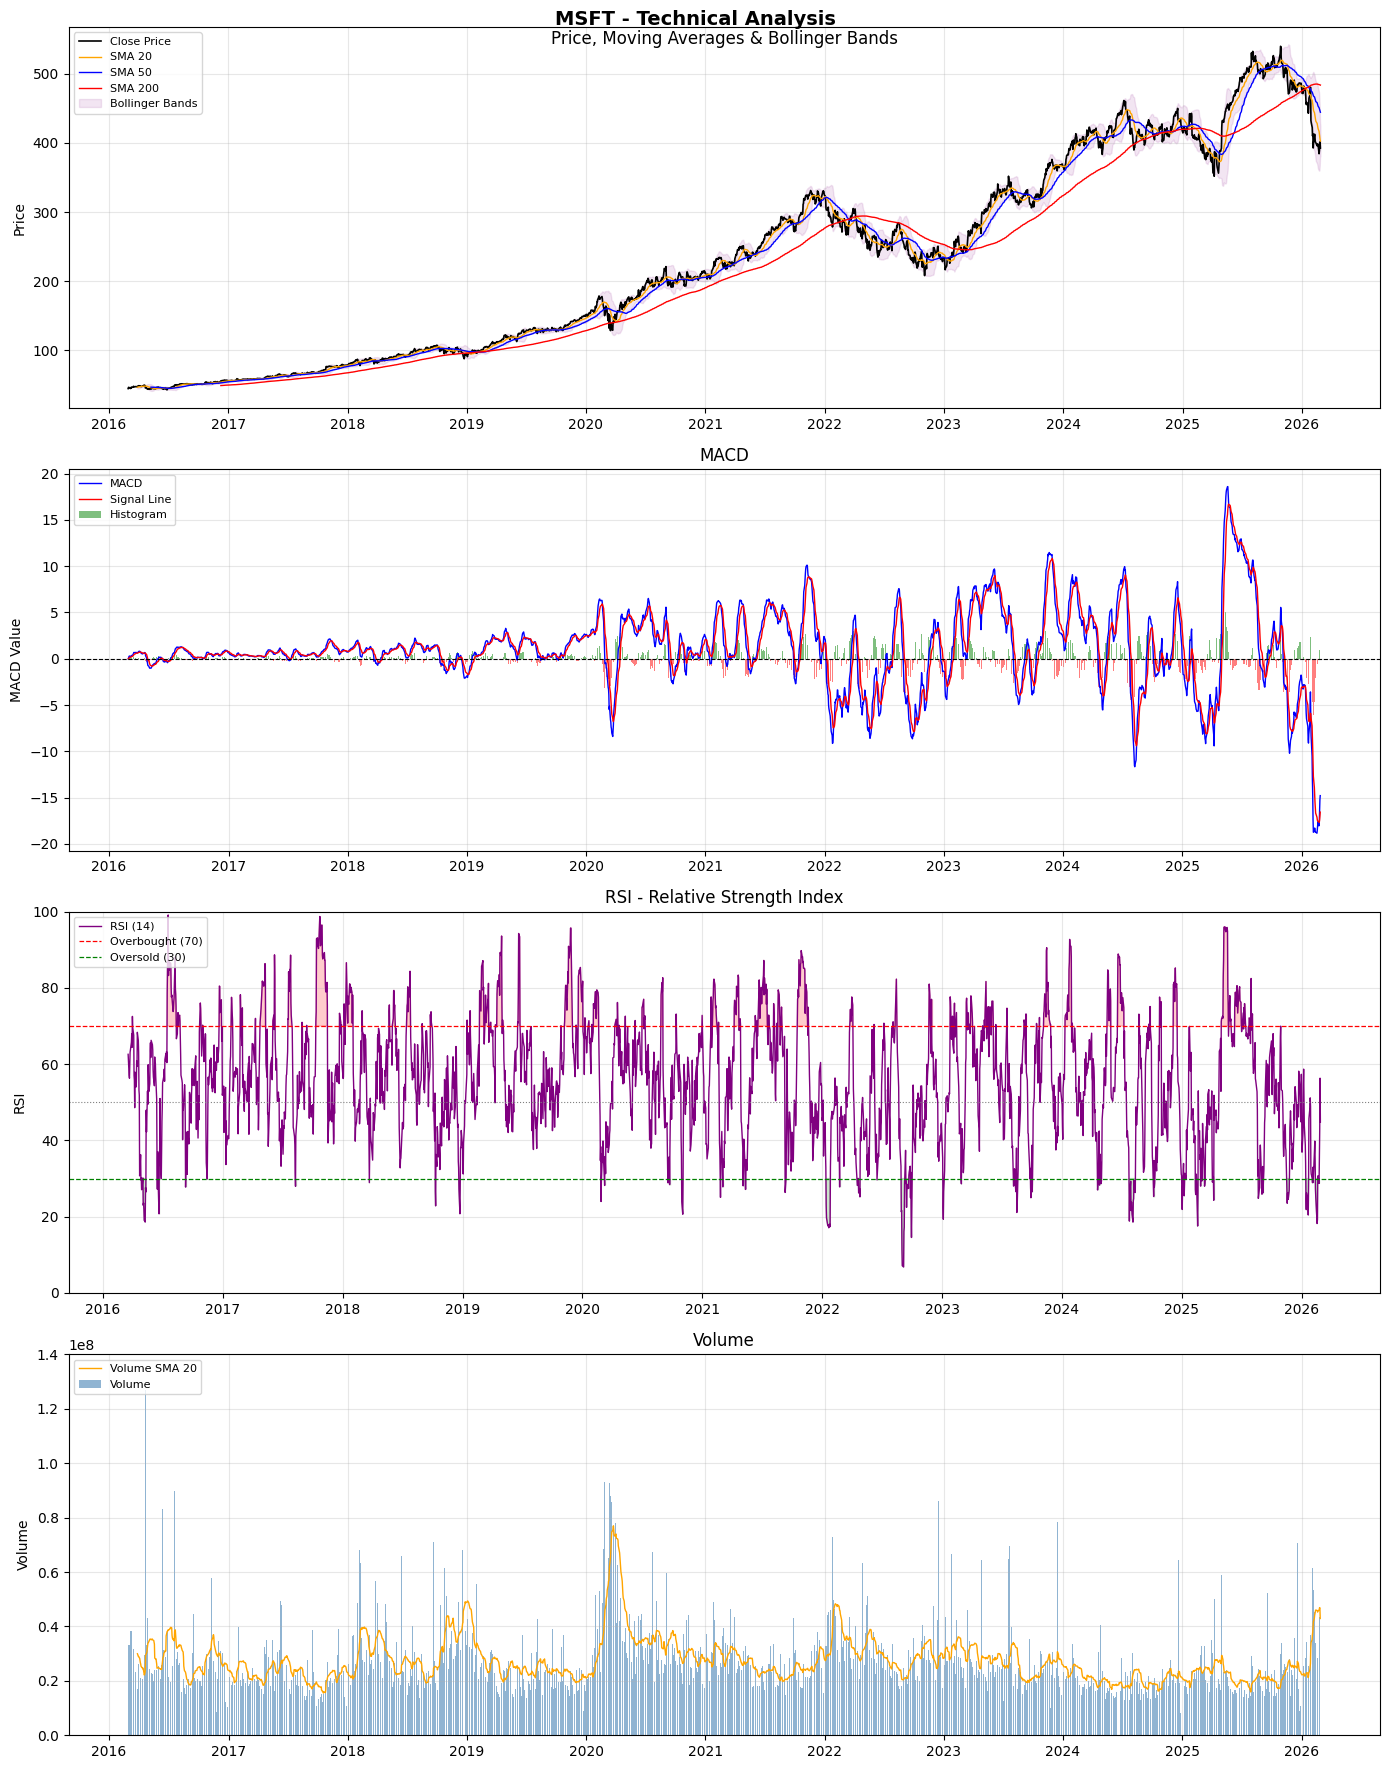


────────────────────────────────────────────────────────────
  SIGNAL BREAKDOWN
────────────────────────────────────────────────────────────
  [ BEARISH ]  SMA 50/200 Cross        Death Cross  - SMA50 (444.47) < SMA200 (483.78)
  [ BEARISH ]  Price vs SMA 20         Price (392.74) below SMA20 (402.84) - short-term downtrend
  [ BEARISH ]  Price vs SMA 50         Price (392.74) below SMA50 (444.47) - medium-term downtrend
  [ NEUTRAL ]  RSI                     Neutral   (RSI = 44.8) - no extreme reading
  [ BEARISH ]  RSI Momentum            RSI falling(56.3 -> 44.8) - losing momentum
  [ BULLISH ]  MACD vs Signal          MACD (-14.784) above Signal (-16.568) - bullish
  [ BULLISH ]  MACD Histogram          Histogram expanding above zero - strengthening bullish momentum
  [ NEUTRAL ]  Bollinger Bands         Price in lower half of bands (position: 27%)
  [ BEARISH ]  Volume                  Above-average volume on down day - selling pressure
  [ NEUTRAL ]  ATR Volatility          ATR 

In [5]:
# Technical Analysis

print(f"\n{'='*60}")
print(f"  TECHNICAL ANALYSIS - {stock_ticker}")
print(f"{'='*60}\n")

# Indicators
# Moving Averages
history['SMA_20']  = history['Close'].rolling(window=20).mean()
history['SMA_50']  = history['Close'].rolling(window=50).mean()
history['SMA_200'] = history['Close'].rolling(window=200).mean()
history['EMA_12']  = history['Close'].ewm(span=12, adjust=False).mean()
history['EMA_26']  = history['Close'].ewm(span=26, adjust=False).mean()

# MACD
history['MACD']        = history['EMA_12'] - history['EMA_26']
history['MACD_Signal'] = history['MACD'].ewm(span=9, adjust=False).mean()
history['MACD_Hist']   = history['MACD'] - history['MACD_Signal']

# RSI (14-period)
delta     = history['Close'].diff()
gain      = delta.clip(lower=0).rolling(window=14).mean()
loss      = (-delta.clip(upper=0)).rolling(window=14).mean()
rs        = gain / loss
history['RSI'] = 100 - (100 / (1 + rs))

# Bollinger Bands (20-period)
history['BB_Mid']   = history['Close'].rolling(window=20).mean()
history['BB_Std']   = history['Close'].rolling(window=20).std()
history['BB_Upper'] = history['BB_Mid'] + 2 * history['BB_Std']
history['BB_Lower'] = history['BB_Mid'] - 2 * history['BB_Std']

# Average True Range - volatility measure
history['Prev_Close'] = history['Close'].shift(1)
history['TR'] = pd.concat([
    history['High'] - history['Low'],
    (history['High'] - history['Prev_Close']).abs(),
    (history['Low']  - history['Prev_Close']).abs()
], axis=1).max(axis=1)
history['ATR'] = history['TR'].rolling(window=14).mean()

# Volume SMA
history['Vol_SMA_20'] = history['Volume'].rolling(window=20).mean()

# Daily Return
history['Daily Return'] = history['Close'].pct_change()

# Plots
fig, axes = plt.subplots(4, 1, figsize=(14, 18), sharex=False)
fig.suptitle(f"{stock_ticker} - Technical Analysis", fontsize=14, fontweight='bold')
fig.subplots_adjust(top=0.90)

# Plot 1: Price + Moving Averages + Bollinger Bands
ax1 = axes[0]
ax1.plot(history['Close'],   label='Close Price', color='black', linewidth=1.2)
ax1.plot(history['SMA_20'],  label='SMA 20',      color='orange',   linewidth=1)
ax1.plot(history['SMA_50'],  label='SMA 50',      color='blue',     linewidth=1)
ax1.plot(history['SMA_200'], label='SMA 200',     color='red',      linewidth=1)
ax1.fill_between(history.index, history['BB_Upper'], history['BB_Lower'],
                 alpha=0.1, color='purple', label='Bollinger Bands')
ax1.set_title("Price, Moving Averages & Bollinger Bands",pad=15,y=.90)
ax1.set_ylabel("Price")
ax1.legend(loc='upper left', fontsize=8)
ax1.grid(True, alpha=0.3)

# Plot 2: MACD
ax2 = axes[1]
ax2.plot(history['MACD'],        label='MACD',        color='blue',  linewidth=1)
ax2.plot(history['MACD_Signal'], label='Signal Line', color='red',   linewidth=1)
ax2.bar(history.index, history['MACD_Hist'],
        label='Histogram', color=history['MACD_Hist'].apply(lambda x: 'green' if x >= 0 else 'red'),
        alpha=0.5, width=1)
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_title("MACD")
ax2.set_ylabel("MACD Value")
ax2.legend(loc='upper left', fontsize=8)
ax2.grid(True, alpha=0.3)

# Plot 3: RSI
ax3 = axes[2]
ax3.plot(history['RSI'], label='RSI (14)', color='purple', linewidth=1)
ax3.axhline(70, color='red',   linestyle='--', linewidth=0.9, label='Overbought (70)')
ax3.axhline(30, color='green', linestyle='--', linewidth=0.9, label='Oversold (30)')
ax3.axhline(50, color='gray',  linestyle=':',  linewidth=0.8)
ax3.fill_between(history.index, history['RSI'], 70,
                 where=(history['RSI'] >= 70), alpha=0.2, color='red')
ax3.fill_between(history.index, history['RSI'], 30,
                 where=(history['RSI'] <= 30), alpha=0.2, color='green')
ax3.set_ylim(0, 100)
ax3.set_title("RSI - Relative Strength Index")
ax3.set_ylabel("RSI")
ax3.legend(loc='upper left', fontsize=8)
ax3.grid(True, alpha=0.3)

# Plot 4: Volume
ax4 = axes[3]
ax4.bar(history.index, history['Volume'], color='steelblue', alpha=0.6, width=1, label='Volume')
ax4.plot(history['Vol_SMA_20'], color='orange', linewidth=1, label='Volume SMA 20')
ax4.set_title("Volume")
ax4.set_ylabel("Volume")
ax4.legend(loc='upper left', fontsize=8)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Signal Scoring Engine
latest       = history.iloc[-1]
prev         = history.iloc[-2]
close        = latest['Close']

tech_signals = []  # (label, score, weight, comment)

def add_tech_signal(label, score, weight, comment):
    tech_signals.append((label, score, weight, comment))

# Golden / Death Cross
sma50  = latest['SMA_50']
sma200 = latest['SMA_200']
if sma50 > sma200:
    add_tech_signal("SMA 50/200 Cross",  +1, 3, f"Golden Cross - SMA50 ({sma50:.2f}) > SMA200 ({sma200:.2f})")
else:
    add_tech_signal("SMA 50/200 Cross",  -1, 3, f"Death Cross  - SMA50 ({sma50:.2f}) < SMA200 ({sma200:.2f})")

# Price vs SMA 20
sma20 = latest['SMA_20']
if close > sma20:
    add_tech_signal("Price vs SMA 20",   +1, 2, f"Price ({close:.2f}) above SMA20 ({sma20:.2f}) - short-term uptrend")
else:
    add_tech_signal("Price vs SMA 20",   -1, 2, f"Price ({close:.2f}) below SMA20 ({sma20:.2f}) - short-term downtrend")

# Price vs SMA 50
if close > sma50:
    add_tech_signal("Price vs SMA 50",   +1, 2, f"Price ({close:.2f}) above SMA50 ({sma50:.2f}) - medium-term uptrend")
else:
    add_tech_signal("Price vs SMA 50",   -1, 2, f"Price ({close:.2f}) below SMA50 ({sma50:.2f}) - medium-term downtrend")

# RSI
rsi = latest['RSI']
if rsi < 30:
    add_tech_signal("RSI",               +1, 2, f"Oversold  (RSI = {rsi:.1f}) - potential reversal upward")
elif rsi > 70:
    add_tech_signal("RSI",               -1, 2, f"Overbought(RSI = {rsi:.1f}) - potential pullback")
else:
    add_tech_signal("RSI",                0, 2, f"Neutral   (RSI = {rsi:.1f}) - no extreme reading")

# RSI trend (momentum direction)
rsi_prev = prev['RSI']
if rsi > rsi_prev:
    add_tech_signal("RSI Momentum",      +1, 1, f"RSI rising ({rsi_prev:.1f} -> {rsi:.1f}) - gaining momentum")
else:
    add_tech_signal("RSI Momentum",      -1, 1, f"RSI falling({rsi_prev:.1f} -> {rsi:.1f}) - losing momentum")

# MACD
macd        = latest['MACD']
macd_signal = latest['MACD_Signal']
macd_hist   = latest['MACD_Hist']
prev_hist   = prev['MACD_Hist']

if macd > macd_signal:
    add_tech_signal("MACD vs Signal",    +1, 2, f"MACD ({macd:.3f}) above Signal ({macd_signal:.3f}) - bullish")
else:
    add_tech_signal("MACD vs Signal",    -1, 2, f"MACD ({macd:.3f}) below Signal ({macd_signal:.3f}) - bearish")

if macd_hist > 0 and macd_hist > prev_hist:
    add_tech_signal("MACD Histogram",    +1, 1, "Histogram expanding above zero - strengthening bullish momentum")
elif macd_hist < 0 and macd_hist < prev_hist:
    add_tech_signal("MACD Histogram",    -1, 1, "Histogram expanding below zero - strengthening bearish momentum")
else:
    add_tech_signal("MACD Histogram",     0, 1, "Histogram contracting - momentum weakening or reversing")

# Bollinger Bands
bb_upper = latest['BB_Upper']
bb_lower = latest['BB_Lower']
bb_mid   = latest['BB_Mid']

if close < bb_lower:
    add_tech_signal("Bollinger Bands",   +1, 2, f"Price ({close:.2f}) below lower band ({bb_lower:.2f}) - oversold zone")
elif close > bb_upper:
    add_tech_signal("Bollinger Bands",   -1, 2, f"Price ({close:.2f}) above upper band ({bb_upper:.2f}) - overbought zone")
else:
    bb_pos = (close - bb_lower) / (bb_upper - bb_lower)
    if bb_pos > 0.5:
        add_tech_signal("Bollinger Bands", 0, 2, f"Price in upper half of bands (position: {bb_pos:.0%})")
    else:
        add_tech_signal("Bollinger Bands", 0, 2, f"Price in lower half of bands (position: {bb_pos:.0%})")

# Volume confirmation
vol     = latest['Volume']
vol_avg = latest['Vol_SMA_20']
daily_r = latest['Daily Return']

if vol > vol_avg and daily_r > 0:
    add_tech_signal("Volume",            +1, 2, f"Above-average volume on up day - buying conviction")
elif vol > vol_avg and daily_r < 0:
    add_tech_signal("Volume",            -1, 2, f"Above-average volume on down day - selling pressure")
else:
    add_tech_signal("Volume",             0, 1, f"Below-average volume - low conviction move")

# ATR (volatility context - informational)
atr = latest['ATR']
atr_pct = (atr / close) * 100
add_tech_signal("ATR Volatility",        0, 0, f"ATR = {atr:.2f}  ({atr_pct:.1f}% of price) - daily range context")

# Compute Weighted Score & Confidence
weighted_score = sum(s * w for _, s, w, _ in tech_signals)
max_possible   = sum(abs(s) * w for _, s, w, _ in tech_signals) or 1
norm_score     = weighted_score / max_possible

n_bullish = sum(1 for _, s, _, _ in tech_signals if s > 0)
n_bearish = sum(1 for _, s, _, _ in tech_signals if s < 0)
n_neutral = sum(1 for _, s, _, _ in tech_signals if s == 0)
n_total   = len(tech_signals)

consensus_ratio = abs(n_bullish - n_bearish) / n_total if n_total > 0 else 0
signal_coverage = min(n_total / 10, 1.0)
confidence      = round((0.65 * consensus_ratio + 0.35 * signal_coverage) * 100, 1)

if   norm_score >= 0.50:  decision = "STRONG BUY"
elif norm_score >= 0.20:  decision = "BUY"
elif norm_score >= 0.05:  decision = "WEAK BUY"
elif norm_score > -0.05:  decision = "HOLD"
elif norm_score > -0.20:  decision = "WEAK SELL"
elif norm_score > -0.50:  decision = "SELL"
else:                     decision = "STRONG SELL"

# Print Report
print(f"\n{'─'*60}")
print(f"  SIGNAL BREAKDOWN")
print(f"{'─'*60}")
for label, score, weight, comment in tech_signals:
    tag = "[ BULLISH ]" if score > 0 else ("[ BEARISH ]" if score < 0 else "[ NEUTRAL ]")
    print(f"  {tag}  {label:<22}  {comment}")

print(f"\n{'─'*60}")
print(f"  SCORING SUMMARY")
print(f"{'─'*60}")
print(f"  Bullish signals   : {n_bullish} / {n_total}")
print(f"  Bearish signals   : {n_bearish} / {n_total}")
print(f"  Neutral signals   : {n_neutral} / {n_total}")
print(f"  Weighted score    : {weighted_score:+.1f}  (normalised: {norm_score:+.3f})")
print(f"\n  Confidence Level  : {confidence}%")
print(f"  Recommendation    : {decision}")
print(f"{'='*60}\n")

print(f"  Latest Close : {close:.2f}")
print(f"  ATR (14)     : {atr:.2f}  ({atr_pct:.1f}% daily range)")
print(f"  RSI (14)     : {rsi:.1f}")
print(f"  MACD         : {macd:.4f}  |  Signal: {macd_signal:.4f}")

technical_analysis   = decision
technical_confidence = confidence

# Linear Regression


  LINEAR REGRESSION - MSFT

  Metric                                Value
  ────────────────────────────────────────────
  Mean Absolute Error (MAE)            4.5563
  Mean Squared Error (MSE)            43.2277
  Root MSE (RMSE)                      6.5748
  R-Squared                            0.9773
  MAPE (%)                               1.05%
  Directional Accuracy                   49.5%


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


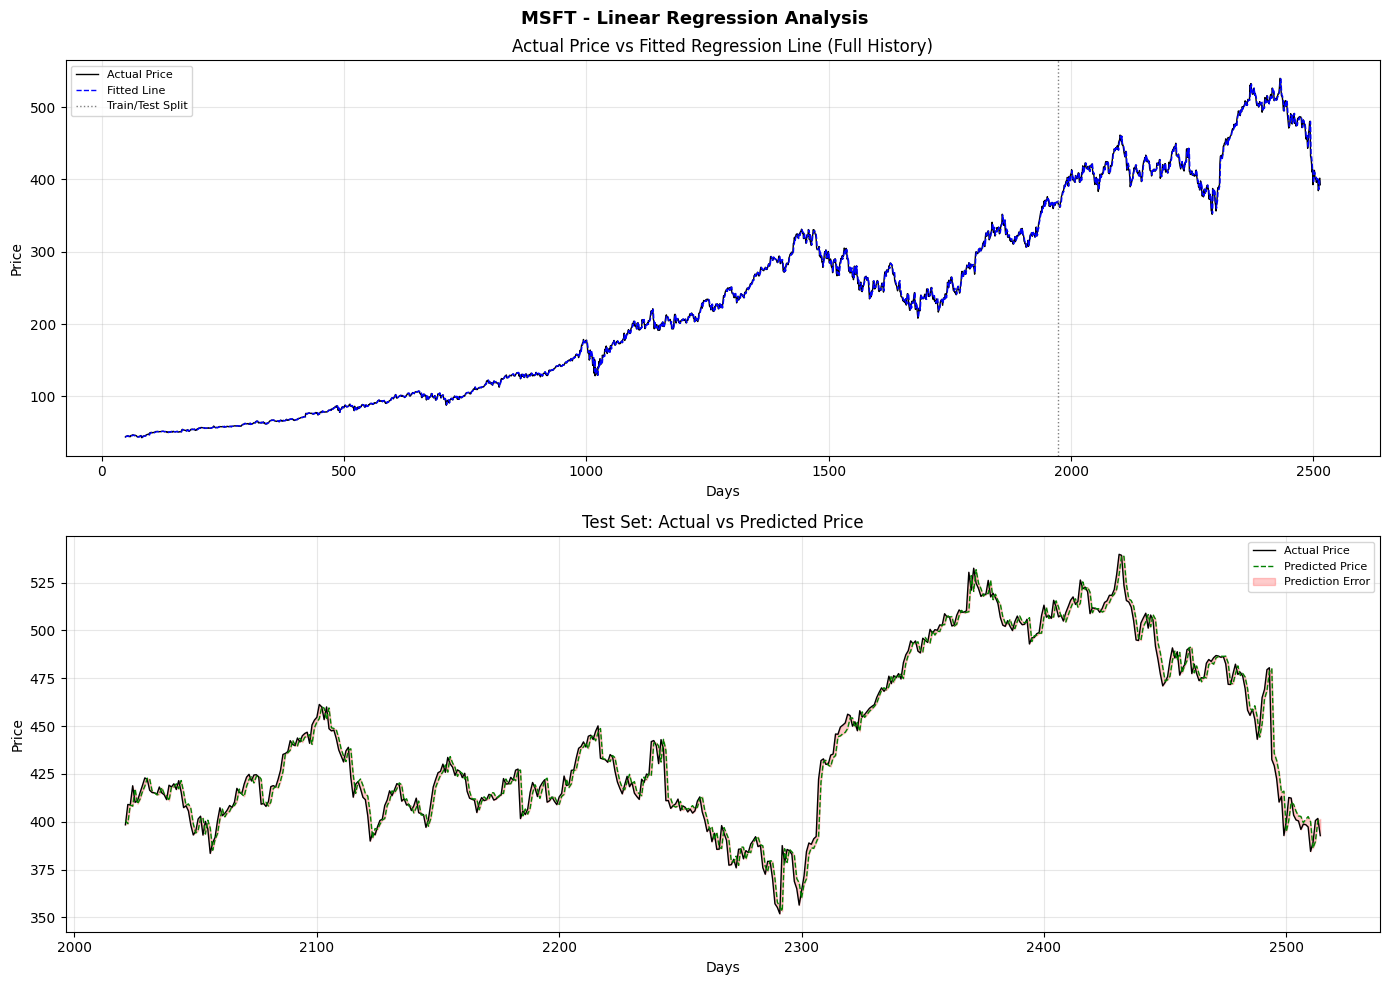


────────────────────────────────────────────────────────────
  SIGNAL BREAKDOWN
────────────────────────────────────────────────────────────
  [ BULLISH ]  Price Prediction          Predicted (393.19) > Current (392.74)  [+0.11%]
  [ NEUTRAL ]  Change Magnitude          Predicted move of +0.11% - marginal signal
  [ BULLISH ]  Fitted Trend              Regression slope positive (+1.7174) - upward trend
  [ BULLISH ]  Model R-Squared           High fit quality (R2 = 0.9773) - predictions reliable
  [ BEARISH ]  Directional Accuracy      Poor directional accuracy (49.5%) - below random
  [ BULLISH ]  MAPE                      Low prediction error (MAPE = 1.05%)

────────────────────────────────────────────────────────────
  SCORING SUMMARY
────────────────────────────────────────────────────────────
  Bullish signals   : 4 / 6
  Bearish signals   : 1 / 6
  Weighted score    : +6.0  (normalised: +0.600)

  Confidence Level  : 86.1%
  Recommendation    : STRONG BUY

  Current Price     : 

In [6]:
# Linear Regression
print(f"\n{'='*60}")
print(f"  LINEAR REGRESSION - {stock_ticker}")
print(f"{'='*60}\n")

# Data Preparation
history = ticker.history(period="10y").dropna()

df = history[['Close']].reset_index(drop=True)
df['Day'] = np.arange(len(df))

# Feature engineering - additional predictors beyond raw day index
df['SMA_20']      = df['Close'].rolling(window=20).mean()
df['SMA_50']      = df['Close'].rolling(window=50).mean()
df['Daily_Return']= df['Close'].pct_change()
df['Volatility']  = df['Daily_Return'].rolling(window=20).std()
df['Lag_1']       = df['Close'].shift(1)
df['Lag_5']       = df['Close'].shift(5)
df['Lag_10']      = df['Close'].shift(10)
df = df.dropna().reset_index(drop=True)

features = ['Day', 'SMA_20', 'SMA_50', 'Volatility', 'Lag_1', 'Lag_5', 'Lag_10']
X = df[features]
y = df['Close']

# Chronological split - preserve time order (no shuffle)
split_idx      = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Scale features
scaler  = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Model Training
model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train)
y_pred = model_lr.predict(X_test_scaled)

# Evaluation Metrics
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test.values - y_pred) / y_test.values)) * 100

# Directional accuracy - did the model predict up/down correctly?
actual_direction    = np.sign(np.diff(y_test.values))
predicted_direction = np.sign(np.diff(y_pred))
directional_acc     = np.mean(actual_direction == predicted_direction) * 100

print(f"  {'Metric':<30} {'Value':>12}")
print(f"  {'─'*44}")
print(f"  {'Mean Absolute Error (MAE)':<30} {mae:>12.4f}")
print(f"  {'Mean Squared Error (MSE)':<30} {mse:>12.4f}")
print(f"  {'Root MSE (RMSE)':<30} {rmse:>12.4f}")
print(f"  {'R-Squared':<30} {r2:>12.4f}")
print(f"  {'MAPE (%)':<30} {mape:>12.2f}%")
print(f"  {'Directional Accuracy':<30} {directional_acc:>12.1f}%")

# Confidence Score
# Weighted combination of R2, MAPE quality, and directional accuracy
r2_score_norm    = max(r2, 0)
mape_score       = max(0, 1 - (mape / 100))
dir_score        = directional_acc / 100
confidence       = round((0.40 * r2_score_norm + 0.35 * mape_score + 0.25 * dir_score) * 100, 1)

# Prediction
last_row       = df.iloc[-1]
current_price  = last_row['Close']

next_features = pd.DataFrame([{
    'Day':          last_row['Day'] + 1,
    'SMA_20':       last_row['SMA_20'],
    'SMA_50':       last_row['SMA_50'],
    'Volatility':   last_row['Volatility'],
    'Lag_1':        current_price,
    'Lag_5':        df['Close'].iloc[-5],
    'Lag_10':       df['Close'].iloc[-10],
}])

next_scaled        = scaler.transform(next_features)
predicted_price    = model_lr.predict(next_scaled)[0]
price_change       = predicted_price - current_price
price_change_pct   = (price_change / current_price) * 100

# Short-term trend from last 5 predictions on test set
recent_trend = np.polyfit(np.arange(5), y_pred[-5:], 1)[0]

# Signal Scoring
lr_signals = []

def add_lr_signal(label, score, weight, comment):
    lr_signals.append((label, score, weight, comment))

# Prediction direction
if predicted_price > current_price:
    add_lr_signal("Price Prediction",    +1, 3, f"Predicted ({predicted_price:.2f}) > Current ({current_price:.2f})  [{price_change_pct:+.2f}%]")
else:
    add_lr_signal("Price Prediction",    -1, 3, f"Predicted ({predicted_price:.2f}) < Current ({current_price:.2f})  [{price_change_pct:+.2f}%]")

# Magnitude of change
if abs(price_change_pct) > 2:
    score = +1 if price_change_pct > 0 else -1
    add_lr_signal("Change Magnitude",    score, 2, f"Predicted move of {price_change_pct:+.2f}% - significant signal")
else:
    add_lr_signal("Change Magnitude",    0, 2, f"Predicted move of {price_change_pct:+.2f}% - marginal signal")

# Recent trend of fitted line
if recent_trend > 0:
    add_lr_signal("Fitted Trend",        +1, 2, f"Regression slope positive ({recent_trend:+.4f}) - upward trend")
else:
    add_lr_signal("Fitted Trend",        -1, 2, f"Regression slope negative ({recent_trend:+.4f}) - downward trend")

# Model reliability
if r2 > 0.85:
    add_lr_signal("Model R-Squared",     +1, 2, f"High fit quality (R2 = {r2:.4f}) - predictions reliable")
elif r2 > 0.60:
    add_lr_signal("Model R-Squared",      0, 2, f"Moderate fit quality (R2 = {r2:.4f})")
else:
    add_lr_signal("Model R-Squared",     -1, 2, f"Low fit quality (R2 = {r2:.4f}) - predictions unreliable")

if directional_acc > 60:
    add_lr_signal("Directional Accuracy",+1, 2, f"Model correctly called direction {directional_acc:.1f}% of the time")
elif directional_acc > 50:
    add_lr_signal("Directional Accuracy", 0, 2, f"Marginal directional accuracy ({directional_acc:.1f}%)")
else:
    add_lr_signal("Directional Accuracy",-1, 2, f"Poor directional accuracy ({directional_acc:.1f}%) - below random")

# MAPE quality
if mape < 5:
    add_lr_signal("MAPE",                +1, 1, f"Low prediction error (MAPE = {mape:.2f}%)")
elif mape < 15:
    add_lr_signal("MAPE",                 0, 1, f"Moderate prediction error (MAPE = {mape:.2f}%)")
else:
    add_lr_signal("MAPE",                -1, 1, f"High prediction error (MAPE = {mape:.2f}%) - low reliability")

# Weighted Score and Decision
weighted_score = sum(s * w for _, s, w, _ in lr_signals)
max_possible   = sum(abs(s) * w for _, s, w, _ in lr_signals) or 1
norm_score     = weighted_score / max_possible

n_bullish = sum(1 for _, s, _, _ in lr_signals if s > 0)
n_bearish = sum(1 for _, s, _, _ in lr_signals if s < 0)
n_total   = len(lr_signals)

if   norm_score >= 0.50:  decision = "STRONG BUY"
elif norm_score >= 0.20:  decision = "BUY"
elif norm_score >= 0.05:  decision = "WEAK BUY"
elif norm_score > -0.05:  decision = "HOLD"
elif norm_score > -0.20:  decision = "WEAK SELL"
elif norm_score > -0.50:  decision = "SELL"
else:                     decision = "STRONG SELL"

# Plots
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle(f"{stock_ticker} - Linear Regression Analysis", fontsize=13, fontweight='bold')

# Plot 1: Full history - actual vs fitted
X_all_scaled = scaler.transform(X)
y_all_pred   = model_lr.predict(X_all_scaled)

ax1 = axes[0]
ax1.plot(df['Day'], df['Close'],  label='Actual Price',    color='black',  linewidth=1)
ax1.plot(df['Day'], y_all_pred,   label='Fitted Line',     color='blue',   linewidth=1,   linestyle='dashed')
ax1.axvline(x=split_idx, color='gray', linestyle=':', linewidth=1, label='Train/Test Split')
ax1.set_title("Actual Price vs Fitted Regression Line (Full History)")
ax1.set_xlabel("Days")
ax1.set_ylabel("Price")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Plot 2: Test set - actual vs predicted with residuals
test_days = df['Day'].iloc[split_idx:].values
ax2 = axes[1]
ax2.plot(test_days, y_test.values, label='Actual Price',    color='black', linewidth=1)
ax2.plot(test_days, y_pred,        label='Predicted Price', color='green', linewidth=1, linestyle='dashed')
ax2.fill_between(test_days, y_test.values, y_pred,
                 alpha=0.2, color='red', label='Prediction Error')
ax2.set_title("Test Set: Actual vs Predicted Price")
ax2.set_xlabel("Days")
ax2.set_ylabel("Price")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print Report
print(f"\n{'─'*60}")
print(f"  SIGNAL BREAKDOWN")
print(f"{'─'*60}")
for label, score, weight, comment in lr_signals:
    tag = "[ BULLISH ]" if score > 0 else ("[ BEARISH ]" if score < 0 else "[ NEUTRAL ]")
    print(f"  {tag}  {label:<24}  {comment}")

print(f"\n{'─'*60}")
print(f"  SCORING SUMMARY")
print(f"{'─'*60}")
print(f"  Bullish signals   : {n_bullish} / {n_total}")
print(f"  Bearish signals   : {n_bearish} / {n_total}")
print(f"  Weighted score    : {weighted_score:+.1f}  (normalised: {norm_score:+.3f})")
print(f"\n  Confidence Level  : {confidence}%")
print(f"  Recommendation    : {decision}")
print(f"{'='*60}\n")

print(f"  Current Price     : {current_price:.2f}")
print(f"  Predicted Price   : {predicted_price:.2f}  ({price_change_pct:+.2f}%)")

linear_regression_model      = decision
linear_regression_confidence = confidence

# Logistic Regression Model


  LOGISTIC REGRESSION - MSFT

  Prediction target     : 5-day forward price direction
  Total samples         : 2316
  Class balance         : Down=943  Up=1373

  Train class distribution  - Down: 737  Up: 1115
  After SMOTE               - Down: 1115  Up: 1115


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


  Best Hyperparameters  : {'C': 0.01, 'max_iter': 3000, 'penalty': 'l2', 'solver': 'lbfgs'}

  Metric                              Value
  ──────────────────────────────────────────
  Target Horizon                      5-day
  Overall Accuracy                   51.51%
  Directional Accuracy               45.79%
  Precision  (Up)                    56.23%
  Recall     (Up)                    57.75%
  F1 Score   (Up)                    56.98%
  Precision  (Down)                  45.23%
  Recall     (Down)                  43.69%
  F1 Score   (Down)                  44.44%
  True Positives                        149
  True Negatives                         90
  False Positives                       116
  False Negatives                       109


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


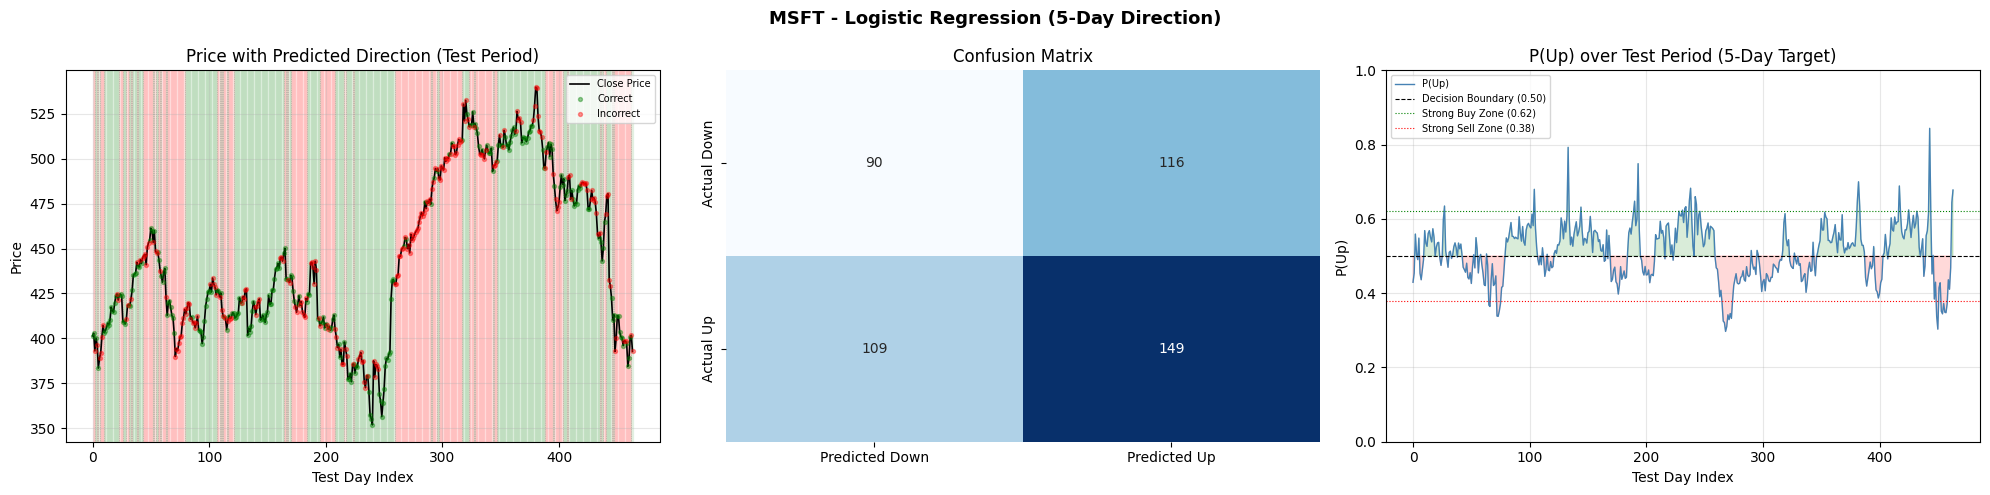


────────────────────────────────────────────────────────────
  SIGNAL BREAKDOWN
────────────────────────────────────────────────────────────
  [ BULLISH ]  5-Day Prediction            Model predicts UP over next 5 days  (prob = 0.678)
  [ BULLISH ]  Prediction Conviction       Above-threshold UP conviction   (0.678)
  [ NEUTRAL ]  Recent Signal Trend         Mixed signals (2 up / 3 down)
  [ BEARISH ]  Model Accuracy              At or below random baseline (51.5%)
  [ BEARISH ]  Directional Accuracy        Below-random directional accuracy (45.8%)
  [ NEUTRAL ]  F1 Balance                  Acceptable balance  (avg F1 = 0.507)

────────────────────────────────────────────────────────────
  SCORING SUMMARY
────────────────────────────────────────────────────────────
  Bullish signals   : 2 / 6
  Bearish signals   : 2 / 6
  Weighted score    : +1.0  (normalised: +0.111)

  Confidence Level  : 22.1%
  Recommendation    : WEAK BUY



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [7]:
# Logistic Regression
print(f"\n{'='*60}")
print(f"  LOGISTIC REGRESSION - {stock_ticker}")
print(f"{'='*60}\n")

from sklearn.model_selection import TimeSeriesSplit

# Feature Engineering
history = ticker.history(period="10y").dropna().copy()

history['Daily_Return']  = history['Close'].pct_change()
history['Return_5d']     = history['Close'].pct_change(5)
history['Return_10d']    = history['Close'].pct_change(10)
history['Return_20d']    = history['Close'].pct_change(20)

history['SMA_10']        = history['Close'].rolling(10).mean()
history['SMA_20']        = history['Close'].rolling(20).mean()
history['SMA_50']        = history['Close'].rolling(50).mean()
history['SMA_200']       = history['Close'].rolling(200).mean()
history['EMA_12']        = history['Close'].ewm(span=12, adjust=False).mean()
history['EMA_26']        = history['Close'].ewm(span=26, adjust=False).mean()
history['MACD']          = history['EMA_12'] - history['EMA_26']
history['MACD_Signal']   = history['MACD'].ewm(span=9, adjust=False).mean()
history['MACD_Diff']     = history['MACD'] - history['MACD_Signal']

history['Volatility_10'] = history['Daily_Return'].rolling(10).std()
history['Volatility_20'] = history['Daily_Return'].rolling(20).std()
history['Vol_Ratio']     = history['Volatility_10'] / (history['Volatility_20'] + 1e-9)

# RSI
delta               = history['Close'].diff()
gain                = delta.clip(lower=0).rolling(14).mean()
loss                = (-delta.clip(upper=0)).rolling(14).mean()
history['RSI']      = 100 - (100 / (1 + gain / loss))
history['RSI_SMA']  = history['RSI'].rolling(5).mean()
history['RSI_Diff'] = history['RSI'] - history['RSI_SMA']

# Bollinger Bands
bb_mid               = history['Close'].rolling(20).mean()
bb_std               = history['Close'].rolling(20).std()
bb_upper             = bb_mid + 2 * bb_std
bb_lower             = bb_mid - 2 * bb_std
history['BB_Pos']    = (history['Close'] - bb_lower) / (bb_upper - bb_lower + 1e-9)
history['BB_Width']  = (bb_upper - bb_lower) / (bb_mid + 1e-9)

# Price vs moving averages
history['Vs_SMA10']  = (history['Close'] - history['SMA_10'])  / history['SMA_10']
history['Vs_SMA50']  = (history['Close'] - history['SMA_50'])  / history['SMA_50']
history['Vs_SMA200'] = (history['Close'] - history['SMA_200']) / history['SMA_200']

# Volume features
history['Vol_Change']    = history['Volume'].pct_change()
history['Vol_SMA20']     = history['Volume'].rolling(20).mean()
history['Vol_Ratio_20']  = history['Volume'] / (history['Vol_SMA20'] + 1e-9)

# Lagged returns
for lag in [1, 2, 3, 5, 10]:
    history[f'Lag_{lag}'] = history['Daily_Return'].shift(lag)

FORWARD_DAYS = 5
history['Target'] = (history['Close'].shift(-FORWARD_DAYS) > history['Close']).astype(int)

features = [
    'Daily_Return', 'Return_5d', 'Return_10d', 'Return_20d',
    'MACD_Diff', 'RSI', 'RSI_Diff',
    'BB_Pos', 'BB_Width',
    'Volatility_10', 'Volatility_20', 'Vol_Ratio',
    'Vs_SMA10', 'Vs_SMA50', 'Vs_SMA200',
    'Vol_Change', 'Vol_Ratio_20',
    'Lag_1', 'Lag_2', 'Lag_3', 'Lag_5', 'Lag_10'
]

df_lr = history[features + ['Target', 'Close']].dropna().copy()

print(f"  Prediction target     : {FORWARD_DAYS}-day forward price direction")
print(f"  Total samples         : {len(df_lr)}")
print(f"  Class balance         : Down={int((df_lr['Target']==0).sum())}  Up={int((df_lr['Target']==1).sum())}")

# Chronological Split
split_idx   = int(len(df_lr) * 0.80)
train_df    = df_lr.iloc[:split_idx].copy()
test_df     = df_lr.iloc[split_idx:].copy()

X_train_raw = train_df[features].values
y_train_raw = train_df['Target'].values
X_test_raw  = test_df[features].values
y_test      = test_df['Target'].values

# Scale on training statistics only
scaler          = StandardScaler()
X_train_scaled  = scaler.fit_transform(X_train_raw)
X_test_scaled   = scaler.transform(X_test_raw)

# SMOTE on training set only
class_counts = np.bincount(y_train_raw)
k_neighbors  = min(5, class_counts.min() - 1)

print(f"\n  Train class distribution  - Down: {class_counts[0]}  Up: {class_counts[1]}")

if k_neighbors >= 1:
    smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
    X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train_raw)
    print(f"  After SMOTE               - Down: {int(np.sum(y_train_bal==0))}  Up: {int(np.sum(y_train_bal==1))}")
else:
    X_train_bal, y_train_bal = X_train_scaled, y_train_raw
    print(f"  SMOTE skipped - insufficient minority samples")

# Hyperparameter Tuning with TimeSeriesSplit
tscv       = TimeSeriesSplit(n_splits=5)
param_grid = {
    'C':        [0.01, 0.1, 0.5, 1, 5, 10],
    'penalty':  ['l2'],
    'solver':   ['lbfgs'],
    'max_iter': [3000]
}

grid_search = GridSearchCV(
    LogisticRegression(random_state=42, class_weight='balanced'),
    param_grid, cv=tscv, scoring='f1', n_jobs=-1, verbose=0
)
grid_search.fit(X_train_bal, y_train_bal)

best_model = grid_search.best_estimator_
y_pred     = best_model.predict(X_test_scaled)
y_prob     = best_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation
acc    = accuracy_score(y_test, y_pred)
report = classification_report(
    y_test, y_pred,
    target_names=['Down', 'Up'],
    output_dict=True,
    zero_division=0
)
cm = confusion_matrix(y_test, y_pred)

tn = int(cm[0, 0]) if cm.shape == (2, 2) else 0
fp = int(cm[0, 1]) if cm.shape == (2, 2) else 0
fn = int(cm[1, 0]) if cm.shape == (2, 2) else 0
tp = int(cm[1, 1]) if cm.shape == (2, 2) else 0

precision_up = report['Up']['precision']
recall_up    = report['Up']['recall']
f1_up        = report['Up']['f1-score']
precision_dn = report['Down']['precision']
recall_dn    = report['Down']['recall']
f1_dn        = report['Down']['f1-score']

# Directional accuracy
actual_dir      = np.sign(np.diff(test_df['Close'].values))
pred_dir        = np.sign(y_pred[1:] * 2 - 1)
directional_acc = np.mean(actual_dir == pred_dir) * 100

last_prob         = float(y_prob[-1])
last_pred         = int(y_pred[-1])
predicted_classes = len(np.unique(y_pred))

print(f"\n  Best Hyperparameters  : {grid_search.best_params_}")
print(f"\n  {'Metric':<30} {'Value':>10}")
print(f"  {'─'*42}")
print(f"  {'Target Horizon':<30} {f'{FORWARD_DAYS}-day':>10}")
print(f"  {'Overall Accuracy':<30} {acc*100:>9.2f}%")
print(f"  {'Directional Accuracy':<30} {directional_acc:>9.2f}%")
print(f"  {'Precision  (Up)':<30} {precision_up*100:>9.2f}%")
print(f"  {'Recall     (Up)':<30} {recall_up*100:>9.2f}%")
print(f"  {'F1 Score   (Up)':<30} {f1_up*100:>9.2f}%")
print(f"  {'Precision  (Down)':<30} {precision_dn*100:>9.2f}%")
print(f"  {'Recall     (Down)':<30} {recall_dn*100:>9.2f}%")
print(f"  {'F1 Score   (Down)':<30} {f1_dn*100:>9.2f}%")
print(f"  {'True Positives':<30} {tp:>10}")
print(f"  {'True Negatives':<30} {tn:>10}")
print(f"  {'False Positives':<30} {fp:>10}")
print(f"  {'False Negatives':<30} {fn:>10}")

RANDOM_BASELINE  = 0.50
STRONG_THRESHOLD = 0.68

collapse_penalty = 1.0 if predicted_classes > 1 else 0.15

acc_component  = max(0, min(1, (acc - RANDOM_BASELINE) / (STRONG_THRESHOLD - RANDOM_BASELINE)))
f1_component   = (f1_up + f1_dn) / 2
dir_component  = max(0, min(1, (directional_acc / 100 - RANDOM_BASELINE) / (STRONG_THRESHOLD - RANDOM_BASELINE)))
prob_component = abs(last_prob - 0.5) * 2

confidence = round(
    collapse_penalty *
    (0.40 * acc_component  +
     0.30 * f1_component   +
     0.20 * dir_component  +
     0.10 * prob_component) * 100,
    1
)

# Signal Scoring
lr2_signals = []

def add_lr2_signal(label, score, weight, comment):
    lr2_signals.append((label, score, weight, comment))

if predicted_classes == 1:
    add_lr2_signal("Model Health",          -2, 3, "CRITICAL: Model predicted only one class - results invalid")

if last_pred == 1:
    add_lr2_signal("5-Day Prediction",      +1, 3, f"Model predicts UP over next {FORWARD_DAYS} days  (prob = {last_prob:.3f})")
else:
    add_lr2_signal("5-Day Prediction",      -1, 3, f"Model predicts DOWN over next {FORWARD_DAYS} days (prob = {last_prob:.3f})")

if last_prob > 0.62:
    add_lr2_signal("Prediction Conviction", +1, 2, f"Above-threshold UP conviction   ({last_prob:.3f})")
elif last_prob < 0.38:
    add_lr2_signal("Prediction Conviction", -1, 2, f"Above-threshold DOWN conviction ({last_prob:.3f})")
else:
    add_lr2_signal("Prediction Conviction",  0, 2, f"Low conviction ({last_prob:.3f}) - near decision boundary")

recent_preds = y_pred[-5:]
up_count     = int(np.sum(recent_preds == 1))
dn_count     = int(np.sum(recent_preds == 0))
if up_count >= 4:
    add_lr2_signal("Recent Signal Trend",   +1, 2, f"Predicted UP {up_count}/5 recent periods")
elif dn_count >= 4:
    add_lr2_signal("Recent Signal Trend",   -1, 2, f"Predicted DOWN {dn_count}/5 recent periods")
else:
    add_lr2_signal("Recent Signal Trend",    0, 2, f"Mixed signals ({up_count} up / {dn_count} down)")

if acc > 0.62:
    add_lr2_signal("Model Accuracy",        +1, 2, f"Above-baseline accuracy ({acc*100:.1f}%) - signal reliable")
elif acc > 0.54:
    add_lr2_signal("Model Accuracy",         0, 2, f"Marginal accuracy ({acc*100:.1f}%) - slight edge over random")
else:
    add_lr2_signal("Model Accuracy",        -1, 2, f"At or below random baseline ({acc*100:.1f}%)")

if directional_acc > 56:
    add_lr2_signal("Directional Accuracy",  +1, 2, f"Reliable direction calls ({directional_acc:.1f}%)")
elif directional_acc > 50:
    add_lr2_signal("Directional Accuracy",   0, 2, f"Marginal directional accuracy ({directional_acc:.1f}%)")
else:
    add_lr2_signal("Directional Accuracy",  -1, 2, f"Below-random directional accuracy ({directional_acc:.1f}%)")

avg_f1 = (f1_up + f1_dn) / 2
if avg_f1 > 0.58:
    add_lr2_signal("F1 Balance",            +1, 1, f"Well-balanced model (avg F1 = {avg_f1:.3f})")
elif avg_f1 > 0.45:
    add_lr2_signal("F1 Balance",             0, 1, f"Acceptable balance  (avg F1 = {avg_f1:.3f})")
else:
    add_lr2_signal("F1 Balance",            -1, 1, f"Imbalanced model    (avg F1 = {avg_f1:.3f})")

# Weighted Score and Decision
weighted_score = sum(s * w for _, s, w, _ in lr2_signals)
max_possible   = sum(abs(s) * w for _, s, w, _ in lr2_signals) or 1
norm_score     = weighted_score / max_possible

n_bullish = sum(1 for _, s, _, _ in lr2_signals if s > 0)
n_bearish = sum(1 for _, s, _, _ in lr2_signals if s < 0)
n_total   = len(lr2_signals)

if   norm_score >= 0.50:  decision = "STRONG BUY"
elif norm_score >= 0.20:  decision = "BUY"
elif norm_score >= 0.05:  decision = "WEAK BUY"
elif norm_score > -0.05:  decision = "HOLD"
elif norm_score > -0.20:  decision = "WEAK SELL"
elif norm_score > -0.50:  decision = "SELL"
else:                     decision = "STRONG SELL"

if predicted_classes == 1:
    decision   = "HOLD (MODEL UNRELIABLE)"
    confidence = min(confidence, 10.0)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle(f"{stock_ticker} - Logistic Regression ({FORWARD_DAYS}-Day Direction)", fontsize=13, fontweight='bold')

# Plot 1: Price with predicted direction bands
ax1 = axes[0]
test_close  = test_df['Close'].values
test_index  = np.arange(len(test_close))

ax1.plot(test_index, test_close, color='black', linewidth=1.2, label='Close Price', zorder=3)

# Shade background by predicted direction
for i in range(len(y_pred) - 1):
    color = 'green' if y_pred[i] == 1 else 'red'
    ax1.axvspan(i, i + 1, alpha=0.08, color=color)

# Mark prediction changes
for i in range(1, len(y_pred)):
    if y_pred[i] != y_pred[i - 1]:
        ax1.axvline(x=i, color='gray', linewidth=0.5, linestyle=':', alpha=0.6)

# Correct / incorrect prediction markers on price line
correct_idx   = np.where(y_pred == y_test)[0]
incorrect_idx = np.where(y_pred != y_test)[0]
if len(correct_idx) > 0:
    ax1.scatter(correct_idx, test_close[correct_idx],
                color='green', s=8, alpha=0.4, zorder=4, label='Correct')
if len(incorrect_idx) > 0:
    ax1.scatter(incorrect_idx, test_close[incorrect_idx],
                color='red', s=8, alpha=0.4, zorder=4, label='Incorrect')

ax1.set_title(f"Price with Predicted Direction (Test Period)")
ax1.set_xlabel("Test Day Index")
ax1.set_ylabel("Price")
ax1.legend(fontsize=7)
ax1.grid(True, alpha=0.3)

# Plot 2: Confusion Matrix
ax2 = axes[1]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Down', 'Predicted Up'],
            yticklabels=['Actual Down', 'Actual Up'], ax=ax2)
ax2.set_title("Confusion Matrix")

# Plot 3: Predicted probability over test period
ax3 = axes[2]
ax3.plot(y_prob, color='steelblue', linewidth=1, label='P(Up)')
ax3.axhline(0.50, color='black', linestyle='--', linewidth=0.8, label='Decision Boundary (0.50)')
ax3.axhline(0.62, color='green', linestyle=':',  linewidth=0.8, label='Strong Buy Zone (0.62)')
ax3.axhline(0.38, color='red',   linestyle=':',  linewidth=0.8, label='Strong Sell Zone (0.38)')
ax3.fill_between(range(len(y_prob)), y_prob, 0.5,
                 where=(np.array(y_prob) >= 0.5), alpha=0.15, color='green')
ax3.fill_between(range(len(y_prob)), y_prob, 0.5,
                 where=(np.array(y_prob) <  0.5), alpha=0.15, color='red')
ax3.set_ylim(0, 1)
ax3.set_title(f"P(Up) over Test Period ({FORWARD_DAYS}-Day Target)")
ax3.set_xlabel("Test Day Index")
ax3.set_ylabel("P(Up)")
ax3.legend(fontsize=7)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print Report
print(f"\n{'─'*60}")
print(f"  SIGNAL BREAKDOWN")
print(f"{'─'*60}")
for label, score, weight, comment in lr2_signals:
    tag = "[ BULLISH ]" if score > 0 else ("[ BEARISH ]" if score < 0 else "[ NEUTRAL ]")
    print(f"  {tag}  {label:<26}  {comment}")

print(f"\n{'─'*60}")
print(f"  SCORING SUMMARY")
print(f"{'─'*60}")
print(f"  Bullish signals   : {n_bullish} / {n_total}")
print(f"  Bearish signals   : {n_bearish} / {n_total}")
print(f"  Weighted score    : {weighted_score:+.1f}  (normalised: {norm_score:+.3f})")
print(f"\n  Confidence Level  : {confidence}%")
print(f"  Recommendation    : {decision}")
print(f"{'='*60}\n")

logistic_regression_model      = decision
logistic_regression_confidence = confidence

# Random Forest Regressor & Classifier


  RANDOM FOREST - MSFT



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  Prediction target     : 5-day forward direction (classifier)
  Regression target     : Next-day return % (scale-free)
  Total samples         : 2315
  Feature count         : 44
  Class balance         : Down=942  Up=1373
  After SMOTE (clf)     : Down=1115  Up=1115

  Running feature pre-selection ...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

  Features after selection : 22 / 44
  Selected features        : ['Return_5d', 'Return_20d', 'Momentum_5', 'MACD_Diff_N', 'BB_Pos'] ...

  Tuning classifier ...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  Tuning regressor  ...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



  Best Classifier Params : {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 200}
  Best Regressor Params  : {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'n_estimators': 300}

  Metric                                     Value
  ─────────────────────────────────────────────────
  --- Regression (% return target) ---
  MAE (% return units)                     1.0565%
  RMSE (% return units)                    1.5579%
  R-Squared (return)                       -0.0277
  MAPE (return)                            170.04%
  Reg. Directional Acc.                     52.92%
  --- Regression (price, display only) ---
  MAE (price)                               4.6172
  RMSE (price)                              6.7325
  MAPE (price %)                             1.06%
  --- Classifier ---                 
  Overall Accuracy                          55.08%
  Balanced Accuracy                         52.07%
  Directional A

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


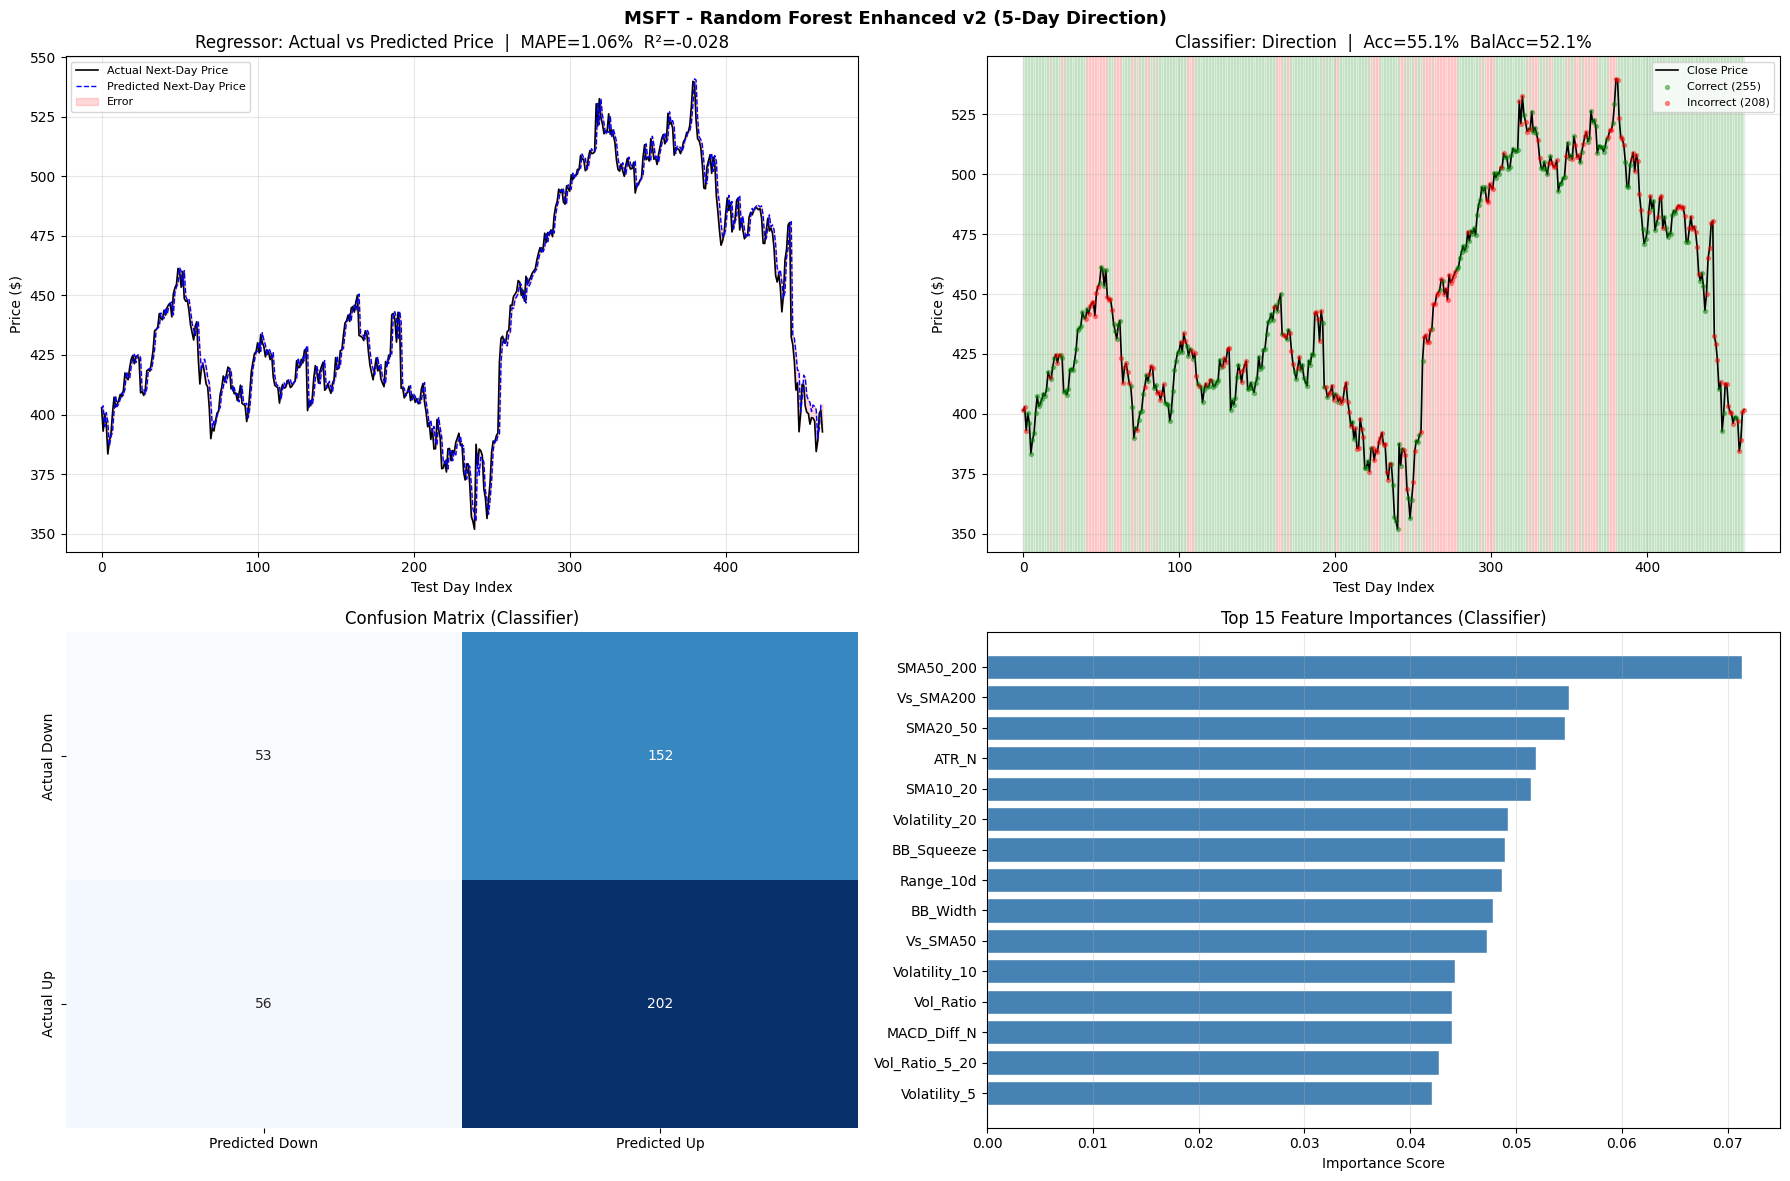


────────────────────────────────────────────────────────────
  SIGNAL BREAKDOWN
────────────────────────────────────────────────────────────
  [ BULLISH ]  5-Day Prediction              Classifier predicts UP over next 5 days  (prob = 0.606)
  [ NEUTRAL ]  Prediction Conviction         Low conviction (0.606) - near decision boundary
  [ BULLISH ]  Recent Signal Trend           Predicted UP 5/5 recent periods
  [ NEUTRAL ]  Classifier Accuracy           Marginal accuracy (55.1%) - slight edge over random
  [ BEARISH ]  Directional Accuracy          Below-random directional accuracy (49.6%)
  [ NEUTRAL ]  Regression R-Squared          Near-zero regression fit (R2 = -0.0277)
  [ BULLISH ]  Regression MAPE               Low price error (MAPE = 1.06%)
  [ NEUTRAL ]  F1 Balance                    Acceptable balance       (avg F1 = 0.499)
  [ BULLISH ]  Regressor Direction           Regressor predicts UP next day  (401.72 -> 404.35, +0.65%)
  [ NEUTRAL ]  Reg. Dir. Accuracy            Margin

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [8]:
# Random Forest Regressor & Classifier
print(f"\n{'='*60}")
print(f"  RANDOM FOREST - {stock_ticker}")
print(f"{'='*60}\n")

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import balanced_accuracy_score

# Feature Engineering
history = ticker.history(period="10y").dropna().copy()

# Core returns
history['Daily_Return']   = history['Close'].pct_change()
history['Return_3d']      = history['Close'].pct_change(3)
history['Return_5d']      = history['Close'].pct_change(5)
history['Return_10d']     = history['Close'].pct_change(10)
history['Return_20d']     = history['Close'].pct_change(20)

# Moving averages
history['EMA_12']         = history['Close'].ewm(span=12, adjust=False).mean()
history['EMA_26']         = history['Close'].ewm(span=26, adjust=False).mean()
history['SMA_10']         = history['Close'].rolling(10).mean()
history['SMA_20']         = history['Close'].rolling(20).mean()
history['SMA_50']         = history['Close'].rolling(50).mean()
history['SMA_200']        = history['Close'].rolling(200).mean()

history['MACD']           = history['EMA_12'] - history['EMA_26']
history['MACD_Signal']    = history['MACD'].ewm(span=9, adjust=False).mean()
history['MACD_Diff_N']    = (history['MACD'] - history['MACD_Signal']) / (history['Close'] + 1e-9)

# All MA features expressed as % deviation from close
history['Vs_SMA10']       = (history['Close'] / history['SMA_10'])  - 1
history['Vs_SMA20']       = (history['Close'] / history['SMA_20'])  - 1
history['Vs_SMA50']       = (history['Close'] / history['SMA_50'])  - 1
history['Vs_SMA200']      = (history['Close'] / history['SMA_200']) - 1
history['SMA10_20']       = (history['SMA_10'] / history['SMA_20']) - 1
history['SMA20_50']       = (history['SMA_20'] / history['SMA_50']) - 1
history['SMA50_200']      = (history['SMA_50'] / history['SMA_200'])- 1

# Volatility
history['Volatility_5']   = history['Daily_Return'].rolling(5).std()
history['Volatility_10']  = history['Daily_Return'].rolling(10).std()
history['Volatility_20']  = history['Daily_Return'].rolling(20).std()
history['Vol_Ratio']      = history['Volatility_10'] / (history['Volatility_20'] + 1e-9)
history['Vol_Ratio_5_20'] = history['Volatility_5']  / (history['Volatility_20'] + 1e-9)

# RSI
delta               = history['Close'].diff()
gain                = delta.clip(lower=0).rolling(14).mean()
loss                = (-delta.clip(upper=0)).rolling(14).mean()
history['RSI']      = 100 - (100 / (1 + gain / (loss + 1e-9)))
history['RSI_SMA']  = history['RSI'].rolling(5).mean()
history['RSI_Diff'] = history['RSI'] - history['RSI_SMA']

# Stochastic RSI
rsi_min              = history['RSI'].rolling(14).min()
rsi_max              = history['RSI'].rolling(14).max()
history['StochRSI']  = (history['RSI'] - rsi_min) / (rsi_max - rsi_min + 1e-9)

# Bollinger Bands
bb_mid               = history['Close'].rolling(20).mean()
bb_std               = history['Close'].rolling(20).std()
bb_upper             = bb_mid + 2 * bb_std
bb_lower             = bb_mid - 2 * bb_std
history['BB_Pos']    = (history['Close'] - bb_lower) / (bb_upper - bb_lower + 1e-9)
history['BB_Width']  = (bb_upper - bb_lower) / (bb_mid + 1e-9)
history['BB_Squeeze']= history['BB_Width'] / (history['BB_Width'].rolling(50).mean() + 1e-9)

# ATR
history['Prev_Close'] = history['Close'].shift(1)
history['TR']         = pd.concat([
    history['High'] - history['Low'],
    (history['High'] - history['Prev_Close']).abs(),
    (history['Low']  - history['Prev_Close']).abs()
], axis=1).max(axis=1)
history['ATR']        = history['TR'].rolling(14).mean()
history['ATR_N']      = history['ATR'] / (history['Close'] + 1e-9)

# Price structure
history['HL_Range']   = (history['High'] - history['Low']) / (history['Close'] + 1e-9)
history['Close_Pos']  = (history['Close'] - history['Low']) / (history['High'] - history['Low'] + 1e-9)
history['Range_10d']  = (history['High'].rolling(10).max() - history['Low'].rolling(10).min()) / (history['Close'] + 1e-9)

# Momentum
history['Momentum_5']  = history['Close'].pct_change(5)
history['Momentum_10'] = history['Close'].pct_change(10)
history['Momentum_20'] = history['Close'].pct_change(20)

# Volume
history['Vol_SMA20']    = history['Volume'].rolling(20).mean()
history['Vol_Ratio_20'] = history['Volume'] / (history['Vol_SMA20'] + 1e-9)
history['Vol_Ratio_5']  = history['Volume'] / (history['Volume'].rolling(5).mean() + 1e-9)
history['Vol_Change']   = history['Volume'].pct_change()

# Lagged returns and volume ratios
for lag in [1, 2, 3, 5, 10, 15, 20]:
    history[f'Lag_{lag}'] = history['Daily_Return'].shift(lag)
for lag in [1, 2, 3]:
    history[f'Vol_Lag_{lag}'] = history['Vol_Ratio_20'].shift(lag)

FORWARD_DAYS = 5
history['Target_reg_pct'] = history['Close'].pct_change(1).shift(-1)
history['Target_clf']     = (history['Close'].shift(-FORWARD_DAYS) > history['Close']).astype(int)

features = [
    # Returns & momentum
    'Daily_Return', 'Return_3d', 'Return_5d', 'Return_10d', 'Return_20d',
    'Momentum_5', 'Momentum_10', 'Momentum_20',
    'MACD_Diff_N',
    'RSI', 'RSI_Diff', 'StochRSI',
    'BB_Pos', 'BB_Width', 'BB_Squeeze',
    'Vs_SMA10', 'Vs_SMA20', 'Vs_SMA50', 'Vs_SMA200',
    'SMA10_20', 'SMA20_50', 'SMA50_200',
    # Volatility
    'Volatility_5', 'Volatility_10', 'Volatility_20',
    'Vol_Ratio', 'Vol_Ratio_5_20',
    'ATR_N',
    # Price structure
    'HL_Range', 'Close_Pos', 'Range_10d',
    # Volume
    'Vol_Change', 'Vol_Ratio_20', 'Vol_Ratio_5',
    'Vol_Lag_1', 'Vol_Lag_2', 'Vol_Lag_3',
    # Lags
    'Lag_1', 'Lag_2', 'Lag_3', 'Lag_5', 'Lag_10', 'Lag_15', 'Lag_20',
]

df_rf = history[features + ['Close', 'Target_clf', 'Target_reg_pct']].dropna().copy()

print(f"  Prediction target     : {FORWARD_DAYS}-day forward direction (classifier)")
print(f"  Regression target     : Next-day return % (scale-free)")
print(f"  Total samples         : {len(df_rf)}")
print(f"  Feature count         : {len(features)}")
print(f"  Class balance         : Down={int((df_rf['Target_clf']==0).sum())}  Up={int((df_rf['Target_clf']==1).sum())}")

# Chronological Train / Test Split
split_idx = int(len(df_rf) * 0.80)
train_df  = df_rf.iloc[:split_idx].copy()
test_df   = df_rf.iloc[split_idx:].copy()

X_train = train_df[features].values
X_test  = test_df[features].values

# Regression targets
# Use pct return — fully scale-free, no inverse-transform needed
y_train_reg = train_df['Target_reg_pct'].values
y_test_reg  = test_df['Target_reg_pct'].values

# Classification targets
y_train_clf = train_df['Target_clf'].values
y_test_clf  = test_df['Target_clf'].values

# Scale features
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# SMOTE
class_counts = np.bincount(y_train_clf)
k_neighbors  = min(5, class_counts.min() - 1)

if k_neighbors >= 1:
    smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
    X_train_clf_bal, y_train_clf_bal = smote.fit_resample(X_train_scaled, y_train_clf)
    print(f"  After SMOTE (clf)     : Down={int(np.sum(y_train_clf_bal==0))}  Up={int(np.sum(y_train_clf_bal==1))}")
else:
    X_train_clf_bal, y_train_clf_bal = X_train_scaled, y_train_clf
    print(f"  SMOTE skipped")

# Feature Selection
print(f"\n  Running feature pre-selection ...")
_quick_clf = RandomForestClassifier(
    n_estimators=150, max_depth=10, random_state=42,
    class_weight='balanced', n_jobs=-1
)
_quick_clf.fit(X_train_scaled, y_train_clf)

importances      = _quick_clf.feature_importances_
median_importance= np.median(importances)
selected_mask    = importances >= median_importance
selected_features= [f for f, m in zip(features, selected_mask) if m]

X_train_sel     = X_train_scaled[:, selected_mask]
X_test_sel      = X_test_scaled[:, selected_mask]

X_train_clf_sel = X_train_clf_bal[:, selected_mask]
X_train_clf_sel = X_train_clf_bal[:, selected_mask]

print(f"  Features after selection : {len(selected_features)} / {len(features)}")
print(f"  Selected features        : {selected_features[:5]} ...")

#Hyperparameter Tuning
tscv = TimeSeriesSplit(n_splits=5)

param_grid_clf = {
    'n_estimators':      [200, 300],
    'max_depth':         [10, 15, 20],
    'min_samples_leaf':  [3, 5, 10],
    'max_features':      ['sqrt', 0.4],
    'min_samples_split': [5, 10],
}

param_grid_reg = {
    'n_estimators':      [200, 300],
    'max_depth':         [8, 12, 15],
    'min_samples_leaf':  [3, 5, 10],
    'max_features':      ['sqrt', 0.4],
}

print(f"\n  Tuning classifier ...")
gs_clf = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1),
    param_grid_clf, cv=tscv, scoring='balanced_accuracy',
    n_jobs=-1, verbose=0, refit=True
)
gs_clf.fit(X_train_clf_sel, y_train_clf_bal)

print(f"  Tuning regressor  ...")
gs_reg = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid_reg, cv=tscv, scoring='neg_mean_absolute_error',
    n_jobs=-1, verbose=0, refit=True
)
gs_reg.fit(X_train_sel, y_train_reg)

best_clf = gs_clf.best_estimator_
best_reg = gs_reg.best_estimator_

# Predictions
y_pred_clf     = best_clf.predict(X_test_sel)
y_prob_clf     = best_clf.predict_proba(X_test_sel)[:, 1]
y_pred_reg_pct = best_reg.predict(X_test_sel)

# Convert predicted % return back to price for display
test_close_arr = test_df['Close'].values
y_pred_reg_price = test_close_arr * (1 + y_pred_reg_pct)
y_test_reg_price = test_close_arr * (1 + y_test_reg)

print(f"\n  Best Classifier Params : {gs_clf.best_params_}")
print(f"  Best Regressor Params  : {gs_reg.best_params_}")

# Evaluation
# Regression metrics
mae_pct   = mean_absolute_error(y_test_reg, y_pred_reg_pct) * 100
rmse_pct  = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg_pct)) * 100
r2        = r2_score(y_test_reg, y_pred_reg_pct)
mape      = np.mean(np.abs((y_test_reg - y_pred_reg_pct) / (np.abs(y_test_reg) + 1e-9))) * 100

# Regression directional accuracy
reg_dir_acc = np.mean(np.sign(y_test_reg) == np.sign(y_pred_reg_pct)) * 100

# Price-level metrics (for human readability)
mae_price  = mean_absolute_error(y_test_reg_price, y_pred_reg_price)
rmse_price = np.sqrt(mean_squared_error(y_test_reg_price, y_pred_reg_price))
mape_price = np.mean(np.abs((y_test_reg_price - y_pred_reg_price) / (y_test_reg_price + 1e-9))) * 100

# Classification metrics
acc    = accuracy_score(y_test_clf, y_pred_clf)
bal_acc= balanced_accuracy_score(y_test_clf, y_pred_clf)
report = classification_report(
    y_test_clf, y_pred_clf,
    target_names=['Down', 'Up'],
    output_dict=True, zero_division=0
)
cm = confusion_matrix(y_test_clf, y_pred_clf)

tn = int(cm[0, 0]) if cm.shape == (2, 2) else 0
fp = int(cm[0, 1]) if cm.shape == (2, 2) else 0
fn = int(cm[1, 0]) if cm.shape == (2, 2) else 0
tp = int(cm[1, 1]) if cm.shape == (2, 2) else 0

precision_up = report['Up']['precision']
recall_up    = report['Up']['recall']
f1_up        = report['Up']['f1-score']
precision_dn = report['Down']['precision']
recall_dn    = report['Down']['recall']
f1_dn        = report['Down']['f1-score']

actual_dir      = np.sign(np.diff(test_close_arr))
pred_dir        = np.sign(y_pred_clf[1:] * 2 - 1)
directional_acc = np.mean(actual_dir == pred_dir) * 100

last_prob         = float(y_prob_clf[-1])
last_pred         = int(y_pred_clf[-1])
predicted_classes = len(np.unique(y_pred_clf))

# Feature importance from selected features
feat_importances = pd.Series(
    best_clf.feature_importances_, index=selected_features
).sort_values(ascending=False)

print(f"\n  {'Metric':<35} {'Value':>12}")
print(f"  {'─'*49}")
print(f"  {'--- Regression (% return target) ---':<35}")
print(f"  {'MAE (% return units)':<35} {mae_pct:>11.4f}%")
print(f"  {'RMSE (% return units)':<35} {rmse_pct:>11.4f}%")
print(f"  {'R-Squared (return)':<35} {r2:>12.4f}")
print(f"  {'MAPE (return)':<35} {mape:>11.2f}%")
print(f"  {'Reg. Directional Acc.':<35} {reg_dir_acc:>11.2f}%")
print(f"  {'--- Regression (price, display only) ---':<35}")
print(f"  {'MAE (price)':<35} {mae_price:>12.4f}")
print(f"  {'RMSE (price)':<35} {rmse_price:>12.4f}")
print(f"  {'MAPE (price %)':<35} {mape_price:>11.2f}%")
print(f"  {'--- Classifier ---':<35}")
print(f"  {'Overall Accuracy':<35} {acc*100:>11.2f}%")
print(f"  {'Balanced Accuracy':<35} {bal_acc*100:>11.2f}%")
print(f"  {'Directional Accuracy':<35} {directional_acc:>11.2f}%")
print(f"  {'Precision  (Up)':<35} {precision_up*100:>11.2f}%")
print(f"  {'Recall     (Up)':<35} {recall_up*100:>11.2f}%")
print(f"  {'F1 Score   (Up)':<35} {f1_up*100:>11.2f}%")
print(f"  {'Precision  (Down)':<35} {precision_dn*100:>11.2f}%")
print(f"  {'Recall     (Down)':<35} {recall_dn*100:>11.2f}%")
print(f"  {'F1 Score   (Down)':<35} {f1_dn*100:>11.2f}%")
print(f"  {'True Positives':<35} {tp:>12}")
print(f"  {'True Negatives':<35} {tn:>12}")
print(f"  {'False Positives':<35} {fp:>12}")
print(f"  {'False Negatives':<35} {fn:>12}")

print(f"\n  Top 10 Feature Importances (Classifier):")
for fname, fval in feat_importances.head(10).items():
    print(f"    {fname:<28} {fval:.4f}")

# Confidence Score
RANDOM_BASELINE  = 0.50
STRONG_THRESHOLD = 0.68
collapse_penalty = 1.0 if predicted_classes > 1 else 0.10

acc_component    = max(0.0, min(1.0, (bal_acc          - RANDOM_BASELINE) / (STRONG_THRESHOLD - RANDOM_BASELINE)))
f1_component     = (f1_up + f1_dn) / 2
dir_component    = max(0.0, min(1.0, (directional_acc / 100 - RANDOM_BASELINE) / (STRONG_THRESHOLD - RANDOM_BASELINE)))
reg_dir_comp     = max(0.0, min(1.0, (reg_dir_acc     / 100 - RANDOM_BASELINE) / (STRONG_THRESHOLD - RANDOM_BASELINE)))
prob_component   = abs(last_prob - 0.5) * 2
r2_component     = max(0.0, min(1.0, r2))
mape_component   = max(0.0, 1.0 - mape / 200)
confidence = round(
    collapse_penalty * (
        0.28 * acc_component  +
        0.20 * f1_component   +
        0.15 * dir_component  +
        0.12 * reg_dir_comp   +
        0.10 * prob_component +
        0.08 * r2_component   +
        0.07 * mape_component
    ) * 100, 1
)

# Signal Scoring
rf_signals = []

def add_rf_signal(label, score, weight, comment):
    rf_signals.append((label, score, weight, comment))

if predicted_classes == 1:
    add_rf_signal("Model Health",           -2, 3, "CRITICAL: Classifier predicted only one class - results invalid")

if last_pred == 1:
    add_rf_signal(f"{FORWARD_DAYS}-Day Prediction", +1, 3, f"Classifier predicts UP over next {FORWARD_DAYS} days  (prob = {last_prob:.3f})")
else:
    add_rf_signal(f"{FORWARD_DAYS}-Day Prediction", -1, 3, f"Classifier predicts DOWN over next {FORWARD_DAYS} days (prob = {last_prob:.3f})")

if last_prob > 0.62:
    add_rf_signal("Prediction Conviction",  +1, 2, f"Above-threshold UP conviction   ({last_prob:.3f})")
elif last_prob < 0.38:
    add_rf_signal("Prediction Conviction",  -1, 2, f"Above-threshold DOWN conviction ({last_prob:.3f})")
else:
    add_rf_signal("Prediction Conviction",   0, 2, f"Low conviction ({last_prob:.3f}) - near decision boundary")

recent_preds = y_pred_clf[-5:]
up_count     = int(np.sum(recent_preds == 1))
dn_count     = int(np.sum(recent_preds == 0))
if up_count >= 4:
    add_rf_signal("Recent Signal Trend",    +1, 2, f"Predicted UP {up_count}/5 recent periods")
elif dn_count >= 4:
    add_rf_signal("Recent Signal Trend",    -1, 2, f"Predicted DOWN {dn_count}/5 recent periods")
else:
    add_rf_signal("Recent Signal Trend",     0, 2, f"Mixed signals ({up_count} up / {dn_count} down)")

if acc > 0.62:
    add_rf_signal("Classifier Accuracy",    +1, 2, f"Above-baseline accuracy ({acc*100:.1f}%) - reliable signal")
elif acc > 0.54:
    add_rf_signal("Classifier Accuracy",     0, 2, f"Marginal accuracy ({acc*100:.1f}%) - slight edge over random")
else:
    add_rf_signal("Classifier Accuracy",    -1, 2, f"At or below random baseline ({acc*100:.1f}%)")

if directional_acc > 56:
    add_rf_signal("Directional Accuracy",   +1, 2, f"Reliable direction calls ({directional_acc:.1f}%)")
elif directional_acc > 50:
    add_rf_signal("Directional Accuracy",    0, 2, f"Marginal directional accuracy ({directional_acc:.1f}%)")
else:
    add_rf_signal("Directional Accuracy",   -1, 2, f"Below-random directional accuracy ({directional_acc:.1f}%)")

if r2 > 0.10:
    add_rf_signal("Regression R-Squared",   +1, 2, f"Positive regression fit (R2 = {r2:.4f})")
elif r2 > -0.10:
    add_rf_signal("Regression R-Squared",    0, 2, f"Near-zero regression fit (R2 = {r2:.4f})")
else:
    add_rf_signal("Regression R-Squared",   -1, 2, f"Negative regression fit (R2 = {r2:.4f})")

# Use price MAPE for signal thresholds
if mape_price < 2:
    add_rf_signal("Regression MAPE",        +1, 1, f"Low price error (MAPE = {mape_price:.2f}%)")
elif mape_price < 8:
    add_rf_signal("Regression MAPE",         0, 1, f"Moderate price error (MAPE = {mape_price:.2f}%)")
else:
    add_rf_signal("Regression MAPE",        -1, 1, f"High price error (MAPE = {mape_price:.2f}%)")

avg_f1 = (f1_up + f1_dn) / 2
if avg_f1 > 0.58:
    add_rf_signal("F1 Balance",             +1, 1, f"Well-balanced classifier (avg F1 = {avg_f1:.3f})")
elif avg_f1 > 0.45:
    add_rf_signal("F1 Balance",              0, 1, f"Acceptable balance       (avg F1 = {avg_f1:.3f})")
else:
    add_rf_signal("F1 Balance",             -1, 1, f"Imbalanced classifier    (avg F1 = {avg_f1:.3f})")

# Regression direction signal
last_reg_pct   = y_pred_reg_pct[-1]
last_close     = test_close_arr[-1]
reg_pred_price = last_close * (1 + last_reg_pct)
reg_change_pct = last_reg_pct * 100
if last_reg_pct > 0:
    add_rf_signal("Regressor Direction",    +1, 2, f"Regressor predicts UP next day  ({last_close:.2f} -> {reg_pred_price:.2f}, {reg_change_pct:+.2f}%)")
else:
    add_rf_signal("Regressor Direction",    -1, 2, f"Regressor predicts DOWN next day({last_close:.2f} -> {reg_pred_price:.2f}, {reg_change_pct:+.2f}%)")

# Reg directional accuracy signal
if reg_dir_acc > 56:
    add_rf_signal("Reg. Dir. Accuracy",     +1, 2, f"Regressor direction reliable ({reg_dir_acc:.1f}%)")
elif reg_dir_acc > 50:
    add_rf_signal("Reg. Dir. Accuracy",      0, 2, f"Marginal reg. directional acc. ({reg_dir_acc:.1f}%)")
else:
    add_rf_signal("Reg. Dir. Accuracy",     -1, 2, f"Below-random reg. direction ({reg_dir_acc:.1f}%)")

# Model agreement
clf_up = last_pred == 1
reg_up = last_reg_pct > 0
if clf_up == reg_up:
    add_rf_signal("Model Agreement",        +1, 2, "Classifier and regressor agree on direction - higher conviction")
else:
    add_rf_signal("Model Agreement",        -1, 2, "Classifier and regressor disagree on direction - conflicting signal")

# Weighted Score and Decision
weighted_score = sum(s * w for _, s, w, _ in rf_signals)
max_possible   = sum(abs(s) * w for _, s, w, _ in rf_signals) or 1
norm_score     = weighted_score / max_possible

n_bullish = sum(1 for _, s, _, _ in rf_signals if s > 0)
n_bearish = sum(1 for _, s, _, _ in rf_signals if s < 0)
n_total   = len(rf_signals)

if   norm_score >= 0.50:  decision = "STRONG BUY"
elif norm_score >= 0.20:  decision = "BUY"
elif norm_score >= 0.05:  decision = "WEAK BUY"
elif norm_score > -0.05:  decision = "HOLD"
elif norm_score > -0.20:  decision = "WEAK SELL"
elif norm_score > -0.50:  decision = "SELL"
else:                     decision = "STRONG SELL"

if predicted_classes == 1:
    decision   = "HOLD (MODEL UNRELIABLE)"
    confidence = min(confidence, 10.0)

# Plots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle(f"{stock_ticker} - Random Forest Enhanced v2 ({FORWARD_DAYS}-Day Direction)", fontsize=13, fontweight='bold')

# Plot 1: Regression — predicted vs actual next-day price
ax1 = axes[0, 0]
idx = np.arange(len(y_test_reg_price))
ax1.plot(idx, y_test_reg_price,  label='Actual Next-Day Price',    color='black', linewidth=1.2)
ax1.plot(idx, y_pred_reg_price,  label='Predicted Next-Day Price', color='blue',  linewidth=1, linestyle='dashed')
ax1.fill_between(idx, y_test_reg_price, y_pred_reg_price, alpha=0.15, color='red', label='Error')
ax1.set_title(f"Regressor: Actual vs Predicted Price  |  MAPE={mape_price:.2f}%  R²={r2:.3f}")
ax1.set_xlabel("Test Day Index")
ax1.set_ylabel("Price ($)")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Plot 2: Classifier — price with predicted direction shading
ax2 = axes[0, 1]
ax2.plot(np.arange(len(test_close_arr)), test_close_arr, color='black', linewidth=1.2, label='Close Price', zorder=3)
for i in range(len(y_pred_clf) - 1):
    color = 'green' if y_pred_clf[i] == 1 else 'red'
    ax2.axvspan(i, i + 1, alpha=0.08, color=color)
correct_idx   = np.where(y_pred_clf == y_test_clf)[0]
incorrect_idx = np.where(y_pred_clf != y_test_clf)[0]
if len(correct_idx) > 0:
    ax2.scatter(correct_idx,   test_close_arr[correct_idx],   color='green', s=8, alpha=0.4, zorder=4, label=f'Correct ({len(correct_idx)})')
if len(incorrect_idx) > 0:
    ax2.scatter(incorrect_idx, test_close_arr[incorrect_idx], color='red',   s=8, alpha=0.4, zorder=4, label=f'Incorrect ({len(incorrect_idx)})')
ax2.set_title(f"Classifier: Direction  |  Acc={acc*100:.1f}%  BalAcc={bal_acc*100:.1f}%")
ax2.set_xlabel("Test Day Index")
ax2.set_ylabel("Price ($)")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# Plot 3: Confusion Matrix
ax3 = axes[1, 0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Down', 'Predicted Up'],
            yticklabels=['Actual Down',    'Actual Up'], ax=ax3)
ax3.set_title("Confusion Matrix (Classifier)")

# Plot 4: Feature Importance
ax4 = axes[1, 1]
top_features = feat_importances.head(15)
ax4.barh(top_features.index[::-1], top_features.values[::-1], color='steelblue', edgecolor='white')
ax4.set_title("Top 15 Feature Importances (Classifier)")
ax4.set_xlabel("Importance Score")
ax4.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# Print Report
print(f"\n{'─'*60}")
print(f"  SIGNAL BREAKDOWN")
print(f"{'─'*60}")
for label, score, weight, comment in rf_signals:
    tag = "[ BULLISH ]" if score > 0 else ("[ BEARISH ]" if score < 0 else "[ NEUTRAL ]")
    print(f"  {tag}  {label:<28}  {comment}")

print(f"\n{'─'*60}")
print(f"  SCORING SUMMARY")
print(f"{'─'*60}")
print(f"  Bullish signals   : {n_bullish} / {n_total}")
print(f"  Bearish signals   : {n_bearish} / {n_total}")
print(f"  Weighted score    : {weighted_score:+.1f}  (normalised: {norm_score:+.3f})")
print(f"\n  Confidence Level  : {confidence}%")
print(f"  Recommendation    : {decision}")
print(f"{'='*60}\n")

random_forest            = decision
random_forest_confidence = confidence

# Support Vector Machine (SVM)


  SUPPORT VECTOR MACHINE ENHANCED v3 - MSFT

  Prediction target     : 5-day direction (classifier)
  Regression target     : next-day return (scale-free)
  Total samples         : 3573
  Feature count         : 67
  Class balance         : Down=1466  Up=2107
  After SMOTE           : Down=1695  Up=1695

  Running feature selection (mutual information) ...
  Features after selection : 34 / 67

  Tuning SVR ...
  Tuning SVC (RBF) ...
  Best SVR params       : {'C': 1, 'epsilon': 0.01, 'gamma': 0.001}
  Best SVC-RBF params   : {'C': 10, 'gamma': 0.1}

  Building walk-forward stacked ensemble ...
  Optimal threshold     : 0.49  (OOF macro-F1=0.5791)

  Metric                                          Value
  ──────────────────────────────────────────────────────
  --- SVR (Regression) ---
  MAE (price)                                    4.3225
  RMSE (price)                                   6.1449
  MAPE (price %)                                  1.07%
  R-Squared (return)               

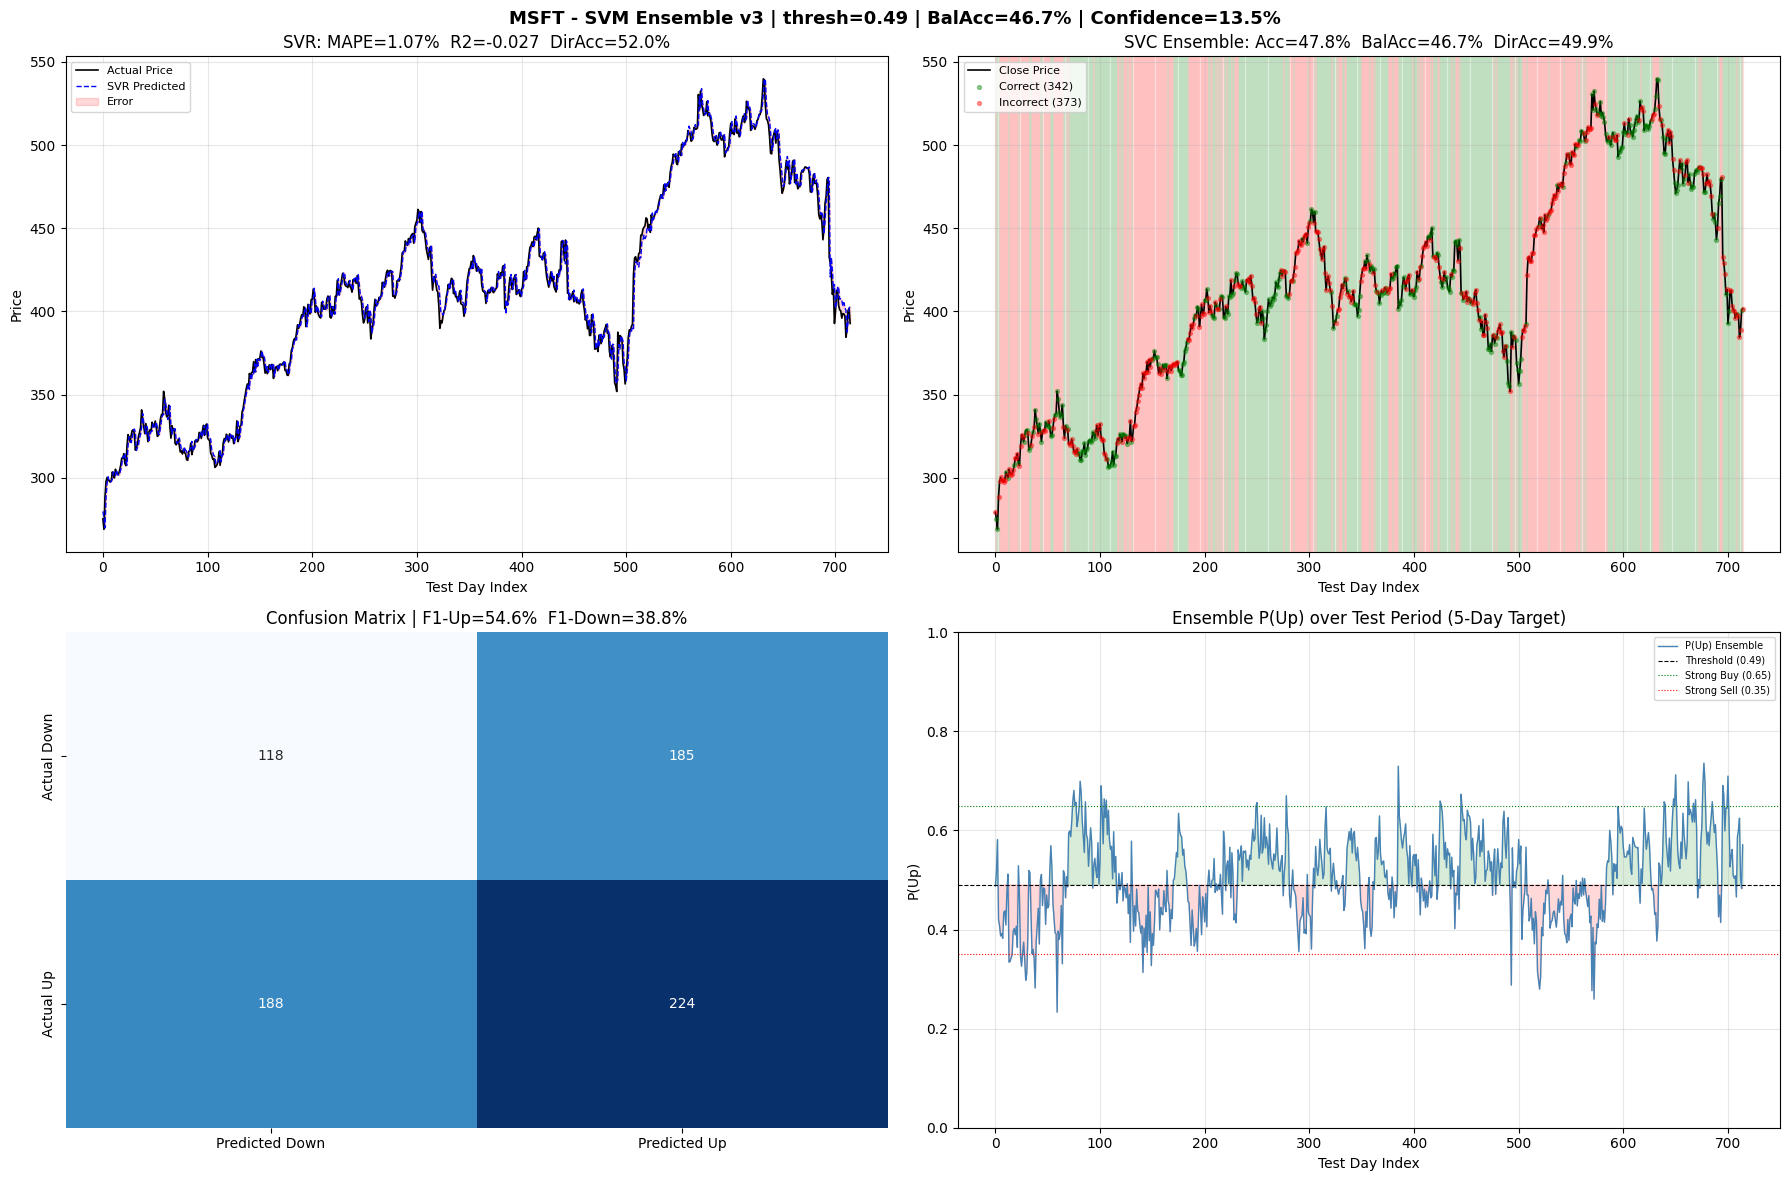


────────────────────────────────────────────────────────────
  SIGNAL BREAKDOWN
────────────────────────────────────────────────────────────
  [ BULLISH ]  5-Day Prediction              Ensemble SVC predicts UP over 5 days (prob=0.571, thresh=0.49)
  [ NEUTRAL ]  Prediction Conviction         Low conviction (0.571) - near boundary
  [ BULLISH ]  Recent Signal Trend           UP 4/5 recent periods
  [ BEARISH ]  Balanced Accuracy             Weak balanced accuracy (46.7%)
  [ BEARISH ]  Directional Accuracy          Below-random directional accuracy (49.9%)
  [ BEARISH ]  F1 Macro                      Weak F1 (46.7%)
  [ NEUTRAL ]  SVR R-Squared                 Near-zero fit (R2=-0.0268)
  [ BULLISH ]  SVR MAPE                      Low price error (MAPE=1.07%)
  [ BULLISH ]  SVR Direction                 SVR predicts UP (401.72 -> 403.04, +0.33%)
  [ NEUTRAL ]  Reg. Dir. Accuracy            Marginal SVR directional acc. (52.0%)
  [ BULLISH ]  Model Agreement               SVC ensemble 

In [21]:
# Support Vector Machine (SVM)
print(f"\n{'='*60}")
print(f"  SUPPORT VECTOR MACHINE ENHANCED v3 - {stock_ticker}")
print(f"{'='*60}\n")

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import TimeSeriesSplit, cross_val_predict, GridSearchCV
from sklearn.metrics import (balanced_accuracy_score, f1_score,
                             accuracy_score, classification_report,
                             confusion_matrix, mean_absolute_error,
                             mean_squared_error, r2_score)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.feature_selection import RFECV
from sklearn.svm import SVC, SVR, LinearSVC
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

FORWARD_DAYS     = 5
TRAIN_RATIO      = 0.80
RANDOM_STATE     = 42
TSCV_SPLITS      = 5
RANDOM_BASELINE  = 0.50
STRONG_THRESHOLD = 0.70

# FEATURE ENGINEERING
history = ticker.history(period="15y").dropna().copy()
df = history.copy()

df['r1']  = df['Close'].pct_change(1)
df['r3']  = df['Close'].pct_change(3)
df['r5']  = df['Close'].pct_change(5)
df['r10'] = df['Close'].pct_change(10)
df['r20'] = df['Close'].pct_change(20)
df['r60'] = df['Close'].pct_change(60)

for span in [5, 10, 20, 50, 100, 200]:
    df[f'sma{span}']    = df['Close'].rolling(span).mean()
    df[f'vs_sma{span}'] = df['Close'] / df[f'sma{span}'] - 1
for span in [9, 12, 21, 26]:
    df[f'ema{span}'] = df['Close'].ewm(span=span, adjust=False).mean()

df['sma5_20']   = df['sma5']  / df['sma20']  - 1
df['sma10_50']  = df['sma10'] / df['sma50']  - 1
df['sma20_50']  = df['sma20'] / df['sma50']  - 1
df['sma50_200'] = df['sma50'] / df['sma200'] - 1
df['ema9_21']   = df['ema9']  / df['ema21']  - 1

df['macd']        = df['ema12'] - df['ema26']
df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()
df['macd_hist']   = df['macd'] - df['macd_signal']
df['macd_n']      = df['macd_hist'] / (df['Close'] + 1e-9)
df['macd_accel']  = df['macd_hist'].diff()

delta = df['Close'].diff()
g14   = delta.clip(lower=0).rolling(14).mean()
l14   = (-delta.clip(upper=0)).rolling(14).mean()
g7    = delta.clip(lower=0).rolling(7).mean()
l7    = (-delta.clip(upper=0)).rolling(7).mean()
df['rsi14']      = 100 - (100 / (1 + g14 / (l14 + 1e-9)))
df['rsi7']       = 100 - (100 / (1 + g7  / (l7  + 1e-9)))
df['rsi_diff']   = df['rsi14'] - df['rsi14'].rolling(5).mean()
df['rsi_accel']  = df['rsi14'].diff()
rsi_min = df['rsi14'].rolling(14).min()
rsi_max = df['rsi14'].rolling(14).max()
df['stochrsi']   = (df['rsi14'] - rsi_min) / (rsi_max - rsi_min + 1e-9)
df['rsi14_norm'] = (df['rsi14'] - 50) / 50

bb_mid         = df['Close'].rolling(20).mean()
bb_std         = df['Close'].rolling(20).std()
bb_upper       = bb_mid + 2 * bb_std
bb_lower       = bb_mid - 2 * bb_std
df['bb_pos']   = (df['Close'] - bb_lower) / (bb_upper - bb_lower + 1e-9)
df['bb_width'] = (bb_upper - bb_lower) / (bb_mid + 1e-9)
df['bb_sqz']   = df['bb_width'] / (df['bb_width'].rolling(50).mean() + 1e-9)
df['bb_pct_b'] = df['bb_pos'] - 0.5

df['prev_close'] = df['Close'].shift(1)
df['tr']         = pd.concat([
    df['High'] - df['Low'],
    (df['High'] - df['prev_close']).abs(),
    (df['Low']  - df['prev_close']).abs()
], axis=1).max(axis=1)
df['atr14']     = df['tr'].rolling(14).mean()
df['atr_n']     = df['atr14'] / (df['Close'] + 1e-9)
df['atr_ratio'] = df['atr14'] / (df['atr14'].rolling(50).mean() + 1e-9)

df['vol5']  = df['r1'].rolling(5).std()
df['vol10'] = df['r1'].rolling(10).std()
df['vol20'] = df['r1'].rolling(20).std()
df['vol60'] = df['r1'].rolling(60).std()
df['vol_ratio_5_20']  = df['vol5']  / (df['vol20'] + 1e-9)
df['vol_ratio_10_60'] = df['vol10'] / (df['vol60'] + 1e-9)
df['vol_trend']       = df['vol5']  / (df['vol5'].rolling(10).mean() + 1e-9)

h14p  = df['High'].rolling(14).max()
l14p  = df['Low'].rolling(14).min()
df['williams_r'] = (h14p - df['Close']) / (h14p - l14p + 1e-9) * -100

tp             = (df['High'] + df['Low'] + df['Close']) / 3
tp_ma          = tp.rolling(20).mean()
tp_mad         = tp.rolling(20).apply(lambda x: np.abs(x - x.mean()).mean())
df['cci']      = (tp - tp_ma) / (0.015 * tp_mad + 1e-9)
df['cci_norm'] = df['cci'] / 200

obv           = (np.sign(df['r1']) * df['Volume']).cumsum()
df['obv_roc'] = obv.pct_change(10)

df['vol_sma20']  = df['Volume'].rolling(20).mean()
df['vol_r20']    = df['Volume'] / (df['vol_sma20'] + 1e-9)
df['vol_r5']     = df['Volume'] / (df['Volume'].rolling(5).mean() + 1e-9)
df['vol_chg']    = df['Volume'].pct_change()
df['vol_trend2'] = df['vol_r20'] / (df['vol_r20'].rolling(10).mean() + 1e-9)

df['hl_range']  = (df['High'] - df['Low'])  / (df['Close'] + 1e-9)
df['close_pos'] = (df['Close'] - df['Low']) / (df['High'] - df['Low'] + 1e-9)
df['range10d']  = (df['High'].rolling(10).max() - df['Low'].rolling(10).min()) / (df['Close'] + 1e-9)
df['gap']       = (df['Open'] - df['prev_close']) / (df['prev_close'] + 1e-9)

for lag in [1, 2, 3, 4, 5, 7, 10, 15, 20, 30]:
    df[f'lag_r{lag}'] = df['r1'].shift(lag)
for lag in [1, 2, 3, 5]:
    df[f'lag_vr{lag}'] = df['vol_r20'].shift(lag)

df['rsi_bb']    = df['rsi14_norm'] * df['bb_pct_b']
df['macd_rsi']  = df['macd_n']     * df['rsi14_norm']
df['vol_atr']   = df['vol_ratio_5_20'] * df['atr_ratio']
df['mom_vol']   = df['r5'] * (1 / (df['vol20'] + 1e-9))
df['trend_str'] = df['sma50_200'] * df['vs_sma50']
df['regime']    = (df['Close'] > df['sma200']).astype(float)

df['target_reg'] = df['r1'].shift(-1)
df['target_clf'] = (df['Close'].shift(-FORWARD_DAYS) > df['Close']).astype(int)

FEATURES = [
    'r1','r3','r5','r10','r20','r60',
    'vs_sma5','vs_sma10','vs_sma20','vs_sma50','vs_sma100','vs_sma200',
    'sma5_20','sma10_50','sma20_50','sma50_200','ema9_21',
    'macd_n','macd_accel',
    'rsi14_norm','rsi7','rsi_diff','rsi_accel','stochrsi',
    'bb_pos','bb_width','bb_sqz','bb_pct_b',
    'atr_n','atr_ratio',
    'vol5','vol10','vol20','vol60',
    'vol_ratio_5_20','vol_ratio_10_60','vol_trend',
    'williams_r','cci_norm',
    'obv_roc','vol_r20','vol_r5','vol_chg',
    'lag_vr1','lag_vr2','lag_vr3','lag_vr5',
    'hl_range','close_pos','range10d','gap',
    'lag_r1','lag_r2','lag_r3','lag_r4','lag_r5',
    'lag_r7','lag_r10','lag_r15','lag_r20','lag_r30',
    'rsi_bb','macd_rsi','vol_atr','mom_vol','trend_str',
    'regime',
]

df_svm = df[FEATURES + ['Close','target_clf','target_reg']].dropna().copy()

print(f"  Prediction target     : {FORWARD_DAYS}-day direction (classifier)")
print(f"  Regression target     : next-day return (scale-free)")
print(f"  Total samples         : {len(df_svm)}")
print(f"  Feature count         : {len(FEATURES)}")
print(f"  Class balance         : Down={int((df_svm['target_clf']==0).sum())}  Up={int((df_svm['target_clf']==1).sum())}")

# TRAIN / TEST SPLIT
split_idx   = int(len(df_svm) * TRAIN_RATIO)
train_df    = df_svm.iloc[:split_idx].copy()
test_df     = df_svm.iloc[split_idx:].copy()

X_train_raw = train_df[FEATURES].values
X_test_raw  = test_df[FEATURES].values
y_train_reg = train_df['target_reg'].values
y_test_reg  = test_df['target_reg'].values
y_train_clf = train_df['target_clf'].values
y_test_clf  = test_df['target_clf'].values

# SCALE
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)

# SMOTE
counts = np.bincount(y_train_clf)
k_nn   = min(5, counts.min() - 1)
if k_nn >= 1:
    smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=k_nn)
    X_bal, y_bal = smote.fit_resample(X_train_scaled, y_train_clf)
    print(f"  After SMOTE           : Down={int(np.sum(y_bal==0))}  Up={int(np.sum(y_bal==1))}")
else:
    X_bal, y_bal = X_train_scaled, y_train_clf
    print(f"  SMOTE skipped")

# FEATURE SELECTION
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression

print(f"\n  Running feature selection (mutual information) ...")
tscv = TimeSeriesSplit(n_splits=TSCV_SPLITS)

mi_scores     = mutual_info_classif(X_bal, y_bal, random_state=RANDOM_STATE, n_neighbors=7)
mi_threshold  = np.percentile(mi_scores, 50)
selected_mask = mi_scores >= mi_threshold

if selected_mask.sum() < 25:
    top25 = np.argsort(mi_scores)[::-1][:25]
    selected_mask[top25] = True

selected_features = [f for f, m in zip(FEATURES, selected_mask) if m]
X_train_sel     = X_bal[:, selected_mask]
X_train_reg_sel = X_train_scaled[:, selected_mask]
X_test_sel      = X_test_scaled[:, selected_mask]
X_orig_sel      = X_train_scaled[:, selected_mask]

print(f"  Features after selection : {len(selected_features)} / {len(FEATURES)}")

# HYPERPARAMETER TUNING
param_grid_rbf = {
    'C':     [0.1, 1, 5, 10, 50, 100],
    'gamma': ['scale', 'auto', 0.1, 0.01, 0.001],
}
param_grid_reg = {
    'C':       [1, 10, 50, 100],
    'gamma':   ['scale', 0.01, 0.001],
    'epsilon': [0.0005, 0.001, 0.005, 0.01],
}

print(f"\n  Tuning SVR ...")
gs_reg = GridSearchCV(
    SVR(kernel='rbf', max_iter=30000),
    param_grid_reg, cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1, verbose=0
)
gs_reg.fit(X_train_reg_sel, y_train_reg)

print(f"  Tuning SVC (RBF) ...")
gs_rbf = GridSearchCV(
    SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE,
        class_weight='balanced', max_iter=30000),
    param_grid_rbf, cv=tscv,
    scoring='balanced_accuracy',
    n_jobs=-1, verbose=0
)
gs_rbf.fit(X_train_sel, y_bal)

best_reg = gs_reg.best_estimator_
best_C   = gs_rbf.best_params_['C']
best_gam = gs_rbf.best_params_['gamma']
print(f"  Best SVR params       : {gs_reg.best_params_}")
print(f"  Best SVC-RBF params   : {gs_rbf.best_params_}")

# WALK-FORWARD OOF + REGIME-AWARE STACKING
print(f"\n  Building walk-forward stacked ensemble ...")

base_params = [
    (best_C,                                        best_gam,  42),
    (max(0.1, best_C / 5),                          best_gam,   7),
    (min(best_C * 5, 500),                          best_gam,  13),
    (best_C,                                        'auto',    17),
    (max(0.1, best_C / 10),                         'scale',   99),
]

def make_rbf(C, gamma, seed):
    return SVC(kernel='rbf', C=C, gamma=gamma, probability=True,
               class_weight='balanced', random_state=seed, max_iter=30000)

n_base    = len(base_params)
n_train   = len(y_train_clf)
oof_probs = np.full((n_train, n_base), np.nan)

for b_idx, (C_b, gam_b, seed_b) in enumerate(base_params):
    for tr_idx, val_idx in tscv.split(X_orig_sel):
        X_f_tr = X_orig_sel[tr_idx]; y_f_tr = y_train_clf[tr_idx]
        X_f_val = X_orig_sel[val_idx]
        f_counts = np.bincount(y_f_tr)
        f_knn    = min(5, f_counts.min() - 1)
        if f_knn >= 1:
            fs = SMOTE(random_state=seed_b, k_neighbors=f_knn)
            X_f_bal, y_f_bal = fs.fit_resample(X_f_tr, y_f_tr)
        else:
            X_f_bal, y_f_bal = X_f_tr, y_f_tr
        m = make_rbf(C_b, gam_b, seed_b)
        m.fit(X_f_bal, y_f_bal)
        oof_probs[val_idx, b_idx] = m.predict_proba(X_f_val)[:, 1]

# Valid rows
oof_valid = ~np.any(np.isnan(oof_probs), axis=1)

# Meta-features
oof_mean  = np.nanmean(oof_probs, axis=1, keepdims=True)
oof_std   = np.nanstd(oof_probs, axis=1, keepdims=True)
meta_X_tr_full = np.hstack([oof_probs, oof_mean, oof_std, X_orig_sel])
meta_X_tr = meta_X_tr_full[oof_valid]
meta_y_tr = y_train_clf[oof_valid]

# Train base models on full balanced data
base_models = []
for C_b, gam_b, seed_b in base_params:
    m = make_rbf(C_b, gam_b, seed_b)
    m.fit(X_train_sel, y_bal)
    base_models.append(m)

# Test meta-features
test_base_probs = np.column_stack([m.predict_proba(X_test_sel)[:, 1] for m in base_models])
test_bp_mean    = test_base_probs.mean(axis=1, keepdims=True)
test_bp_std     = test_base_probs.std(axis=1, keepdims=True)
meta_X_test     = np.hstack([test_base_probs, test_bp_mean, test_bp_std, X_test_sel])
meta_lr = LogisticRegression(C=0.1, class_weight='balanced',
                              random_state=RANDOM_STATE, max_iter=2000,
                              solver='lbfgs')
meta_lr.fit(meta_X_tr, meta_y_tr)
y_prob_clf = meta_lr.predict_proba(meta_X_test)[:, 1]

# THRESHOLD SEARCH ON OOF PROBABILITIES
meta_oof_probs = meta_lr.predict_proba(meta_X_tr)[:, 1]
best_thresh, best_f1 = 0.50, 0.0
for t in np.arange(0.30, 0.71, 0.01):
    preds = (meta_oof_probs >= t).astype(int)
    if len(np.unique(preds)) < 2:
        continue
    score = f1_score(meta_y_tr, preds, average='macro', zero_division=0)
    if score > best_f1:
        best_f1     = score
        best_thresh = round(t, 2)

print(f"  Optimal threshold     : {best_thresh}  (OOF macro-F1={best_f1:.4f})")

for try_thresh in [best_thresh, 0.50, 0.45, 0.40]:
    y_pred_clf = (y_prob_clf >= try_thresh).astype(int)
    if len(np.unique(y_pred_clf)) > 1:
        best_thresh = try_thresh
        break

y_pred_reg_pct = best_reg.predict(X_test_sel)

# EVALUATION
test_close_arr   = test_df['Close'].values
y_pred_reg_price = test_close_arr * (1 + y_pred_reg_pct)
y_test_reg_price = test_close_arr * (1 + y_test_reg)

mae_price  = mean_absolute_error(y_test_reg_price, y_pred_reg_price)
rmse_price = np.sqrt(mean_squared_error(y_test_reg_price, y_pred_reg_price))
mape_price = np.mean(np.abs((y_test_reg_price - y_pred_reg_price) / (y_test_reg_price + 1e-9))) * 100
r2         = r2_score(y_test_reg, y_pred_reg_pct)
reg_dir_acc= np.mean(np.sign(y_test_reg) == np.sign(y_pred_reg_pct)) * 100

acc      = accuracy_score(y_test_clf, y_pred_clf)
bal_acc  = balanced_accuracy_score(y_test_clf, y_pred_clf)
report   = classification_report(y_test_clf, y_pred_clf,
                                  target_names=['Down','Up'],
                                  output_dict=True, zero_division=0)
cm       = confusion_matrix(y_test_clf, y_pred_clf)

tn = int(cm[0,0]) if cm.shape==(2,2) else 0
fp = int(cm[0,1]) if cm.shape==(2,2) else 0
fn = int(cm[1,0]) if cm.shape==(2,2) else 0
tp = int(cm[1,1]) if cm.shape==(2,2) else 0

precision_up = report['Up']['precision']
recall_up    = report['Up']['recall']
f1_up        = report['Up']['f1-score']
precision_dn = report['Down']['precision']
recall_dn    = report['Down']['recall']
f1_dn        = report['Down']['f1-score']
f1_macro     = (f1_up + f1_dn) / 2

actual_dir      = np.sign(np.diff(test_close_arr))
pred_dir        = np.where(y_pred_clf[:-1] == 1, 1, -1)
directional_acc = np.mean(actual_dir == pred_dir) * 100

last_prob         = float(y_prob_clf[-1])
last_pred         = int(y_pred_clf[-1])
predicted_classes = len(np.unique(y_pred_clf))
last_reg_pct      = float(y_pred_reg_pct[-1])
last_close        = float(test_close_arr[-1])
reg_pred_price    = last_close * (1 + last_reg_pct)

print(f"\n  {'Metric':<40} {'Value':>12}")
print(f"  {'─'*54}")
print(f"  {'--- SVR (Regression) ---'}")
print(f"  {'MAE (price)':<40} {mae_price:>12.4f}")
print(f"  {'RMSE (price)':<40} {rmse_price:>12.4f}")
print(f"  {'MAPE (price %)':<40} {mape_price:>11.2f}%")
print(f"  {'R-Squared (return)':<40} {r2:>12.4f}")
print(f"  {'Reg. Directional Acc.':<40} {reg_dir_acc:>11.2f}%")
print(f"  {'--- SVC Ensemble (Classifier) ---'}")
print(f"  {'Decision Threshold':<40} {best_thresh:>12.2f}")
print(f"  {'Overall Accuracy':<40} {acc*100:>11.2f}%")
print(f"  {'Balanced Accuracy':<40} {bal_acc*100:>11.2f}%")
print(f"  {'Directional Accuracy':<40} {directional_acc:>11.2f}%")
print(f"  {'F1 Macro':<40} {f1_macro*100:>11.2f}%")
print(f"  {'Precision (Up)':<40} {precision_up*100:>11.2f}%")
print(f"  {'Recall    (Up)':<40} {recall_up*100:>11.2f}%")
print(f"  {'F1 Score  (Up)':<40} {f1_up*100:>11.2f}%")
print(f"  {'Precision (Down)':<40} {precision_dn*100:>11.2f}%")
print(f"  {'Recall    (Down)':<40} {recall_dn*100:>11.2f}%")
print(f"  {'F1 Score  (Down)':<40} {f1_dn*100:>11.2f}%")
print(f"  {'TP | TN | FP | FN':<40} {tp} | {tn} | {fp} | {fn}")
print(f"  {'Features selected':<40} {len(selected_features)} / {len(FEATURES)}")

# CONFIDENCE SCORE
collapse_penalty = 1.0 if predicted_classes > 1 else 0.05

def clamp(val, lo=0.0, hi=1.0):
    return max(lo, min(hi, val))

acc_component  = clamp((bal_acc         - RANDOM_BASELINE) / (STRONG_THRESHOLD - RANDOM_BASELINE))
f1_component   = clamp(f1_macro)
dir_component  = clamp((directional_acc / 100 - RANDOM_BASELINE) / (STRONG_THRESHOLD - RANDOM_BASELINE))
reg_dir_comp   = clamp((reg_dir_acc     / 100 - RANDOM_BASELINE) / (STRONG_THRESHOLD - RANDOM_BASELINE))
prob_component = abs(last_prob - 0.5) * 2

confidence = round(
    collapse_penalty * (
        0.40 * acc_component  +
        0.25 * f1_component   +
        0.20 * dir_component  +
        0.08 * reg_dir_comp   +
        0.07 * prob_component
    ) * 100,
    1
)

# SIGNAL SCORING
svm_signals = []

def add_svm_signal(label, score, weight, comment):
    svm_signals.append((label, score, weight, comment))

if predicted_classes == 1:
    add_svm_signal("Model Health", -2, 3, "CRITICAL: classifier predicted only one class")

if last_pred == 1:
    add_svm_signal(f"{FORWARD_DAYS}-Day Prediction", +1, 3,
                   f"Ensemble SVC predicts UP over {FORWARD_DAYS} days (prob={last_prob:.3f}, thresh={best_thresh})")
else:
    add_svm_signal(f"{FORWARD_DAYS}-Day Prediction", -1, 3,
                   f"Ensemble SVC predicts DOWN over {FORWARD_DAYS} days (prob={last_prob:.3f}, thresh={best_thresh})")

if last_prob > 0.65:
    add_svm_signal("Prediction Conviction", +1, 2, f"High UP conviction ({last_prob:.3f})")
elif last_prob < 0.35:
    add_svm_signal("Prediction Conviction", -1, 2, f"High DOWN conviction ({last_prob:.3f})")
else:
    add_svm_signal("Prediction Conviction",  0, 2, f"Low conviction ({last_prob:.3f}) - near boundary")

recent_preds = y_pred_clf[-5:]
up5 = int(np.sum(recent_preds == 1))
dn5 = 5 - up5
if up5 >= 4:
    add_svm_signal("Recent Signal Trend", +1, 2, f"UP {up5}/5 recent periods")
elif dn5 >= 4:
    add_svm_signal("Recent Signal Trend", -1, 2, f"DOWN {dn5}/5 recent periods")
else:
    add_svm_signal("Recent Signal Trend",  0, 2, f"Mixed ({up5} up / {dn5} down)")

if bal_acc > STRONG_THRESHOLD:
    add_svm_signal("Balanced Accuracy", +1, 3, f"Strong balanced accuracy ({bal_acc*100:.1f}%)")
elif bal_acc > 0.57:
    add_svm_signal("Balanced Accuracy",  0, 3, f"Moderate balanced accuracy ({bal_acc*100:.1f}%)")
else:
    add_svm_signal("Balanced Accuracy", -1, 3, f"Weak balanced accuracy ({bal_acc*100:.1f}%)")

if directional_acc > 58:
    add_svm_signal("Directional Accuracy", +1, 2, f"Reliable direction calls ({directional_acc:.1f}%)")
elif directional_acc > 52:
    add_svm_signal("Directional Accuracy",  0, 2, f"Marginal directional accuracy ({directional_acc:.1f}%)")
else:
    add_svm_signal("Directional Accuracy", -1, 2, f"Below-random directional accuracy ({directional_acc:.1f}%)")

if f1_macro > 0.60:
    add_svm_signal("F1 Macro", +1, 2, f"Strong balanced F1 ({f1_macro*100:.1f}%)")
elif f1_macro > 0.50:
    add_svm_signal("F1 Macro",  0, 2, f"Acceptable F1 ({f1_macro*100:.1f}%)")
else:
    add_svm_signal("F1 Macro", -1, 2, f"Weak F1 ({f1_macro*100:.1f}%)")

if r2 > 0.10:
    add_svm_signal("SVR R-Squared", +1, 1, f"Positive regression fit (R2={r2:.4f})")
elif r2 > -0.05:
    add_svm_signal("SVR R-Squared",  0, 1, f"Near-zero fit (R2={r2:.4f})")
else:
    add_svm_signal("SVR R-Squared", -1, 1, f"Negative fit (R2={r2:.4f})")

if mape_price < 2:
    add_svm_signal("SVR MAPE", +1, 1, f"Low price error (MAPE={mape_price:.2f}%)")
elif mape_price < 6:
    add_svm_signal("SVR MAPE",  0, 1, f"Moderate price error (MAPE={mape_price:.2f}%)")
else:
    add_svm_signal("SVR MAPE", -1, 1, f"High price error (MAPE={mape_price:.2f}%)")

if last_reg_pct > 0:
    add_svm_signal("SVR Direction", +1, 2,
                   f"SVR predicts UP ({last_close:.2f} -> {reg_pred_price:.2f}, {last_reg_pct*100:+.2f}%)")
else:
    add_svm_signal("SVR Direction", -1, 2,
                   f"SVR predicts DOWN ({last_close:.2f} -> {reg_pred_price:.2f}, {last_reg_pct*100:+.2f}%)")

if reg_dir_acc > 58:
    add_svm_signal("Reg. Dir. Accuracy", +1, 2, f"SVR direction reliable ({reg_dir_acc:.1f}%)")
elif reg_dir_acc > 52:
    add_svm_signal("Reg. Dir. Accuracy",  0, 2, f"Marginal SVR directional acc. ({reg_dir_acc:.1f}%)")
else:
    add_svm_signal("Reg. Dir. Accuracy", -1, 2, f"Below-random SVR direction ({reg_dir_acc:.1f}%)")

if (last_pred == 1) == (last_reg_pct > 0):
    add_svm_signal("Model Agreement", +1, 2, "SVC ensemble and SVR agree on direction")
else:
    add_svm_signal("Model Agreement", -1, 2, "SVC ensemble and SVR disagree - conflicting signal")

weighted_score = sum(s * w for _, s, w, _ in svm_signals)
max_possible   = sum(abs(s) * w for _, s, w, _ in svm_signals) or 1
norm_score     = weighted_score / max_possible

n_bullish = sum(1 for _, s, _, _ in svm_signals if s > 0)
n_bearish = sum(1 for _, s, _, _ in svm_signals if s < 0)
n_total   = len(svm_signals)

if   norm_score >= 0.50:  decision = "STRONG BUY"
elif norm_score >= 0.20:  decision = "BUY"
elif norm_score >= 0.05:  decision = "WEAK BUY"
elif norm_score > -0.05:  decision = "HOLD"
elif norm_score > -0.20:  decision = "WEAK SELL"
elif norm_score > -0.50:  decision = "SELL"
else:                     decision = "STRONG SELL"

if predicted_classes == 1:
    decision   = "HOLD (MODEL UNRELIABLE)"
    confidence = min(confidence, 10.0)

# PLOTS
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle(
    f"{stock_ticker} - SVM Ensemble v3 | thresh={best_thresh} | "
    f"BalAcc={bal_acc*100:.1f}% | Confidence={confidence}%",
    fontsize=13, fontweight='bold'
)

ax1 = axes[0, 0]
idx = np.arange(len(y_test_reg_price))
ax1.plot(idx, y_test_reg_price, label='Actual Price',  color='black', linewidth=1.2)
ax1.plot(idx, y_pred_reg_price, label='SVR Predicted', color='blue',  linewidth=1, linestyle='dashed')
ax1.fill_between(idx, y_test_reg_price, y_pred_reg_price, alpha=0.15, color='red', label='Error')
ax1.set_title(f"SVR: MAPE={mape_price:.2f}%  R2={r2:.3f}  DirAcc={reg_dir_acc:.1f}%")
ax1.set_xlabel("Test Day Index")
ax1.set_ylabel("Price")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

ax2 = axes[0, 1]
ax2.plot(np.arange(len(test_close_arr)), test_close_arr,
         color='black', linewidth=1.2, label='Close Price', zorder=3)
for i in range(len(y_pred_clf) - 1):
    ax2.axvspan(i, i + 1, alpha=0.08, color='green' if y_pred_clf[i] == 1 else 'red')
correct_idx   = np.where(y_pred_clf == y_test_clf)[0]
incorrect_idx = np.where(y_pred_clf != y_test_clf)[0]
if len(correct_idx) > 0:
    ax2.scatter(correct_idx,   test_close_arr[correct_idx],   color='green', s=8, alpha=0.4, zorder=4, label=f'Correct ({len(correct_idx)})')
if len(incorrect_idx) > 0:
    ax2.scatter(incorrect_idx, test_close_arr[incorrect_idx], color='red',   s=8, alpha=0.4, zorder=4, label=f'Incorrect ({len(incorrect_idx)})')
ax2.set_title(f"SVC Ensemble: Acc={acc*100:.1f}%  BalAcc={bal_acc*100:.1f}%  DirAcc={directional_acc:.1f}%")
ax2.set_xlabel("Test Day Index")
ax2.set_ylabel("Price")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

ax3 = axes[1, 0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Down', 'Predicted Up'],
            yticklabels=['Actual Down',    'Actual Up'], ax=ax3)
ax3.set_title(f"Confusion Matrix | F1-Up={f1_up*100:.1f}%  F1-Down={f1_dn*100:.1f}%")

ax4 = axes[1, 1]
ax4.plot(y_prob_clf, color='steelblue', linewidth=1, label='P(Up) Ensemble')
ax4.axhline(best_thresh, color='black', linestyle='--', linewidth=0.8, label=f'Threshold ({best_thresh})')
ax4.axhline(0.65, color='green', linestyle=':', linewidth=0.8, label='Strong Buy (0.65)')
ax4.axhline(0.35, color='red',   linestyle=':', linewidth=0.8, label='Strong Sell (0.35)')
ax4.fill_between(range(len(y_prob_clf)), y_prob_clf, best_thresh,
                 where=(np.array(y_prob_clf) >= best_thresh), alpha=0.15, color='green')
ax4.fill_between(range(len(y_prob_clf)), y_prob_clf, best_thresh,
                 where=(np.array(y_prob_clf) <  best_thresh), alpha=0.15, color='red')
ax4.set_ylim(0, 1)
ax4.set_title(f"Ensemble P(Up) over Test Period ({FORWARD_DAYS}-Day Target)")
ax4.set_xlabel("Test Day Index")
ax4.set_ylabel("P(Up)")
ax4.legend(fontsize=7)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# PRINT REPORT
print(f"\n{'─'*60}")
print(f"  SIGNAL BREAKDOWN")
print(f"{'─'*60}")
for label, score, weight, comment in svm_signals:
    tag = "[ BULLISH ]" if score > 0 else ("[ BEARISH ]" if score < 0 else "[ NEUTRAL ]")
    print(f"  {tag}  {label:<28}  {comment}")

print(f"\n{'─'*60}")
print(f"  SCORING SUMMARY")
print(f"{'─'*60}")
print(f"  Bullish signals   : {n_bullish} / {n_total}")
print(f"  Bearish signals   : {n_bearish} / {n_total}")
print(f"  Weighted score    : {weighted_score:+.1f}  (normalised: {norm_score:+.3f})")
print(f"\n  Confidence Level  : {confidence}%")
print(f"  Recommendation    : {decision}")
print(f"{'='*60}\n")

svm_model            = decision
svm_model_confidence = confidence

# XGBoost & LightGBM

In [ ]:
# XGBoost & LightGBM

print(f"\n{'='*60}")
print(f"  XGBOOST & LIGHTGBM - {stock_ticker}")
print(f"{'='*60}\n")

from sklearn.model_selection import TimeSeriesSplit

# Feature Engineering
history = ticker.history(period="10y").dropna().copy()

history['Daily_Return']  = history['Close'].pct_change()
history['Return_5d']     = history['Close'].pct_change(5)
history['Return_10d']    = history['Close'].pct_change(10)
history['Return_20d']    = history['Close'].pct_change(20)

history['SMA_10']        = history['Close'].rolling(10).mean()
history['SMA_20']        = history['Close'].rolling(20).mean()
history['SMA_50']        = history['Close'].rolling(50).mean()
history['SMA_200']       = history['Close'].rolling(200).mean()
history['EMA_12']        = history['Close'].ewm(span=12, adjust=False).mean()
history['EMA_26']        = history['Close'].ewm(span=26, adjust=False).mean()
history['MACD']          = history['EMA_12'] - history['EMA_26']
history['MACD_Signal']   = history['MACD'].ewm(span=9, adjust=False).mean()
history['MACD_Diff']     = history['MACD'] - history['MACD_Signal']

history['Volatility_10'] = history['Daily_Return'].rolling(10).std()
history['Volatility_20'] = history['Daily_Return'].rolling(20).std()
history['Vol_Ratio']     = history['Volatility_10'] / (history['Volatility_20'] + 1e-9)

# RSI
delta               = history['Close'].diff()
gain                = delta.clip(lower=0).rolling(14).mean()
loss                = (-delta.clip(upper=0)).rolling(14).mean()
history['RSI']      = 100 - (100 / (1 + gain / loss))
history['RSI_SMA']  = history['RSI'].rolling(5).mean()
history['RSI_Diff'] = history['RSI'] - history['RSI_SMA']

# Bollinger Bands
bb_mid               = history['Close'].rolling(20).mean()
bb_std               = history['Close'].rolling(20).std()
bb_upper             = bb_mid + 2 * bb_std
bb_lower             = bb_mid - 2 * bb_std
history['BB_Pos']    = (history['Close'] - bb_lower) / (bb_upper - bb_lower + 1e-9)
history['BB_Width']  = (bb_upper - bb_lower) / (bb_mid + 1e-9)

# Price vs moving averages
history['Vs_SMA10']  = (history['Close'] - history['SMA_10'])  / history['SMA_10']
history['Vs_SMA50']  = (history['Close'] - history['SMA_50'])  / history['SMA_50']
history['Vs_SMA200'] = (history['Close'] - history['SMA_200']) / history['SMA_200']

# Volume features
history['Vol_Change']   = history['Volume'].pct_change()
history['Vol_SMA20']    = history['Volume'].rolling(20).mean()
history['Vol_Ratio_20'] = history['Volume'] / (history['Vol_SMA20'] + 1e-9)

# ATR
history['Prev_Close'] = history['Close'].shift(1)
history['TR']  = pd.concat([
    history['High'] - history['Low'],
    (history['High'] - history['Prev_Close']).abs(),
    (history['Low']  - history['Prev_Close']).abs()
], axis=1).max(axis=1)
history['ATR'] = history['TR'].rolling(14).mean()

# Lagged returns
for lag in [1, 2, 3, 5, 10]:
    history[f'Lag_{lag}'] = history['Daily_Return'].shift(lag)

FORWARD_DAYS = 5

# Regression target: forward close price
history['Target_reg'] = history['Close'].shift(-FORWARD_DAYS)

# Classification target: direction over forward window
history['Target_clf'] = (history['Close'].shift(-FORWARD_DAYS) > history['Close']).astype(int)

features = [
    'Daily_Return', 'Return_5d', 'Return_10d', 'Return_20d',
    'SMA_10', 'SMA_20', 'SMA_50', 'SMA_200',
    'MACD_Diff', 'RSI', 'RSI_Diff',
    'BB_Pos', 'BB_Width',
    'Volatility_10', 'Volatility_20', 'Vol_Ratio',
    'Vs_SMA10', 'Vs_SMA50', 'Vs_SMA200',
    'Vol_Change', 'Vol_Ratio_20', 'ATR',
    'Lag_1', 'Lag_2', 'Lag_3', 'Lag_5', 'Lag_10'
]

# Sanitise column names for XGBoost
safe_features = [re.sub(r'[^a-zA-Z0-9_]', '_', f) for f in features]
history_clean = history.copy()
history_clean.columns = [re.sub(r'[^a-zA-Z0-9_]', '_', c) for c in history_clean.columns]

df_xgb = history_clean[safe_features + ['Close', 'Target_reg', 'Target_clf']].dropna().copy()

print(f"  Prediction target     : {FORWARD_DAYS}-day forward direction (classifier)")
print(f"  Regression target     : {FORWARD_DAYS}-day forward close price")
print(f"  Total samples         : {len(df_xgb)}")
print(f"  Class balance         : Down={int((df_xgb['Target_clf']==0).sum())}  Up={int((df_xgb['Target_clf']==1).sum())}")

# Chronological Train / Test Split
split_idx = int(len(df_xgb) * 0.80)
train_df  = df_xgb.iloc[:split_idx].copy()
test_df   = df_xgb.iloc[split_idx:].copy()

X_train = train_df[safe_features]
X_test  = test_df[safe_features]

y_train_reg = train_df['Target_reg'].values
y_test_reg  = test_df['Target_reg'].values
y_train_clf = train_df['Target_clf'].values
y_test_clf  = test_df['Target_clf'].values

# Scale — fit on training set only
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Convert back to DataFrame to preserve feature names
X_train_s = pd.DataFrame(X_train_scaled, columns=safe_features)
X_test_s  = pd.DataFrame(X_test_scaled,  columns=safe_features)

# SMOTE on classifier training set only
class_counts = np.bincount(y_train_clf)
k_neighbors  = min(5, class_counts.min() - 1)

if k_neighbors >= 1:
    smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
    X_train_clf_bal, y_train_clf_bal = smote.fit_resample(X_train_s, y_train_clf)
    X_train_clf_bal = pd.DataFrame(X_train_clf_bal, columns=safe_features)
    print(f"  After SMOTE (clf)     : Down={int(np.sum(y_train_clf_bal==0))}  Up={int(np.sum(y_train_clf_bal==1))}")
else:
    X_train_clf_bal, y_train_clf_bal = X_train_s, y_train_clf
    print(f"  SMOTE skipped - insufficient minority samples")

# Hyperparameter Tuning via TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

param_grid_xgb = {
    'n_estimators':     [100, 200],
    'max_depth':        [3, 5, 7],
    'learning_rate':    [0.01, 0.05, 0.1],
    'subsample':        [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

param_grid_lgb = {
    'n_estimators':  [100, 200],
    'max_depth':     [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves':    [31, 63],
    'subsample':     [0.8, 1.0]
}

print(f"\n  Tuning XGBoost regressor ...")
gs_xgb_reg = GridSearchCV(
    xgb.XGBRegressor(objective='reg:squarederror', random_state=42, verbosity=0),
    param_grid_xgb, cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1, verbose=0
)
gs_xgb_reg.fit(X_train_s, y_train_reg)

print(f"  Tuning XGBoost classifier ...")
gs_xgb_clf = GridSearchCV(
    xgb.XGBClassifier(objective='binary:logistic', random_state=42,
                       eval_metric='logloss', verbosity=0),
    param_grid_xgb, cv=tscv,
    scoring='f1', n_jobs=-1, verbose=0
)
gs_xgb_clf.fit(X_train_clf_bal, y_train_clf_bal)

print(f"  Tuning LightGBM regressor ...")
gs_lgb_reg = GridSearchCV(
    lgb.LGBMRegressor(random_state=42, verbose=-1),
    param_grid_lgb, cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1, verbose=0
)
gs_lgb_reg.fit(X_train_s, y_train_reg)

print(f"  Tuning LightGBM classifier ...")
gs_lgb_clf = GridSearchCV(
    lgb.LGBMClassifier(random_state=42, class_weight='balanced', verbose=-1),
    param_grid_lgb, cv=tscv,
    scoring='f1', n_jobs=-1, verbose=0
)
gs_lgb_clf.fit(X_train_clf_bal, y_train_clf_bal)

xgb_reg  = gs_xgb_reg.best_estimator_
xgb_clf  = gs_xgb_clf.best_estimator_
lgb_reg  = gs_lgb_reg.best_estimator_
lgb_clf  = gs_lgb_clf.best_estimator_

xgb_pred_reg = xgb_reg.predict(X_test_s)
xgb_pred_clf = xgb_clf.predict(X_test_s)
xgb_prob_clf = xgb_clf.predict_proba(X_test_s)[:, 1]

lgb_pred_reg = lgb_reg.predict(X_test_s)
lgb_pred_clf = lgb_clf.predict(X_test_s)
lgb_prob_clf = lgb_clf.predict_proba(X_test_s)[:, 1]

ens_prob_clf  = (xgb_prob_clf + lgb_prob_clf) / 2
ens_pred_clf  = (ens_prob_clf >= 0.5).astype(int)
ens_pred_reg  = (xgb_pred_reg + lgb_pred_reg) / 2

print(f"\n  Best XGBoost Regressor  : {gs_xgb_reg.best_params_}")
print(f"  Best XGBoost Classifier : {gs_xgb_clf.best_params_}")
print(f"  Best LightGBM Regressor : {gs_lgb_reg.best_params_}")
print(f"  Best LightGBM Classifier: {gs_lgb_clf.best_params_}")

# Evaluation
def reg_metrics(y_true, y_pred_vals):
    mae  = mean_absolute_error(y_true, y_pred_vals)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred_vals))
    r2   = r2_score(y_true, y_pred_vals)
    mape = np.mean(np.abs((y_true - y_pred_vals) / (np.abs(y_true) + 1e-9))) * 100
    return mae, rmse, r2, mape

def clf_metrics(y_true, y_pred_vals, y_prob):
    acc    = accuracy_score(y_true, y_pred_vals)
    report = classification_report(y_true, y_pred_vals,
                                   target_names=['Down', 'Up'],
                                   output_dict=True, zero_division=0)
    cm_    = confusion_matrix(y_true, y_pred_vals)
    f1_up  = report['Up']['precision']
    f1_dn  = report['Down']['f1-score']
    f1_up_r= report['Up']['f1-score']
    actual_dir  = np.sign(np.diff(test_df['Close'].values))
    pred_dir    = np.sign(y_pred_vals[1:] * 2 - 1)
    dir_acc     = np.mean(actual_dir == pred_dir) * 100
    return acc, report, cm_, dir_acc

xgb_mae, xgb_rmse, xgb_r2, xgb_mape           = reg_metrics(y_test_reg, xgb_pred_reg)
lgb_mae, lgb_rmse, lgb_r2, lgb_mape           = reg_metrics(y_test_reg, lgb_pred_reg)
ens_mae, ens_rmse, ens_r2, ens_mape           = reg_metrics(y_test_reg, ens_pred_reg)

xgb_acc, xgb_report, xgb_cm, xgb_dir_acc     = clf_metrics(y_test_clf, xgb_pred_clf, xgb_prob_clf)
lgb_acc, lgb_report, lgb_cm, lgb_dir_acc     = clf_metrics(y_test_clf, lgb_pred_clf, lgb_prob_clf)
ens_acc, ens_report, ens_cm, ens_dir_acc     = clf_metrics(y_test_clf, ens_pred_clf, ens_prob_clf)

print(f"\n  {'Metric':<28} {'XGBoost':>10} {'LightGBM':>10} {'Ensemble':>10}")
print(f"  {'─'*60}")
print(f"  {'--- Regression ---':<28}")
print(f"  {'MAE':<28} {xgb_mae:>10.4f} {lgb_mae:>10.4f} {ens_mae:>10.4f}")
print(f"  {'RMSE':<28} {xgb_rmse:>10.4f} {lgb_rmse:>10.4f} {ens_rmse:>10.4f}")
print(f"  {'R-Squared':<28} {xgb_r2:>10.4f} {lgb_r2:>10.4f} {ens_r2:>10.4f}")
print(f"  {'MAPE (%)':<28} {xgb_mape:>9.2f}% {lgb_mape:>9.2f}% {ens_mape:>9.2f}%")
print(f"  {'--- Classifier ---':<28}")
print(f"  {'Accuracy':<28} {xgb_acc*100:>9.2f}% {lgb_acc*100:>9.2f}% {ens_acc*100:>9.2f}%")
print(f"  {'Directional Accuracy':<28} {xgb_dir_acc:>9.2f}% {lgb_dir_acc:>9.2f}% {ens_dir_acc:>9.2f}%")
print(f"  {'F1 (Up)':<28} {xgb_report['Up']['f1-score']:>10.4f} {lgb_report['Up']['f1-score']:>10.4f} {ens_report['Up']['f1-score']:>10.4f}")
print(f"  {'F1 (Down)':<28} {xgb_report['Down']['f1-score']:>10.4f} {lgb_report['Down']['f1-score']:>10.4f} {ens_report['Down']['f1-score']:>10.4f}")

# Feature importances
xgb_feat_imp = pd.Series(xgb_clf.feature_importances_, index=safe_features).sort_values(ascending=False)
lgb_feat_imp = pd.Series(lgb_clf.feature_importances_, index=safe_features).sort_values(ascending=False)

print(f"\n  Top 10 Feature Importances:")
print(f"  {'Feature':<22} {'XGBoost':>10} {'LightGBM':>10}")
print(f"  {'─'*44}")
top_union = list(dict.fromkeys(list(xgb_feat_imp.head(10).index) + list(lgb_feat_imp.head(10).index)))[:10]
for fname in top_union:
    xv = xgb_feat_imp.get(fname, 0)
    lv = lgb_feat_imp.get(fname, 0)
    print(f"  {fname:<22} {xv:>10.4f} {lv:>10.4f}")

# Confidence Score
last_ens_prob     = float(ens_prob_clf[-1])
last_ens_pred     = int(ens_pred_clf[-1])
predicted_classes = len(np.unique(ens_pred_clf))

RANDOM_BASELINE  = 0.50
STRONG_THRESHOLD = 0.68
collapse_penalty = 1.0 if predicted_classes > 1 else 0.15

ens_f1_up = ens_report['Up']['f1-score']
ens_f1_dn = ens_report['Down']['f1-score']

acc_component  = max(0, min(1, (ens_acc  - RANDOM_BASELINE) / (STRONG_THRESHOLD - RANDOM_BASELINE)))
f1_component   = (ens_f1_up + ens_f1_dn) / 2
dir_component  = max(0, min(1, (ens_dir_acc / 100 - RANDOM_BASELINE) / (STRONG_THRESHOLD - RANDOM_BASELINE)))
prob_component = abs(last_ens_prob - 0.5) * 2
r2_component   = max(0, ens_r2)
mape_component = max(0, 1 - ens_mape / 100)

confidence = round(
    collapse_penalty * (
        0.30 * acc_component  +
        0.20 * f1_component   +
        0.15 * dir_component  +
        0.10 * prob_component +
        0.15 * r2_component   +
        0.10 * mape_component
    ) * 100, 1
)

# Signal Scoring
xgb_lgb_signals = []

def add_xgb_signal(label, score, weight, comment):
    xgb_lgb_signals.append((label, score, weight, comment))

if predicted_classes == 1:
    add_xgb_signal("Model Health",              -2, 3, "CRITICAL: Ensemble predicted only one class - results invalid")

# Ensemble direction
if last_ens_pred == 1:
    add_xgb_signal(f"Ensemble {FORWARD_DAYS}-Day Pred", +1, 3, f"Ensemble predicts UP over next {FORWARD_DAYS} days   (prob = {last_ens_prob:.3f})")
else:
    add_xgb_signal(f"Ensemble {FORWARD_DAYS}-Day Pred", -1, 3, f"Ensemble predicts DOWN over next {FORWARD_DAYS} days (prob = {last_ens_prob:.3f})")

# Ensemble conviction
if last_ens_prob > 0.62:
    add_xgb_signal("Ensemble Conviction",        +1, 2, f"Above-threshold UP conviction   ({last_ens_prob:.3f})")
elif last_ens_prob < 0.38:
    add_xgb_signal("Ensemble Conviction",        -1, 2, f"Above-threshold DOWN conviction ({last_ens_prob:.3f})")
else:
    add_xgb_signal("Ensemble Conviction",         0, 2, f"Low conviction ({last_ens_prob:.3f}) - near decision boundary")

# XGBoost and LightGBM agreement
xgb_up = int(xgb_pred_clf[-1]) == 1
lgb_up = int(lgb_pred_clf[-1]) == 1
if xgb_up == lgb_up:
    direction_str = "UP" if xgb_up else "DOWN"
    add_xgb_signal("XGB vs LGB Agreement",       +1, 2, f"Both models agree: {direction_str} - higher conviction")
else:
    add_xgb_signal("XGB vs LGB Agreement",       -1, 2, "Models disagree on direction - conflicting signal")

# Regressor agreement with classifier
ens_reg_up = ens_pred_reg[-1] > test_df['Close'].values[-1]
if (ens_reg_up and last_ens_pred == 1) or (not ens_reg_up and last_ens_pred == 0):
    reg_pred_val = float(ens_pred_reg[-1])
    reg_curr_val = float(test_df['Close'].values[-1])
    reg_chg      = (reg_pred_val - reg_curr_val) / reg_curr_val * 100
    add_xgb_signal("Reg vs Clf Agreement",       +1, 2, f"Regressor and classifier agree on direction ({reg_chg:+.2f}%)")
else:
    add_xgb_signal("Reg vs Clf Agreement",       -1, 2, "Regressor and classifier disagree on direction")

# Recent signal trend
recent_ens = ens_pred_clf[-5:]
up_count   = int(np.sum(recent_ens == 1))
dn_count   = int(np.sum(recent_ens == 0))
if up_count >= 4:
    add_xgb_signal("Recent Signal Trend",        +1, 2, f"Ensemble predicted UP {up_count}/5 recent periods")
elif dn_count >= 4:
    add_xgb_signal("Recent Signal Trend",        -1, 2, f"Ensemble predicted DOWN {dn_count}/5 recent periods")
else:
    add_xgb_signal("Recent Signal Trend",         0, 2, f"Mixed ensemble signals ({up_count} up / {dn_count} down)")

# Accuracy
if ens_acc > 0.62:
    add_xgb_signal("Ensemble Accuracy",          +1, 2, f"Above-baseline ensemble accuracy ({ens_acc*100:.1f}%)")
elif ens_acc > 0.54:
    add_xgb_signal("Ensemble Accuracy",           0, 2, f"Marginal ensemble accuracy ({ens_acc*100:.1f}%)")
else:
    add_xgb_signal("Ensemble Accuracy",          -1, 2, f"At or below random baseline ({ens_acc*100:.1f}%)")

# Directional accuracy
if ens_dir_acc > 56:
    add_xgb_signal("Directional Accuracy",       +1, 2, f"Reliable direction calls ({ens_dir_acc:.1f}%)")
elif ens_dir_acc > 50:
    add_xgb_signal("Directional Accuracy",        0, 2, f"Marginal directional accuracy ({ens_dir_acc:.1f}%)")
else:
    add_xgb_signal("Directional Accuracy",       -1, 2, f"Below-random directional accuracy ({ens_dir_acc:.1f}%)")

# Regression quality
if ens_r2 > 0.85:
    add_xgb_signal("Regression R-Squared",       +1, 2, f"High regression fit  (R2 = {ens_r2:.4f})")
elif ens_r2 > 0.60:
    add_xgb_signal("Regression R-Squared",        0, 2, f"Moderate regression fit (R2 = {ens_r2:.4f})")
else:
    add_xgb_signal("Regression R-Squared",       -1, 2, f"Low regression fit   (R2 = {ens_r2:.4f})")

avg_f1 = (ens_f1_up + ens_f1_dn) / 2
if avg_f1 > 0.58:
    add_xgb_signal("F1 Balance",                 +1, 1, f"Well-balanced ensemble (avg F1 = {avg_f1:.3f})")
elif avg_f1 > 0.45:
    add_xgb_signal("F1 Balance",                  0, 1, f"Acceptable F1 balance  (avg F1 = {avg_f1:.3f})")
else:
    add_xgb_signal("F1 Balance",                 -1, 1, f"Imbalanced ensemble    (avg F1 = {avg_f1:.3f})")

# Weighted Score and Decision
weighted_score = sum(s * w for _, s, w, _ in xgb_lgb_signals)
max_possible   = sum(abs(s) * w for _, s, w, _ in xgb_lgb_signals) or 1
norm_score     = weighted_score / max_possible

n_bullish = sum(1 for _, s, _, _ in xgb_lgb_signals if s > 0)
n_bearish = sum(1 for _, s, _, _ in xgb_lgb_signals if s < 0)
n_total   = len(xgb_lgb_signals)

if   norm_score >= 0.50:  decision = "STRONG BUY"
elif norm_score >= 0.20:  decision = "BUY"
elif norm_score >= 0.05:  decision = "WEAK BUY"
elif norm_score > -0.05:  decision = "HOLD"
elif norm_score > -0.20:  decision = "WEAK SELL"
elif norm_score > -0.50:  decision = "SELL"
else:                     decision = "STRONG SELL"

if predicted_classes == 1:
    decision   = "HOLD (MODEL UNRELIABLE)"
    confidence = min(confidence, 10.0)

# Plots
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.suptitle(f"{stock_ticker} - XGBoost & LightGBM ({FORWARD_DAYS}-Day)", fontsize=13, fontweight='bold')

test_index = np.arange(len(y_test_reg))
test_close = test_df['Close'].values

# Plot 1: Regression comparison
ax1 = axes[0, 0]
ax1.plot(test_index, y_test_reg,   label='Actual Price',        color='black', linewidth=1.2)
ax1.plot(test_index, xgb_pred_reg, label='XGBoost Predicted',   color='blue',  linewidth=1, linestyle='dashed')
ax1.plot(test_index, lgb_pred_reg, label='LightGBM Predicted',  color='green', linewidth=1, linestyle='dotted')
ax1.plot(test_index, ens_pred_reg, label='Ensemble Predicted',  color='red',   linewidth=1, linestyle='dashdot')
ax1.set_title("Regression: Actual vs Predicted Price")
ax1.set_xlabel("Test Day Index")
ax1.set_ylabel("Price")
ax1.legend(fontsize=7)
ax1.grid(True, alpha=0.3)

# Plot 2: XGBoost classifier - price with direction shading
ax2 = axes[0, 1]
ax2.plot(np.arange(len(test_close)), test_close, color='black', linewidth=1.2, label='Close Price', zorder=3)
for i in range(len(xgb_pred_clf) - 1):
    color = 'green' if xgb_pred_clf[i] == 1 else 'red'
    ax2.axvspan(i, i + 1, alpha=0.08, color=color)
ax2.set_title("XGBoost Classifier: Direction")
ax2.set_xlabel("Test Day Index")
ax2.set_ylabel("Price")
ax2.grid(True, alpha=0.3)

# Plot 3: LightGBM classifier - price with direction shading
ax3 = axes[0, 2]
ax3.plot(np.arange(len(test_close)), test_close, color='black', linewidth=1.2, label='Close Price', zorder=3)
for i in range(len(lgb_pred_clf) - 1):
    color = 'green' if lgb_pred_clf[i] == 1 else 'red'
    ax3.axvspan(i, i + 1, alpha=0.08, color=color)
ax3.set_title("LightGBM Classifier: Direction")
ax3.set_xlabel("Test Day Index")
ax3.set_ylabel("Price")
ax3.grid(True, alpha=0.3)

# Plot 4: Ensemble probability
ax4 = axes[1, 0]
ax4.plot(xgb_prob_clf,  color='blue',     linewidth=0.8, alpha=0.6, label='XGBoost P(Up)')
ax4.plot(lgb_prob_clf,  color='green',    linewidth=0.8, alpha=0.6, label='LightGBM P(Up)')
ax4.plot(ens_prob_clf,  color='black',    linewidth=1.2, label='Ensemble P(Up)')
ax4.axhline(0.50, color='black', linestyle='--', linewidth=0.8, label='Boundary (0.50)')
ax4.axhline(0.62, color='green', linestyle=':',  linewidth=0.8, label='Buy Zone (0.62)')
ax4.axhline(0.38, color='red',   linestyle=':',  linewidth=0.8, label='Sell Zone (0.38)')
ax4.fill_between(range(len(ens_prob_clf)), ens_prob_clf, 0.5,
                 where=(np.array(ens_prob_clf) >= 0.5), alpha=0.12, color='green')
ax4.fill_between(range(len(ens_prob_clf)), ens_prob_clf, 0.5,
                 where=(np.array(ens_prob_clf) <  0.5), alpha=0.12, color='red')
ax4.set_ylim(0, 1)
ax4.set_title(f"Predicted P(Up) - Ensemble vs Individual")
ax4.set_xlabel("Test Day Index")
ax4.set_ylabel("P(Up)")
ax4.legend(fontsize=7)
ax4.grid(True, alpha=0.3)

# Plot 5: XGBoost feature importance
ax5 = axes[1, 1]
top_xgb = xgb_feat_imp.head(12)
ax5.barh(top_xgb.index[::-1], top_xgb.values[::-1], color='steelblue', edgecolor='white')
ax5.set_title("XGBoost: Top 12 Feature Importances")
ax5.set_xlabel("Importance Score")
ax5.grid(True, alpha=0.3, axis='x')

# Plot 6: LightGBM feature importance
ax6 = axes[1, 2]
top_lgb = lgb_feat_imp.head(12)
ax6.barh(top_lgb.index[::-1], top_lgb.values[::-1], color='seagreen', edgecolor='white')
ax6.set_title("LightGBM: Top 12 Feature Importances")
ax6.set_xlabel("Importance Score")
ax6.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# Print Report
print(f"\n{'─'*60}")
print(f"  SIGNAL BREAKDOWN")
print(f"{'─'*60}")
for label, score, weight, comment in xgb_lgb_signals:
    tag = "[ BULLISH ]" if score > 0 else ("[ BEARISH ]" if score < 0 else "[ NEUTRAL ]")
    print(f"  {tag}  {label:<28}  {comment}")

print(f"\n{'─'*60}")
print(f"  SCORING SUMMARY")
print(f"{'─'*60}")
print(f"  Bullish signals   : {n_bullish} / {n_total}")
print(f"  Bearish signals   : {n_bearish} / {n_total}")
print(f"  Weighted score    : {weighted_score:+.1f}  (normalised: {norm_score:+.3f})")
print(f"\n  Confidence Level  : {confidence}%")
print(f"  Recommendation    : {decision}")
print(f"{'='*60}\n")

xgboost_lightgbm_model            = decision
xgboost_lightgbm_model_confidence = confidence

# Artificial Neural Networks (ANN)

In [ ]:
# Artificial Neural Network (ANN)
print(f"\n{'='*60}")
print(f"  ARTIFICIAL NEURAL NETWORK (ANN) - {stock_ticker}")
print(f"{'='*60}\n")

# Feature Engineering
history = ticker.history(period="10y").dropna().copy()

history['Daily_Return']  = history['Close'].pct_change()
history['Return_5d']     = history['Close'].pct_change(5)
history['Return_10d']    = history['Close'].pct_change(10)
history['Return_20d']    = history['Close'].pct_change(20)

history['SMA_10']        = history['Close'].rolling(10).mean()
history['SMA_20']        = history['Close'].rolling(20).mean()
history['SMA_50']        = history['Close'].rolling(50).mean()
history['SMA_200']       = history['Close'].rolling(200).mean()
history['EMA_12']        = history['Close'].ewm(span=12, adjust=False).mean()
history['EMA_26']        = history['Close'].ewm(span=26, adjust=False).mean()
history['MACD']          = history['EMA_12'] - history['EMA_26']
history['MACD_Signal']   = history['MACD'].ewm(span=9, adjust=False).mean()
history['MACD_Diff']     = history['MACD'] - history['MACD_Signal']

history['Volatility_10'] = history['Daily_Return'].rolling(10).std()
history['Volatility_20'] = history['Daily_Return'].rolling(20).std()
history['Vol_Ratio']     = history['Volatility_10'] / (history['Volatility_20'] + 1e-9)

# RSI
delta               = history['Close'].diff()
gain                = delta.clip(lower=0).rolling(14).mean()
loss                = (-delta.clip(upper=0)).rolling(14).mean()
history['RSI']      = 100 - (100 / (1 + gain / loss))
history['RSI_SMA']  = history['RSI'].rolling(5).mean()
history['RSI_Diff'] = history['RSI'] - history['RSI_SMA']

# Bollinger Bands
bb_mid               = history['Close'].rolling(20).mean()
bb_std               = history['Close'].rolling(20).std()
bb_upper             = bb_mid + 2 * bb_std
bb_lower             = bb_mid - 2 * bb_std
history['BB_Pos']    = (history['Close'] - bb_lower) / (bb_upper - bb_lower + 1e-9)
history['BB_Width']  = (bb_upper - bb_lower) / (bb_mid + 1e-9)

# Price vs moving averages
history['Vs_SMA10']  = (history['Close'] - history['SMA_10'])  / history['SMA_10']
history['Vs_SMA50']  = (history['Close'] - history['SMA_50'])  / history['SMA_50']
history['Vs_SMA200'] = (history['Close'] - history['SMA_200']) / history['SMA_200']

# Volume features
history['Vol_Change']   = history['Volume'].pct_change()
history['Vol_SMA20']    = history['Volume'].rolling(20).mean()
history['Vol_Ratio_20'] = history['Volume'] / (history['Vol_SMA20'] + 1e-9)

# ATR
history['Prev_Close'] = history['Close'].shift(1)
history['TR']  = pd.concat([
    history['High'] - history['Low'],
    (history['High'] - history['Prev_Close']).abs(),
    (history['Low']  - history['Prev_Close']).abs()
], axis=1).max(axis=1)
history['ATR'] = history['TR'].rolling(14).mean()

# Lagged returns
for lag in [1, 2, 3, 5, 10]:
    history[f'Lag_{lag}'] = history['Daily_Return'].shift(lag)

FORWARD_DAYS = 5

history['Target_reg'] = history['Close'].shift(-FORWARD_DAYS)
history['Target_clf'] = (history['Close'].shift(-FORWARD_DAYS) > history['Close']).astype(int)

features = [
    'Daily_Return', 'Return_5d', 'Return_10d', 'Return_20d',
    'SMA_10', 'SMA_20', 'SMA_50', 'SMA_200',
    'MACD_Diff', 'RSI', 'RSI_Diff',
    'BB_Pos', 'BB_Width',
    'Volatility_10', 'Volatility_20', 'Vol_Ratio',
    'Vs_SMA10', 'Vs_SMA50', 'Vs_SMA200',
    'Vol_Change', 'Vol_Ratio_20', 'ATR',
    'Lag_1', 'Lag_2', 'Lag_3', 'Lag_5', 'Lag_10'
]

df_ann = history[features + ['Close', 'Target_reg', 'Target_clf']].dropna().copy()

print(f"  Prediction target     : {FORWARD_DAYS}-day forward direction (classifier)")
print(f"  Regression target     : {FORWARD_DAYS}-day forward close price")
print(f"  Total samples         : {len(df_ann)}")
print(f"  Features              : {len(features)}")
print(f"  Class balance         : Down={int((df_ann['Target_clf']==0).sum())}  Up={int((df_ann['Target_clf']==1).sum())}")

# Chronological Train / Validation / Test Split
n          = len(df_ann)
train_end  = int(n * 0.70)
val_end    = int(n * 0.85)

train_df   = df_ann.iloc[:train_end].copy()
val_df     = df_ann.iloc[train_end:val_end].copy()
test_df    = df_ann.iloc[val_end:].copy()

X_train_raw = train_df[features].values
X_val_raw   = val_df[features].values
X_test_raw  = test_df[features].values

y_train_reg = train_df['Target_reg'].values.reshape(-1, 1)
y_val_reg   = val_df['Target_reg'].values.reshape(-1, 1)
y_test_reg  = test_df['Target_reg'].values.reshape(-1, 1)

y_train_clf = train_df['Target_clf'].values
y_val_clf   = val_df['Target_clf'].values
y_test_clf  = test_df['Target_clf'].values

# Feature scaler — fit on training set
feat_scaler    = StandardScaler()
X_train_scaled = feat_scaler.fit_transform(X_train_raw)
X_val_scaled   = feat_scaler.transform(X_val_raw)
X_test_scaled  = feat_scaler.transform(X_test_raw)

# Target scaler for regression — fit on training targets
tgt_scaler      = MinMaxScaler()
y_train_reg_s   = tgt_scaler.fit_transform(y_train_reg)
y_val_reg_s     = tgt_scaler.transform(y_val_reg)

# SMOTE on classifier training set
class_counts = np.bincount(y_train_clf)
k_neighbors  = min(5, class_counts.min() - 1)

if k_neighbors >= 1:
    smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
    X_train_clf_bal, y_train_clf_bal = smote.fit_resample(X_train_scaled, y_train_clf)
    print(f"  After SMOTE (clf)     : Down={int(np.sum(y_train_clf_bal==0))}  Up={int(np.sum(y_train_clf_bal==1))}")
else:
    X_train_clf_bal, y_train_clf_bal = X_train_scaled, y_train_clf
    print(f"  SMOTE skipped - insufficient minority samples")

n_features = X_train_scaled.shape[1]

# ANN Architecture
tf.random.set_seed(42)

def build_ann_regressor(input_dim):
    model = keras.Sequential([
        keras.layers.Input(shape=(input_dim,)),
        keras.layers.Dense(256, activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(128, activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dropout(0.1),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dense(1, activation='linear')
    ])
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='huber',
        metrics=['mae']
    )
    return model

def build_ann_classifier(input_dim):
    model = keras.Sequential([
        keras.layers.Input(shape=(input_dim,)),
        keras.layers.Dense(256, activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(128, activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dropout(0.1),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=15,
    restore_best_weights=True, verbose=0
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=7, min_lr=1e-6, verbose=0
)

# Train regressor
print(f"\n  Training ANN regressor ...")
ann_reg = build_ann_regressor(n_features)
reg_history = ann_reg.fit(
    X_train_scaled, y_train_reg_s,
    validation_data=(X_val_scaled, y_val_reg_s),
    epochs=200, batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=0
)
print(f"  Regressor stopped at epoch {len(reg_history.history['loss'])}")

# Train classifier
print(f"  Training ANN classifier ...")
ann_clf = build_ann_classifier(n_features)
clf_history_ann = ann_clf.fit(
    X_train_clf_bal, y_train_clf_bal,
    validation_data=(X_val_scaled, y_val_clf),
    epochs=200, batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=0
)
print(f"  Classifier stopped at epoch {len(clf_history_ann.history['loss'])}")

# Predictions
y_pred_reg_s  = ann_reg.predict(X_test_scaled, verbose=0)
y_pred_reg    = tgt_scaler.inverse_transform(y_pred_reg_s).flatten()
y_test_reg_r  = y_test_reg.flatten()

y_prob_clf    = ann_clf.predict(X_test_scaled, verbose=0).flatten()
y_pred_clf    = (y_prob_clf >= 0.5).astype(int)

# Evaluation
mae  = mean_absolute_error(y_test_reg_r, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg_r, y_pred_reg))
r2   = r2_score(y_test_reg_r, y_pred_reg)
mape = np.mean(np.abs((y_test_reg_r - y_pred_reg) / (np.abs(y_test_reg_r) + 1e-9))) * 100

acc    = accuracy_score(y_test_clf, y_pred_clf)
report = classification_report(
    y_test_clf, y_pred_clf,
    target_names=['Down', 'Up'],
    output_dict=True, zero_division=0
)
cm = confusion_matrix(y_test_clf, y_pred_clf)

tn = int(cm[0, 0]) if cm.shape == (2, 2) else 0
fp = int(cm[0, 1]) if cm.shape == (2, 2) else 0
fn = int(cm[1, 0]) if cm.shape == (2, 2) else 0
tp = int(cm[1, 1]) if cm.shape == (2, 2) else 0

precision_up = report['Up']['precision']
recall_up    = report['Up']['recall']
f1_up        = report['Up']['f1-score']
precision_dn = report['Down']['precision']
recall_dn    = report['Down']['recall']
f1_dn        = report['Down']['f1-score']

actual_dir      = np.sign(np.diff(test_df['Close'].values))
pred_dir        = np.sign(y_pred_clf[1:] * 2 - 1)
directional_acc = np.mean(actual_dir == pred_dir) * 100

last_prob         = float(y_prob_clf[-1])
last_pred         = int(y_pred_clf[-1])
predicted_classes = len(np.unique(y_pred_clf))

reg_last_pred  = float(y_pred_reg[-1])
reg_last_close = float(test_df['Close'].iloc[-1])
reg_change_pct = (reg_last_pred - reg_last_close) / reg_last_close * 100

print(f"\n  {'Metric':<32} {'Value':>10}")
print(f"  {'─'*44}")
print(f"  {'--- ANN Regressor ---':<32}")
print(f"  {'MAE':<32} {mae:>10.4f}")
print(f"  {'RMSE':<32} {rmse:>10.4f}")
print(f"  {'R-Squared':<32} {r2:>10.4f}")
print(f"  {'MAPE (%)':<32} {mape:>10.2f}%")
print(f"  {'--- ANN Classifier ---':<32}")
print(f"  {'Overall Accuracy':<32} {acc*100:>9.2f}%")
print(f"  {'Directional Accuracy':<32} {directional_acc:>9.2f}%")
print(f"  {'Precision  (Up)':<32} {precision_up*100:>9.2f}%")
print(f"  {'Recall     (Up)':<32} {recall_up*100:>9.2f}%")
print(f"  {'F1 Score   (Up)':<32} {f1_up*100:>9.2f}%")
print(f"  {'Precision  (Down)':<32} {precision_dn*100:>9.2f}%")
print(f"  {'Recall     (Down)':<32} {recall_dn*100:>9.2f}%")
print(f"  {'F1 Score   (Down)':<32} {f1_dn*100:>9.2f}%")
print(f"  {'True Positives':<32} {tp:>10}")
print(f"  {'True Negatives':<32} {tn:>10}")
print(f"  {'False Positives':<32} {fp:>10}")
print(f"  {'False Negatives':<32} {fn:>10}")

# Confidence Score
RANDOM_BASELINE  = 0.50
STRONG_THRESHOLD = 0.68
collapse_penalty = 1.0 if predicted_classes > 1 else 0.15

acc_component  = max(0, min(1, (acc  - RANDOM_BASELINE) / (STRONG_THRESHOLD - RANDOM_BASELINE)))
f1_component   = (f1_up + f1_dn) / 2
dir_component  = max(0, min(1, (directional_acc / 100 - RANDOM_BASELINE) / (STRONG_THRESHOLD - RANDOM_BASELINE)))
prob_component = abs(last_prob - 0.5) * 2
r2_component   = max(0, r2)
mape_component = max(0, 1 - mape / 100)

confidence = round(
    collapse_penalty * (
        0.30 * acc_component  +
        0.20 * f1_component   +
        0.15 * dir_component  +
        0.10 * prob_component +
        0.15 * r2_component   +
        0.10 * mape_component
    ) * 100, 1
)

# Signal Scoring
ann_signals = []

def add_ann_signal(label, score, weight, comment):
    ann_signals.append((label, score, weight, comment))

if predicted_classes == 1:
    add_ann_signal("Model Health",           -2, 3, "CRITICAL: Classifier predicted only one class - results invalid")

if last_pred == 1:
    add_ann_signal(f"{FORWARD_DAYS}-Day Prediction", +1, 3, f"ANN predicts UP over next {FORWARD_DAYS} days   (prob = {last_prob:.3f})")
else:
    add_ann_signal(f"{FORWARD_DAYS}-Day Prediction", -1, 3, f"ANN predicts DOWN over next {FORWARD_DAYS} days (prob = {last_prob:.3f})")

if last_prob > 0.62:
    add_ann_signal("Prediction Conviction",  +1, 2, f"Above-threshold UP conviction   ({last_prob:.3f})")
elif last_prob < 0.38:
    add_ann_signal("Prediction Conviction",  -1, 2, f"Above-threshold DOWN conviction ({last_prob:.3f})")
else:
    add_ann_signal("Prediction Conviction",   0, 2, f"Low conviction ({last_prob:.3f}) - near decision boundary")

recent_preds = y_pred_clf[-5:]
up_count     = int(np.sum(recent_preds == 1))
dn_count     = int(np.sum(recent_preds == 0))
if up_count >= 4:
    add_ann_signal("Recent Signal Trend",    +1, 2, f"Predicted UP {up_count}/5 recent periods")
elif dn_count >= 4:
    add_ann_signal("Recent Signal Trend",    -1, 2, f"Predicted DOWN {dn_count}/5 recent periods")
else:
    add_ann_signal("Recent Signal Trend",     0, 2, f"Mixed signals ({up_count} up / {dn_count} down)")

if acc > 0.62:
    add_ann_signal("Classifier Accuracy",    +1, 2, f"Above-baseline accuracy ({acc*100:.1f}%) - reliable signal")
elif acc > 0.54:
    add_ann_signal("Classifier Accuracy",     0, 2, f"Marginal accuracy ({acc*100:.1f}%) - slight edge over random")
else:
    add_ann_signal("Classifier Accuracy",    -1, 2, f"At or below random baseline ({acc*100:.1f}%)")

if directional_acc > 56:
    add_ann_signal("Directional Accuracy",   +1, 2, f"Reliable direction calls ({directional_acc:.1f}%)")
elif directional_acc > 50:
    add_ann_signal("Directional Accuracy",    0, 2, f"Marginal directional accuracy ({directional_acc:.1f}%)")
else:
    add_ann_signal("Directional Accuracy",   -1, 2, f"Below-random directional accuracy ({directional_acc:.1f}%)")

if r2 > 0.85:
    add_ann_signal("Regression R-Squared",   +1, 2, f"High regression fit  (R2 = {r2:.4f})")
elif r2 > 0.60:
    add_ann_signal("Regression R-Squared",    0, 2, f"Moderate regression fit (R2 = {r2:.4f})")
else:
    add_ann_signal("Regression R-Squared",   -1, 2, f"Low regression fit   (R2 = {r2:.4f})")

if mape < 5:
    add_ann_signal("Regression MAPE",        +1, 1, f"Low regression error  (MAPE = {mape:.2f}%)")
elif mape < 15:
    add_ann_signal("Regression MAPE",         0, 1, f"Moderate regression error (MAPE = {mape:.2f}%)")
else:
    add_ann_signal("Regression MAPE",        -1, 1, f"High regression error (MAPE = {mape:.2f}%)")

if reg_last_pred > reg_last_close:
    add_ann_signal("Regressor Direction",    +1, 2, f"Regressor predicts price UP   ({reg_last_close:.2f} -> {reg_last_pred:.2f}, {reg_change_pct:+.2f}%)")
else:
    add_ann_signal("Regressor Direction",    -1, 2, f"Regressor predicts price DOWN ({reg_last_close:.2f} -> {reg_last_pred:.2f}, {reg_change_pct:+.2f}%)")

clf_up = last_pred == 1
reg_up = reg_last_pred > reg_last_close
if clf_up == reg_up:
    add_ann_signal("Model Agreement",        +1, 2, "Regressor and classifier agree on direction - higher conviction")
else:
    add_ann_signal("Model Agreement",        -1, 2, "Regressor and classifier disagree on direction - conflicting signal")

avg_f1 = (f1_up + f1_dn) / 2
if avg_f1 > 0.58:
    add_ann_signal("F1 Balance",             +1, 1, f"Well-balanced classifier (avg F1 = {avg_f1:.3f})")
elif avg_f1 > 0.45:
    add_ann_signal("F1 Balance",              0, 1, f"Acceptable F1 balance   (avg F1 = {avg_f1:.3f})")
else:
    add_ann_signal("F1 Balance",             -1, 1, f"Imbalanced classifier   (avg F1 = {avg_f1:.3f})")

# Weighted Score and Decision
weighted_score = sum(s * w for _, s, w, _ in ann_signals)
max_possible   = sum(abs(s) * w for _, s, w, _ in ann_signals) or 1
norm_score     = weighted_score / max_possible

n_bullish = sum(1 for _, s, _, _ in ann_signals if s > 0)
n_bearish = sum(1 for _, s, _, _ in ann_signals if s < 0)
n_total   = len(ann_signals)

if   norm_score >= 0.50:  decision = "STRONG BUY"
elif norm_score >= 0.20:  decision = "BUY"
elif norm_score >= 0.05:  decision = "WEAK BUY"
elif norm_score > -0.05:  decision = "HOLD"
elif norm_score > -0.20:  decision = "WEAK SELL"
elif norm_score > -0.50:  decision = "SELL"
else:                     decision = "STRONG SELL"

if predicted_classes == 1:
    decision   = "HOLD (MODEL UNRELIABLE)"
    confidence = min(confidence, 10.0)

# Plots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle(f"{stock_ticker} - ANN ({FORWARD_DAYS}-Day)", fontsize=13, fontweight='bold')

test_index = np.arange(len(y_test_reg_r))
test_close = test_df['Close'].values

# Plot 1: Regression - actual vs predicted
ax1 = axes[0, 0]
ax1.plot(test_index, y_test_reg_r, label='Actual Price',   color='black', linewidth=1.2)
ax1.plot(test_index, y_pred_reg,   label='ANN Predicted',  color='blue',  linewidth=1, linestyle='dashed')
ax1.fill_between(test_index, y_test_reg_r, y_pred_reg, alpha=0.15, color='red', label='Error')
ax1.set_title("ANN Regressor: Actual vs Predicted Price")
ax1.set_xlabel("Test Day Index")
ax1.set_ylabel("Price")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Plot 2: Classifier - price with direction shading
ax2 = axes[0, 1]
ax2.plot(np.arange(len(test_close)), test_close, color='black', linewidth=1.2, label='Close Price', zorder=3)
for i in range(len(y_pred_clf) - 1):
    color = 'green' if y_pred_clf[i] == 1 else 'red'
    ax2.axvspan(i, i + 1, alpha=0.08, color=color)
correct_idx   = np.where(y_pred_clf == y_test_clf)[0]
incorrect_idx = np.where(y_pred_clf != y_test_clf)[0]
if len(correct_idx) > 0:
    ax2.scatter(correct_idx,   test_close[correct_idx],   color='green', s=8, alpha=0.4, zorder=4, label='Correct')
if len(incorrect_idx) > 0:
    ax2.scatter(incorrect_idx, test_close[incorrect_idx], color='red',   s=8, alpha=0.4, zorder=4, label='Incorrect')
ax2.set_title("ANN Classifier: Price with Predicted Direction")
ax2.set_xlabel("Test Day Index")
ax2.set_ylabel("Price")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# Plot 3: Training curves
ax3 = axes[1, 0]
ax3.plot(reg_history.history['loss'],     label='Reg Train Loss',  color='blue',   linewidth=1)
ax3.plot(reg_history.history['val_loss'], label='Reg Val Loss',    color='blue',   linewidth=1, linestyle='dashed')
ax3_r = ax3.twinx()
ax3_r.plot(clf_history_ann.history['loss'],     label='Clf Train Loss', color='green',  linewidth=1)
ax3_r.plot(clf_history_ann.history['val_loss'], label='Clf Val Loss',   color='green',  linewidth=1, linestyle='dashed')
ax3.set_title("Training & Validation Loss")
ax3.set_xlabel("Epoch")
ax3.set_ylabel("Regressor Loss (Huber)")
ax3_r.set_ylabel("Classifier Loss (BCE)")
lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3_r.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, fontsize=7)
ax3.grid(True, alpha=0.3)

# Plot 4: Classifier probability
ax4 = axes[1, 1]
ax4.plot(y_prob_clf, color='steelblue', linewidth=1, label='P(Up)')
ax4.axhline(0.50, color='black', linestyle='--', linewidth=0.8, label='Boundary (0.50)')
ax4.axhline(0.62, color='green', linestyle=':',  linewidth=0.8, label='Buy Zone (0.62)')
ax4.axhline(0.38, color='red',   linestyle=':',  linewidth=0.8, label='Sell Zone (0.38)')
ax4.fill_between(range(len(y_prob_clf)), y_prob_clf, 0.5,
                 where=(np.array(y_prob_clf) >= 0.5), alpha=0.15, color='green')
ax4.fill_between(range(len(y_prob_clf)), y_prob_clf, 0.5,
                 where=(np.array(y_prob_clf) <  0.5), alpha=0.15, color='red')
ax4.set_ylim(0, 1)
ax4.set_title(f"ANN Classifier: P(Up) over Test Period ({FORWARD_DAYS}-Day Target)")
ax4.set_xlabel("Test Day Index")
ax4.set_ylabel("P(Up)")
ax4.legend(fontsize=7)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print Report
print(f"\n{'─'*60}")
print(f"  SIGNAL BREAKDOWN")
print(f"{'─'*60}")
for label, score, weight, comment in ann_signals:
    tag = "[ BULLISH ]" if score > 0 else ("[ BEARISH ]" if score < 0 else "[ NEUTRAL ]")
    print(f"  {tag}  {label:<28}  {comment}")

print(f"\n{'─'*60}")
print(f"  SCORING SUMMARY")
print(f"{'─'*60}")
print(f"  Bullish signals   : {n_bullish} / {n_total}")
print(f"  Bearish signals   : {n_bearish} / {n_total}")
print(f"  Weighted score    : {weighted_score:+.1f}  (normalised: {norm_score:+.3f})")
print(f"\n  Confidence Level  : {confidence}%")
print(f"  Recommendation    : {decision}")
print(f"{'='*60}\n")

ann_model            = decision
ann_model_confidence = confidence

# Recurrent Neural Networks (RNN)

In [ ]:
# Recurrent Neural Network (RNN)

print(f"\n{'='*60}")
print(f"  RECURRENT NEURAL NETWORK (RNN) - {stock_ticker}")
print(f"{'='*60}\n")

# Feature Engineering
history = ticker.history(period="10y").dropna().copy()

history['Daily_Return']  = history['Close'].pct_change()
history['Return_5d']     = history['Close'].pct_change(5)
history['Return_10d']    = history['Close'].pct_change(10)
history['Return_20d']    = history['Close'].pct_change(20)

history['SMA_10']        = history['Close'].rolling(10).mean()
history['SMA_20']        = history['Close'].rolling(20).mean()
history['SMA_50']        = history['Close'].rolling(50).mean()
history['SMA_200']       = history['Close'].rolling(200).mean()
history['EMA_12']        = history['Close'].ewm(span=12, adjust=False).mean()
history['EMA_26']        = history['Close'].ewm(span=26, adjust=False).mean()
history['MACD']          = history['EMA_12'] - history['EMA_26']
history['MACD_Signal']   = history['MACD'].ewm(span=9, adjust=False).mean()
history['MACD_Diff']     = history['MACD'] - history['MACD_Signal']

history['Volatility_10'] = history['Daily_Return'].rolling(10).std()
history['Volatility_20'] = history['Daily_Return'].rolling(20).std()
history['Vol_Ratio']     = history['Volatility_10'] / (history['Volatility_20'] + 1e-9)

# RSI
delta               = history['Close'].diff()
gain                = delta.clip(lower=0).rolling(14).mean()
loss                = (-delta.clip(upper=0)).rolling(14).mean()
history['RSI']      = 100 - (100 / (1 + gain / loss))
history['RSI_SMA']  = history['RSI'].rolling(5).mean()
history['RSI_Diff'] = history['RSI'] - history['RSI_SMA']

# Bollinger Bands
bb_mid               = history['Close'].rolling(20).mean()
bb_std               = history['Close'].rolling(20).std()
bb_upper             = bb_mid + 2 * bb_std
bb_lower             = bb_mid - 2 * bb_std
history['BB_Pos']    = (history['Close'] - bb_lower) / (bb_upper - bb_lower + 1e-9)
history['BB_Width']  = (bb_upper - bb_lower) / (bb_mid + 1e-9)

# Price vs moving averages
history['Vs_SMA10']  = (history['Close'] - history['SMA_10'])  / history['SMA_10']
history['Vs_SMA50']  = (history['Close'] - history['SMA_50'])  / history['SMA_50']
history['Vs_SMA200'] = (history['Close'] - history['SMA_200']) / history['SMA_200']

# Volume features
history['Vol_Change']   = history['Volume'].pct_change()
history['Vol_SMA20']    = history['Volume'].rolling(20).mean()
history['Vol_Ratio_20'] = history['Volume'] / (history['Vol_SMA20'] + 1e-9)

# ATR
history['Prev_Close'] = history['Close'].shift(1)
history['TR']  = pd.concat([
    history['High'] - history['Low'],
    (history['High'] - history['Prev_Close']).abs(),
    (history['Low']  - history['Prev_Close']).abs()
], axis=1).max(axis=1)
history['ATR'] = history['TR'].rolling(14).mean()

# Lagged returns
for lag in [1, 2, 3, 5, 10]:
    history[f'Lag_{lag}'] = history['Daily_Return'].shift(lag)

FORWARD_DAYS = 5
SEQ_LENGTH   = 60  # 60-day lookback window per sequence

history['Target_reg'] = history['Close'].shift(-FORWARD_DAYS)
history['Target_clf'] = (history['Close'].shift(-FORWARD_DAYS) > history['Close']).astype(int)

features = [
    'Daily_Return', 'Return_5d', 'Return_10d', 'Return_20d',
    'SMA_10', 'SMA_20', 'SMA_50', 'SMA_200',
    'MACD_Diff', 'RSI', 'RSI_Diff',
    'BB_Pos', 'BB_Width',
    'Volatility_10', 'Volatility_20', 'Vol_Ratio',
    'Vs_SMA10', 'Vs_SMA50', 'Vs_SMA200',
    'Vol_Change', 'Vol_Ratio_20', 'ATR',
    'Lag_1', 'Lag_2', 'Lag_3', 'Lag_5', 'Lag_10'
]

df_rnn = history[features + ['Close', 'Target_reg', 'Target_clf']].dropna().copy()
df_rnn = df_rnn.reset_index(drop=True)

n_features = len(features)

print(f"  Sequence length       : {SEQ_LENGTH} days")
print(f"  Prediction horizon    : {FORWARD_DAYS} days forward")
print(f"  Total samples         : {len(df_rnn)}")
print(f"  Features per timestep : {n_features}")

# Scale Features and Targets
# Chronological split before scaling to prevent leakage
n         = len(df_rnn)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

feat_scaler = StandardScaler()
feat_scaler.fit(df_rnn[features].iloc[:train_end].values)

scaled_features = feat_scaler.transform(df_rnn[features].values)

tgt_scaler  = MinMaxScaler()
tgt_scaler.fit(df_rnn['Target_reg'].values[:train_end].reshape(-1, 1))
scaled_targets_reg = tgt_scaler.transform(df_rnn['Target_reg'].values.reshape(-1, 1)).flatten()
targets_clf        = df_rnn['Target_clf'].values
close_prices       = df_rnn['Close'].values

# Sequence Construction
def build_sequences(feat_arr, tgt_reg_arr, tgt_clf_arr, seq_len):
    Xs, Yr, Yc = [], [], []
    for i in range(seq_len, len(feat_arr)):
        Xs.append(feat_arr[i - seq_len:i])
        Yr.append(tgt_reg_arr[i])
        Yc.append(tgt_clf_arr[i])
    return np.array(Xs), np.array(Yr), np.array(Yc)

X_all, y_all_reg, y_all_clf = build_sequences(
    scaled_features, scaled_targets_reg, targets_clf, SEQ_LENGTH
)

# Adjust split indices for sequence offset
seq_train_end = train_end - SEQ_LENGTH
seq_val_end   = val_end   - SEQ_LENGTH

X_train = X_all[:seq_train_end]
X_val   = X_all[seq_train_end:seq_val_end]
X_test  = X_all[seq_val_end:]

y_train_reg_s = y_all_reg[:seq_train_end]
y_val_reg_s   = y_all_reg[seq_train_end:seq_val_end]
y_test_reg_s  = y_all_reg[seq_val_end:]

y_train_clf_raw = y_all_clf[:seq_train_end]
y_val_clf       = y_all_clf[seq_train_end:seq_val_end]
y_test_clf      = y_all_clf[seq_val_end:]

# Actual close prices aligned to test sequences
close_test = close_prices[SEQ_LENGTH + seq_val_end:]

# SMOTE on flattened training sequences for the classifier
X_train_flat = X_train.reshape(len(X_train), -1)
class_counts = np.bincount(y_train_clf_raw)
k_neighbors  = min(5, class_counts.min() - 1)

if k_neighbors >= 1:
    smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
    X_train_clf_flat, y_train_clf_bal = smote.fit_resample(X_train_flat, y_train_clf_raw)
    X_train_clf_3d = X_train_clf_flat.reshape(-1, SEQ_LENGTH, n_features)
    print(f"  After SMOTE (clf)     : Down={int(np.sum(y_train_clf_bal==0))}  Up={int(np.sum(y_train_clf_bal==1))}")
else:
    X_train_clf_3d, y_train_clf_bal = X_train, y_train_clf_raw
    print(f"  SMOTE skipped - insufficient minority samples")

print(f"  Train sequences       : {len(X_train)}")
print(f"  Val sequences         : {len(X_val)}")
print(f"  Test sequences        : {len(X_test)}")

# RNN Architecture
tf.random.set_seed(42)

def build_rnn_regressor(seq_len, n_feat):
    inputs = keras.layers.Input(shape=(seq_len, n_feat))
    x = keras.layers.SimpleRNN(128, return_sequences=True)(inputs)
    x = keras.layers.Dropout(0.2)(x)
    x = keras.layers.SimpleRNN(64, return_sequences=True)(x)
    x = keras.layers.Dropout(0.2)(x)
    x = keras.layers.SimpleRNN(32, return_sequences=False)(x)
    x = keras.layers.Dropout(0.1)(x)
    x = keras.layers.Dense(32, activation='relu')(x)
    x = keras.layers.Dense(16, activation='relu')(x)
    outputs = keras.layers.Dense(1, activation='linear')(x)
    model = keras.Model(inputs, outputs)
    model.compile(optimizer=Adam(learning_rate=1e-3), loss='huber', metrics=['mae'])
    return model

def build_rnn_classifier(seq_len, n_feat):
    inputs = keras.layers.Input(shape=(seq_len, n_feat))
    x = keras.layers.SimpleRNN(128, return_sequences=True)(inputs)
    x = keras.layers.Dropout(0.2)(x)
    x = keras.layers.SimpleRNN(64, return_sequences=True)(x)
    x = keras.layers.Dropout(0.2)(x)
    x = keras.layers.SimpleRNN(32, return_sequences=False)(x)
    x = keras.layers.Dropout(0.1)(x)
    x = keras.layers.Dense(32, activation='relu')(x)
    x = keras.layers.Dense(16, activation='relu')(x)
    outputs = keras.layers.Dense(1, activation='sigmoid')(x)
    model = keras.Model(inputs, outputs)
    model.compile(optimizer=Adam(learning_rate=1e-3),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10,
    restore_best_weights=True, verbose=0
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=5, min_lr=1e-6, verbose=0
)

print(f"\n  Training RNN regressor ...")
rnn_reg = build_rnn_regressor(SEQ_LENGTH, n_features)
reg_hist = rnn_reg.fit(
    X_train, y_train_reg_s,
    validation_data=(X_val, y_val_reg_s),
    epochs=100, batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=0
)
print(f"  Regressor stopped at epoch {len(reg_hist.history['loss'])}")

print(f"  Training RNN classifier ...")
rnn_clf = build_rnn_classifier(SEQ_LENGTH, n_features)
clf_hist = rnn_clf.fit(
    X_train_clf_3d, y_train_clf_bal,
    validation_data=(X_val, y_val_clf),
    epochs=100, batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=0
)
print(f"  Classifier stopped at epoch {len(clf_hist.history['loss'])}")

# Predictions
y_pred_reg_s = rnn_reg.predict(X_test, verbose=0).flatten()
y_pred_reg   = tgt_scaler.inverse_transform(y_pred_reg_s.reshape(-1, 1)).flatten()
y_test_reg_r = tgt_scaler.inverse_transform(y_test_reg_s.reshape(-1, 1)).flatten()

y_prob_clf   = rnn_clf.predict(X_test, verbose=0).flatten()
y_pred_clf   = (y_prob_clf >= 0.5).astype(int)

# Evaluation
mae  = mean_absolute_error(y_test_reg_r, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg_r, y_pred_reg))
r2   = r2_score(y_test_reg_r, y_pred_reg)
mape = np.mean(np.abs((y_test_reg_r - y_pred_reg) / (np.abs(y_test_reg_r) + 1e-9))) * 100

acc    = accuracy_score(y_test_clf, y_pred_clf)
report = classification_report(
    y_test_clf, y_pred_clf,
    target_names=['Down', 'Up'],
    output_dict=True, zero_division=0
)
cm = confusion_matrix(y_test_clf, y_pred_clf)

tn = int(cm[0, 0]) if cm.shape == (2, 2) else 0
fp = int(cm[0, 1]) if cm.shape == (2, 2) else 0
fn = int(cm[1, 0]) if cm.shape == (2, 2) else 0
tp = int(cm[1, 1]) if cm.shape == (2, 2) else 0

precision_up = report['Up']['precision']
recall_up    = report['Up']['recall']
f1_up        = report['Up']['f1-score']
precision_dn = report['Down']['precision']
recall_dn    = report['Down']['recall']
f1_dn        = report['Down']['f1-score']

actual_dir      = np.sign(np.diff(y_test_reg_r))
pred_dir        = np.sign(np.diff(y_pred_reg))
directional_acc = np.mean(actual_dir == pred_dir) * 100

last_prob         = float(y_prob_clf[-1])
last_pred         = int(y_pred_clf[-1])
predicted_classes = len(np.unique(y_pred_clf))

reg_last_pred  = float(y_pred_reg[-1])
reg_last_close = float(y_test_reg_r[-1])
reg_change_pct = (reg_last_pred - reg_last_close) / reg_last_close * 100

print(f"\n  {'Metric':<32} {'Value':>10}")
print(f"  {'─'*44}")
print(f"  {'--- RNN Regressor ---':<32}")
print(f"  {'MAE':<32} {mae:>10.4f}")
print(f"  {'RMSE':<32} {rmse:>10.4f}")
print(f"  {'R-Squared':<32} {r2:>10.4f}")
print(f"  {'MAPE (%)':<32} {mape:>10.2f}%")
print(f"  {'--- RNN Classifier ---':<32}")
print(f"  {'Overall Accuracy':<32} {acc*100:>9.2f}%")
print(f"  {'Directional Accuracy':<32} {directional_acc:>9.2f}%")
print(f"  {'Precision  (Up)':<32} {precision_up*100:>9.2f}%")
print(f"  {'Recall     (Up)':<32} {recall_up*100:>9.2f}%")
print(f"  {'F1 Score   (Up)':<32} {f1_up*100:>9.2f}%")
print(f"  {'Precision  (Down)':<32} {precision_dn*100:>9.2f}%")
print(f"  {'Recall     (Down)':<32} {recall_dn*100:>9.2f}%")
print(f"  {'F1 Score   (Down)':<32} {f1_dn*100:>9.2f}%")
print(f"  {'True Positives':<32} {tp:>10}")
print(f"  {'True Negatives':<32} {tn:>10}")
print(f"  {'False Positives':<32} {fp:>10}")
print(f"  {'False Negatives':<32} {fn:>10}")

# Confidence Score
RANDOM_BASELINE  = 0.50
STRONG_THRESHOLD = 0.68
collapse_penalty = 1.0 if predicted_classes > 1 else 0.15

acc_component  = max(0, min(1, (acc  - RANDOM_BASELINE) / (STRONG_THRESHOLD - RANDOM_BASELINE)))
f1_component   = (f1_up + f1_dn) / 2
dir_component  = max(0, min(1, (directional_acc / 100 - RANDOM_BASELINE) / (STRONG_THRESHOLD - RANDOM_BASELINE)))
prob_component = abs(last_prob - 0.5) * 2
r2_component   = max(0, r2)
mape_component = max(0, 1 - mape / 100)

confidence = round(
    collapse_penalty * (
        0.30 * acc_component  +
        0.20 * f1_component   +
        0.15 * dir_component  +
        0.10 * prob_component +
        0.15 * r2_component   +
        0.10 * mape_component
    ) * 100, 1
)

# Signal Scoring
rnn_signals = []

def add_rnn_signal(label, score, weight, comment):
    rnn_signals.append((label, score, weight, comment))

if predicted_classes == 1:
    add_rnn_signal("Model Health",           -2, 3, "CRITICAL: Classifier predicted only one class - results invalid")

if last_pred == 1:
    add_rnn_signal(f"{FORWARD_DAYS}-Day Prediction", +1, 3, f"RNN predicts UP over next {FORWARD_DAYS} days   (prob = {last_prob:.3f})")
else:
    add_rnn_signal(f"{FORWARD_DAYS}-Day Prediction", -1, 3, f"RNN predicts DOWN over next {FORWARD_DAYS} days (prob = {last_prob:.3f})")

if last_prob > 0.62:
    add_rnn_signal("Prediction Conviction",  +1, 2, f"Above-threshold UP conviction   ({last_prob:.3f})")
elif last_prob < 0.38:
    add_rnn_signal("Prediction Conviction",  -1, 2, f"Above-threshold DOWN conviction ({last_prob:.3f})")
else:
    add_rnn_signal("Prediction Conviction",   0, 2, f"Low conviction ({last_prob:.3f}) - near decision boundary")

recent_preds = y_pred_clf[-5:]
up_count     = int(np.sum(recent_preds == 1))
dn_count     = int(np.sum(recent_preds == 0))
if up_count >= 4:
    add_rnn_signal("Recent Signal Trend",    +1, 2, f"Predicted UP {up_count}/5 recent periods")
elif dn_count >= 4:
    add_rnn_signal("Recent Signal Trend",    -1, 2, f"Predicted DOWN {dn_count}/5 recent periods")
else:
    add_rnn_signal("Recent Signal Trend",     0, 2, f"Mixed signals ({up_count} up / {dn_count} down)")

if acc > 0.62:
    add_rnn_signal("Classifier Accuracy",    +1, 2, f"Above-baseline accuracy ({acc*100:.1f}%) - reliable signal")
elif acc > 0.54:
    add_rnn_signal("Classifier Accuracy",     0, 2, f"Marginal accuracy ({acc*100:.1f}%) - slight edge over random")
else:
    add_rnn_signal("Classifier Accuracy",    -1, 2, f"At or below random baseline ({acc*100:.1f}%)")

if directional_acc > 56:
    add_rnn_signal("Directional Accuracy",   +1, 2, f"Reliable direction calls ({directional_acc:.1f}%)")
elif directional_acc > 50:
    add_rnn_signal("Directional Accuracy",    0, 2, f"Marginal directional accuracy ({directional_acc:.1f}%)")
else:
    add_rnn_signal("Directional Accuracy",   -1, 2, f"Below-random directional accuracy ({directional_acc:.1f}%)")

if r2 > 0.85:
    add_rnn_signal("Regression R-Squared",   +1, 2, f"High regression fit  (R2 = {r2:.4f})")
elif r2 > 0.60:
    add_rnn_signal("Regression R-Squared",    0, 2, f"Moderate regression fit (R2 = {r2:.4f})")
else:
    add_rnn_signal("Regression R-Squared",   -1, 2, f"Low regression fit   (R2 = {r2:.4f})")

if mape < 5:
    add_rnn_signal("Regression MAPE",        +1, 1, f"Low regression error  (MAPE = {mape:.2f}%)")
elif mape < 15:
    add_rnn_signal("Regression MAPE",         0, 1, f"Moderate regression error (MAPE = {mape:.2f}%)")
else:
    add_rnn_signal("Regression MAPE",        -1, 1, f"High regression error (MAPE = {mape:.2f}%)")

if reg_last_pred > reg_last_close:
    add_rnn_signal("Regressor Direction",    +1, 2, f"Regressor predicts price UP   ({reg_last_close:.2f} -> {reg_last_pred:.2f}, {reg_change_pct:+.2f}%)")
else:
    add_rnn_signal("Regressor Direction",    -1, 2, f"Regressor predicts price DOWN ({reg_last_close:.2f} -> {reg_last_pred:.2f}, {reg_change_pct:+.2f}%)")

clf_up = last_pred == 1
reg_up = reg_last_pred > reg_last_close
if clf_up == reg_up:
    add_rnn_signal("Model Agreement",        +1, 2, "Regressor and classifier agree on direction - higher conviction")
else:
    add_rnn_signal("Model Agreement",        -1, 2, "Regressor and classifier disagree on direction - conflicting signal")

avg_f1 = (f1_up + f1_dn) / 2
if avg_f1 > 0.58:
    add_rnn_signal("F1 Balance",             +1, 1, f"Well-balanced classifier (avg F1 = {avg_f1:.3f})")
elif avg_f1 > 0.45:
    add_rnn_signal("F1 Balance",              0, 1, f"Acceptable F1 balance   (avg F1 = {avg_f1:.3f})")
else:
    add_rnn_signal("F1 Balance",             -1, 1, f"Imbalanced classifier   (avg F1 = {avg_f1:.3f})")

# Weighted Score and Decision
weighted_score = sum(s * w for _, s, w, _ in rnn_signals)
max_possible   = sum(abs(s) * w for _, s, w, _ in rnn_signals) or 1
norm_score     = weighted_score / max_possible

n_bullish = sum(1 for _, s, _, _ in rnn_signals if s > 0)
n_bearish = sum(1 for _, s, _, _ in rnn_signals if s < 0)
n_total   = len(rnn_signals)

if   norm_score >= 0.50:  decision = "STRONG BUY"
elif norm_score >= 0.20:  decision = "BUY"
elif norm_score >= 0.05:  decision = "WEAK BUY"
elif norm_score > -0.05:  decision = "HOLD"
elif norm_score > -0.20:  decision = "WEAK SELL"
elif norm_score > -0.50:  decision = "SELL"
else:                     decision = "STRONG SELL"

if predicted_classes == 1:
    decision   = "HOLD (MODEL UNRELIABLE)"
    confidence = min(confidence, 10.0)

# Plots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle(f"{stock_ticker} - RNN ({FORWARD_DAYS}-Day)", fontsize=13, fontweight='bold')

test_index = np.arange(len(y_test_reg_r))

# Plot 1: Regression - actual vs predicted
ax1 = axes[0, 0]
ax1.plot(test_index, y_test_reg_r, label='Actual Price',  color='black', linewidth=1.2)
ax1.plot(test_index, y_pred_reg,   label='RNN Predicted', color='blue',  linewidth=1, linestyle='dashed')
ax1.fill_between(test_index, y_test_reg_r, y_pred_reg,
                 alpha=0.15, color='red', label='Error')
ax1.set_title("RNN Regressor: Actual vs Predicted Price")
ax1.set_xlabel("Test Day Index")
ax1.set_ylabel("Price")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Plot 2: Classifier - price with direction shading
ax2 = axes[0, 1]
test_close = y_test_reg_r
ax2.plot(test_index, test_close, color='black', linewidth=1.2, label='Close Price', zorder=3)
for i in range(len(y_pred_clf) - 1):
    color = 'green' if y_pred_clf[i] == 1 else 'red'
    ax2.axvspan(i, i + 1, alpha=0.08, color=color)
correct_idx   = np.where(y_pred_clf == y_test_clf)[0]
incorrect_idx = np.where(y_pred_clf != y_test_clf)[0]
if len(correct_idx) > 0:
    ax2.scatter(correct_idx,   test_close[correct_idx],   color='green', s=8, alpha=0.4, zorder=4, label='Correct')
if len(incorrect_idx) > 0:
    ax2.scatter(incorrect_idx, test_close[incorrect_idx], color='red',   s=8, alpha=0.4, zorder=4, label='Incorrect')
ax2.set_title("RNN Classifier: Price with Predicted Direction")
ax2.set_xlabel("Test Day Index")
ax2.set_ylabel("Price")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# Plot 3: Training curves
ax3 = axes[1, 0]
ax3.plot(reg_hist.history['loss'],     label='Reg Train Loss', color='blue',  linewidth=1)
ax3.plot(reg_hist.history['val_loss'], label='Reg Val Loss',   color='blue',  linewidth=1, linestyle='dashed')
ax3_r = ax3.twinx()
ax3_r.plot(clf_hist.history['loss'],     label='Clf Train Loss', color='green', linewidth=1)
ax3_r.plot(clf_hist.history['val_loss'], label='Clf Val Loss',   color='green', linewidth=1, linestyle='dashed')
ax3.set_title("Training & Validation Loss")
ax3.set_xlabel("Epoch")
ax3.set_ylabel("Regressor Loss (Huber)")
ax3_r.set_ylabel("Classifier Loss (BCE)")
lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3_r.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, fontsize=7)
ax3.grid(True, alpha=0.3)

# Plot 4: Classifier probability
ax4 = axes[1, 1]
ax4.plot(y_prob_clf, color='steelblue', linewidth=1, label='P(Up)')
ax4.axhline(0.50, color='black', linestyle='--', linewidth=0.8, label='Boundary (0.50)')
ax4.axhline(0.62, color='green', linestyle=':',  linewidth=0.8, label='Buy Zone (0.62)')
ax4.axhline(0.38, color='red',   linestyle=':',  linewidth=0.8, label='Sell Zone (0.38)')
ax4.fill_between(range(len(y_prob_clf)), y_prob_clf, 0.5,
                 where=(np.array(y_prob_clf) >= 0.5), alpha=0.15, color='green')
ax4.fill_between(range(len(y_prob_clf)), y_prob_clf, 0.5,
                 where=(np.array(y_prob_clf) <  0.5), alpha=0.15, color='red')
ax4.set_ylim(0, 1)
ax4.set_title(f"RNN Classifier: P(Up) over Test Period ({FORWARD_DAYS}-Day Target)")
ax4.set_xlabel("Test Day Index")
ax4.set_ylabel("P(Up)")
ax4.legend(fontsize=7)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print Report
print(f"\n{'─'*60}")
print(f"  SIGNAL BREAKDOWN")
print(f"{'─'*60}")
for label, score, weight, comment in rnn_signals:
    tag = "[ BULLISH ]" if score > 0 else ("[ BEARISH ]" if score < 0 else "[ NEUTRAL ]")
    print(f"  {tag}  {label:<28}  {comment}")

print(f"\n{'─'*60}")
print(f"  SCORING SUMMARY")
print(f"{'─'*60}")
print(f"  Bullish signals   : {n_bullish} / {n_total}")
print(f"  Bearish signals   : {n_bearish} / {n_total}")
print(f"  Weighted score    : {weighted_score:+.1f}  (normalised: {norm_score:+.3f})")
print(f"\n  Confidence Level  : {confidence}%")
print(f"  Recommendation    : {decision}")
print(f"{'='*60}\n")

rnn_model            = decision
rnn_model_confidence = confidence

# Long Short-Term Memory (LSTM)

In [ ]:
# Fetch data from previous analysis
data = history[['Close']]
scaler = MinMaxScaler(feature_range=(0,1))
data_scaled = scaler.fit_transform(data)

# Prepare data for LSTM model
def create_sequences(data, seq_length):
    sequences = []
    labels = []
    for i in range(len(data) - seq_length):
        sequences.append(data[i:i + seq_length])
        labels.append(data[i + seq_length])
    return np.array(sequences), np.array(labels)

seq_length = 50  # Higher number for higher accuracy
X, y = create_sequences(data_scaled, seq_length)
X_train, X_test = X[:int(0.8 * len(X))], X[int(0.8 * len(X)):]
y_train, y_test = y[:int(0.8 * len(y))], y[int(0.8 * len(y)):]

# Build LSTM model
model = Sequential([
    LSTM(units=50, return_sequences=True, input_shape=(seq_length, 1)),
    Dropout(0.2),
    LSTM(units=50, return_sequences=False),
    Dropout(0.2),
    Dense(units=25),
    Dense(units=1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test))

# Make predictions
y_pred = model.predict(X_test)
y_pred_inv = scaler.inverse_transform(y_pred)
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

# Plot actual vs predicted
print(f"\n\n{stock_ticker} Price Prediction using Long Short-Term Memory (LSTM) :\n")
plt.figure(figsize=(12,6))
plt.plot(y_test_inv, label='Actual Price', color='blue')
plt.plot(y_pred_inv, label='Predicted Price', color='red')
plt.title(f"{stock_ticker} - Actual vs Predicted Price using Long Short-Term Memory (LSTM)")
plt.legend()
plt.show()

# Conclusion
latest_pred = y_pred_inv[-1][0]
latest_actual = y_test_inv[-1][0]
print("\nConclusion :\n")
if latest_pred > latest_actual:
    print(f"Buy Signal: {stock_ticker}'s predicted price ({latest_pred:.2f}) is higher than its current price ({latest_actual:.2f}).\n")
    lstm_model = "Buy"
else:
    print(f"Sell Signal: {stock_ticker}'s predicted price ({latest_pred:.2f}) is lower than its current price ({latest_actual:.2f}).\n")
    lstm_model = "Sell"

# Gated Recurrent Units (GRU)

In [ ]:
time_steps = 50  # Number of time steps to look back

def create_sequences(data, time_steps):
    sequences, labels = [], []
    for i in range(len(data) - time_steps):
        sequences.append(data[i:i + time_steps])
        labels.append(data[i + time_steps])
    return np.array(sequences), np.array(labels)

# Prepare data for GRU model
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(history[['Close']])
X, y = create_sequences(scaled_data, time_steps)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Build GRU Model
model = Sequential([
    GRU(units=50, return_sequences=True, input_shape=(time_steps, 1)),
    Dropout(0.2),
    GRU(units=50, return_sequences=False),
    Dropout(0.2),
    Dense(units=25),
    Dense(units=1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

# Train model
model.fit(X_train, y_train, epochs=20, batch_size=16, validation_data=(X_test, y_test))

# Make predictions
y_pred = model.predict(X_test)
y_pred_inv = scaler.inverse_transform(y_pred.reshape(-1, 1))
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

# Plot actual vs predicted values
print(f"\n\n{stock_ticker} Price Prediction using Gated Recurrent Units (GRU) :\n")
plt.figure(figsize=(12, 6))
plt.plot(y_test_inv, label='Actual Price', color='blue')
plt.plot(y_pred_inv, label='Predicted Price', color='red', linestyle='dashed')
plt.title(f'{stock_ticker} Stock Price Prediction using Gated Recurrent Units (GRU)')
plt.legend()
plt.show()

# Conclusion
last_actual = y_test_inv[-1][0]
last_predicted = y_pred_inv[-1][0]
price_change = ((last_predicted - last_actual) / last_actual) * 100

print("\nConclusion :\n")
if price_change > 1:
    print(f"Predicted price increase: {price_change:.2f}%. Suggested action: BUY")
    gru_model = "Buy"
elif price_change < -1:
    print(f"Predicted price decrease: {price_change:.2f}%. Suggested action: SELL")
    gru_model = "Sell"
else:
    print(f"Minor price change ({price_change:.2f}%). Suggested action: HOLD")
    gru_model = "Hold"

# Transformer Models

In [ ]:
# Data Preprocessing
scaler = MinMaxScaler()
history['Scaled_Close'] = scaler.fit_transform(history[['Close']])

# Prepare data for Transformer model
def create_sequences(data, seq_length):
    sequences = []
    labels = []
    for i in range(len(data) - seq_length):
        sequences.append(data[i:i+seq_length])
        labels.append(data[i+seq_length])
    return np.array(sequences), np.array(labels)

seq_length = 50
X, y = create_sequences(history['Scaled_Close'].values, seq_length)
X_train, X_test = X[:int(0.8*len(X))], X[int(0.8*len(X)):]
y_train, y_test = y[:int(0.8*len(y))], y[int(0.8*len(y)):]

# Convert to tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# Create DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Transformer Model
class TransformerModel(nn.Module):
    def __init__(self, input_dim, embed_dim, num_heads, hidden_dim, num_layers):
        super(TransformerModel, self).__init__()
        self.embedding = nn.Linear(input_dim, embed_dim)
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads, dim_feedforward=hidden_dim),
            num_layers=num_layers
        )
        self.fc = nn.Linear(embed_dim, 1)

    def forward(self, x):
        x = self.embedding(x)
        x = self.transformer(x)
        x = self.fc(x[:, -1, :])
        return x

# Initialize model
model = TransformerModel(input_dim=1, embed_dim=64, num_heads=4, hidden_dim=128, num_layers=2)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training loop
epochs = 20 # Higher number for higher accuracy
for epoch in range(epochs):
    model.train()
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = model(X_batch.unsqueeze(-1))
        loss = criterion(y_pred.squeeze(), y_batch)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

# Predictions
model.eval()
y_pred_list = []
with torch.no_grad():
    for X_batch, _ in test_loader:
        y_pred = model(X_batch.unsqueeze(-1))
        y_pred_list.extend(y_pred.squeeze().tolist())

# Inverse scale
y_pred_list = scaler.inverse_transform(np.array(y_pred_list).reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Plot Actual vs Predicted
print(f"\n\n{stock_ticker} Price Prediction using Transformer model :\n")
plt.figure(figsize=(12,6))
plt.plot(y_test_actual, label='Actual', color='blue')
plt.plot(y_pred_list, label='Predicted', color='red', linestyle='dashed')
plt.title(f"{stock_ticker} - Actual vs. Predicted Prices using Transformer model")
plt.legend()
plt.show()

# Buy/Sell Recommendation
print("\nConclusion :\n")
if y_pred_list[-1] > y_test_actual[-1]:
    print(f"Predicted price is higher than the current price. Consider Buying {stock_ticker}.")
    transformer_model = "Buy"
else:
    print(f"Predicted price is lower than the current price. Consider Selling {stock_ticker}.")
    transformer_model = "Sell"

# ARIMA and ARCH/GARCH

In [ ]:
# Time Series Forecasting using ARIMA and ARCH/GARCH
print("\nTime Series Forecasting :\n")

# Prepare data for ARIMA
history.dropna(inplace=True)
returns = history['Close'].pct_change().dropna()

# ARIMA Model
arima_model = ARIMA(history['Close'], order=(5,1,0))
arima_result = arima_model.fit()
history['ARIMA_Prediction'] = arima_result.predict(start=history.index[1], end=history.index[-1], dynamic=False)

# ARCH/GARCH Model
garch_model = arch_model(returns, vol='Garch', p=1, q=1)
garch_result = garch_model.fit(disp='off')
history['GARCH_Volatility'] = garch_result.conditional_volatility

# Plot actual vs. predicted for ARIMA
print("\nPlot actual vs. predicted for ARIMA :\n")
plt.figure(figsize=(12,6))
plt.plot(history['Close'], label='Actual', color='black')
plt.plot(history['ARIMA_Prediction'], label='ARIMA Prediction', linestyle='dashed', color='green')
plt.title(f"{stock_ticker} - Actual vs ARIMA Predicted Prices")
plt.legend()
plt.show()

# Plot GARCH Volatility
print("\nPlot GARCH Volatility :\n")
plt.figure(figsize=(12,6))
plt.plot(history['GARCH_Volatility'], label='ARCH / GARCH Volatility', color='red')
plt.title(f"{stock_ticker} - ARCH / GARCH Volatility")
plt.legend()
plt.show()

# Detailed Conclusion
print("\nConclusion :\n")
arima_forecast = arima_result.forecast(steps=1)
arima_forecast_value = arima_forecast.iloc[-1]  # Ensure correct indexing
if arima_forecast_value > history['Close'].iloc[-1]:
    print(f"Buy Signal: {stock_ticker}'s predicted price ({arima_forecast_value:.2f}) is higher than the current price ({history['Close'].iloc[-1]:.2f}).")
    time_series_forecasting = "Buy"
else:
    print(f"Sell Signal: {stock_ticker}'s predicted price ({arima_forecast_value:.2f}) is lower than the current price ({history['Close'].iloc[-1]:.2f}).")
    time_series_forecasting = "Sell"

if history['GARCH_Volatility'].iloc[-1] > history['GARCH_Volatility'].mean():
    print(f"High volatility detected for {stock_ticker}. Trade with caution.\n\n")
else:
    print(f"Stable volatility for {stock_ticker}. Market is relatively calm.\n\n")

# SARIMA Model

In [ ]:
print("\n SARIMA Model Forecasting :\n")

# Checking stationarity
def check_stationarity(series):
    result = adfuller(series.dropna())
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    if result[1] < 0.05:
        print("The data is stationary.\n")
    else:
        print("The data is not stationary.\n")

# Ensure 'Close' column exists before proceeding
if 'Close' not in history.columns:
    print("\nError: 'Close' column not found in the data. Check the ticker or data source.\n")
    exit()

check_stationarity(history['Close'])

# Handle missing values
if history['Close'].isna().all():
    print("\nError: 'Close' column has all NaN values. Exiting...\n")
    exit()
history['Close'] = history['Close'].ffill()

# Fit SARIMA model
train = history['Close'][:-30]  # Use all but last 30 days for training
test = history['Close'][-30:]

model = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
model_fit = model.fit(disp=False)

# Forecast
forecast = model_fit.predict(start=len(train), end=len(train) + len(test) - 1, dynamic=False)

# Plot actual vs predicted
print(f"\n\n{stock_ticker} Price Prediction using SARIMA :\n")
plt.figure(figsize=(12,6))
plt.plot(train.index, train, label='Training Data', color='blue')
plt.plot(test.index, test, label='Actual Price', color='black')
plt.plot(test.index, forecast, label='Predicted Price', color='red', linestyle='dashed')
plt.title(f"{stock_ticker} SARIMA Forecast")
plt.legend()
plt.show()

# Conclusion
print("\nConclusion :\n")
if forecast.iloc[-1] > test.iloc[-1]:
    print(f"Buy Signal: {stock_ticker} is expected to rise based on SARIMA prediction.")
    sarima_model = "Buy"
else:
    print(f"Sell Signal: {stock_ticker} is expected to drop based on SARIMA prediction.")
    sarima_model = "Sell"

# Prophet model

In [ ]:
# Prepare data for Prophet
history = history.reset_index(drop=True)  # Fix: Prevent duplicate index columns
print(history.columns)  # Debugging: Print column names
history = history[['ds', 'y']] if 'ds' in history.columns else history[['Date', 'Close']]
history.columns = ['ds', 'y']  # Prophet requires 'ds' for date and 'y' for values
history['ds'] = history['ds'].dt.tz_localize(None)  # Remove timezone

# Initialize and fit Prophet model
model = Prophet()
model.fit(history)

# Create future dataframe for prediction
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

# Plot actual vs predicted
print(f"\n\n{stock_ticker} Price Prediction using Prophet :\n")
plt.figure(figsize=(12, 6))
plt.plot(history['ds'], history['y'], label='Actual Prices', color='black')
plt.plot(forecast['ds'], forecast['yhat'], label='Predicted Prices', color='blue')
plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], color='lightblue', alpha=0.3)
plt.title(f"{stock_ticker} Stock Price Prediction (Prophet)")
plt.legend()
plt.show()

# Detailed Buy/Sell Conclusion
predicted_price = forecast['yhat'].iloc[-1]
current_price = history['y'].iloc[-1]

print("\nConclusion :\n")
print(f"Current Price: {current_price:.2f}")
print(f"Predicted Price (Next 30 days): {predicted_price:.2f}")
if predicted_price > current_price * 1.05:
    print("Strong Buy Signal: Price expected to rise significantly.")
    prophet_model = "Buy"
elif predicted_price > current_price:
    print("Buy Signal: Price expected to increase.")
    prophet_model = "Buy"
elif predicted_price < current_price * 0.95:
    print("Strong Sell Signal: Price expected to drop significantly.")
    prophet_model = "Sell"
else:
    print("Sell Signal: Price expected to decrease.")
    prophet_model = "Sell"

# Kalman Filter

In [ ]:
history = history.rename(columns={'y': 'Close', 'ds': 'Date'})
history = history.dropna(subset=['Close'])

# Kalman Filter Implementation
kf = KalmanFilter(initial_state_mean=history['Close'].iloc[0],
                   n_dim_obs=1,
                   n_dim_state=1,
                   transition_matrices=[1],
                   observation_matrices=[1],
                   transition_covariance=[0.01],
                   observation_covariance=[0.1])

filtered_state_means, _ = kf.filter(history['Close'].values)

# Plot actual vs predicted
print(f"\n{stock_ticker} Price Prediction using Kalman Filter :\n")
plt.figure(figsize=(12,6))
plt.plot(history['Date'], history['Close'], label='Actual Price', color='black')
plt.plot(history['Date'], filtered_state_means, label='Predicted Price (Kalman)', color='green')
plt.title(f"Actual vs Predicted Prices for {stock_ticker} using Kalman Filter")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)  # Rotate x-axis labels for better visibility
plt.show()

# Buy/Sell Conclusion
print("\nConclusion :\n")
if filtered_state_means[-1] > history['Close'].iloc[-1]:
    print(f"BUY Signal: {stock_ticker} is expected to rise based on Kalman Filter predictions.")
    kalman_filter_model = "Buy"
elif filtered_state_means[-1] < history['Close'].iloc[-1]:
    print(f"SELL Signal: {stock_ticker} is expected to decline based on Kalman Filter predictions.")
    kalman_filter_model = "Sell"
else:
    print(f"HOLD: {stock_ticker} is stable, no strong movement detected.")
    kalman_filter_model = "Hold"

# Deep Q-Network (DQN)

In [ ]:
# Define the Deep Q-Network (DQN)
class DQN(nn.Module):
    def __init__(self, state_size, action_size):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(state_size, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, action_size)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

# Experience Replay Memory
class ReplayMemory:
    def __init__(self, capacity):
        self.memory = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

# Training function
def train_dqn(model, memory, optimizer, batch_size, gamma):
    if len(memory) < batch_size:
        return

    transitions = memory.sample(batch_size)
    batch = list(zip(*transitions))

    states = torch.tensor(np.array(batch[0]), dtype=torch.float32)
    actions = torch.tensor(batch[1], dtype=torch.int64).unsqueeze(1)
    rewards = torch.tensor(batch[2], dtype=torch.float32)
    next_states = torch.tensor(np.array(batch[3]), dtype=torch.float32)
    dones = torch.tensor(batch[4], dtype=torch.float32)

    q_values = model(states).gather(1, actions)
    next_q_values = model(next_states).max(1)[0].detach()
    target_q_values = rewards + (gamma * next_q_values * (1 - dones))

    loss = F.mse_loss(q_values.squeeze(), target_q_values)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# Initialize environment and model
env = gym.make("CartPole-v1")
state_size = env.observation_space.shape[0]
action_size = env.action_space.n
dqn_model = DQN(state_size, action_size)
optimizer = optim.Adam(dqn_model.parameters(), lr=0.001)
memory = ReplayMemory(10000)

episodes = 100
batch_size = 32
gamma = 0.99

def get_stock_data():
    return history[['Close']].pct_change().dropna().values.reshape(-1, 1)  # Ensure 2D shape

stock_data = get_stock_data()
state_size = stock_data.shape[1]

dqn_model = DQN(state_size, action_size)  # Update model with correct input size

# Train the model
for episode in range(episodes):
    state = stock_data[0]
    for t in range(len(stock_data) - 1):
        state_tensor = torch.tensor(state, dtype=torch.float32).view(1, -1)
        action = dqn_model(state_tensor).argmax().item()
        next_state = stock_data[t + 1]
        reward = next_state - state
        done = t == len(stock_data) - 2
        memory.push(state, action, reward, next_state, done)
        state = next_state
        train_dqn(dqn_model, memory, optimizer, batch_size, gamma)

# Predictions vs. Actual Data
actual_prices = history['Close'].values
predicted_prices = []
state = stock_data[0]
for t in range(len(stock_data) - 1):
    state_tensor = torch.tensor(state, dtype=torch.float32).view(1, -1)
    action = dqn_model(state_tensor).argmax().item()
    predicted_prices.append(actual_prices[t] * (1 + action * 0.01))
    state = stock_data[t + 1]

print(f"\n\n{stock_ticker} Price Prediction using Deep Q-Network (DQN) :\n")
plt.figure(figsize=(12,6))
plt.plot(actual_prices, label='Actual Prices', color='blue')
plt.plot(predicted_prices, label='Predicted Prices', color='red', linestyle='dashed')
plt.legend()
plt.title(f"{stock_ticker} Actual vs Predicted Prices using Deep Q-Network (DQN)")
plt.show()

# Conclusion for Buy/Sell Decision
print("\nConclusion :\n")
if predicted_prices[-1] > actual_prices[-1]:
    print(f"Prediction suggests BUY for {stock_ticker}.")
    dqn_model = "Buy"
else:
    print(f"Prediction suggests SELL for {stock_ticker}.")
    dqn_model = "Sell"

# Proximal Policy Optimization (PPO)

In [ ]:
import numpy as np
if not hasattr(np, 'bool8'):
    np.bool8 = np.bool_

class PolicyNetwork(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(PolicyNetwork, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, output_dim)

    def forward(self, x):
        x = torch.tensor(x, dtype=torch.float32).clone().detach()  # Ensure proper tensor conversion
        if x.dim() == 1:
            x = x.unsqueeze(0)  # Ensure batch dimension
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return torch.softmax(self.fc3(x), dim=-1)

class PPOAgent:
    def __init__(self, input_dim, output_dim, lr=1e-3, gamma=0.99, eps_clip=0.2):
        self.policy = PolicyNetwork(input_dim, output_dim)
        self.optimizer = optim.Adam(self.policy.parameters(), lr=lr)
        self.gamma = gamma
        self.eps_clip = eps_clip
        self.memory = []

    def select_action(self, state):
        state = torch.tensor(state, dtype=torch.float32).unsqueeze(0)  # Ensure batch dimension
        probs = self.policy(state).squeeze(0)  # Remove extra dimension
        dist = Categorical(probs)
        action = dist.sample()
        return action.item(), dist.log_prob(action)

    def store_transition(self, transition):
        self.memory.append(transition)

    def update(self):
        if not self.memory:
            return

        states, actions, log_probs, rewards = zip(*self.memory)
        states = torch.stack([torch.tensor(s, dtype=torch.float32) for s in states])
        actions = torch.tensor(actions, dtype=torch.int64)
        log_probs = torch.stack(log_probs)
        rewards = torch.tensor(rewards, dtype=torch.float32)

        returns = []
        discounted_sum = 0
        for reward in reversed(rewards):
            discounted_sum = reward + self.gamma * discounted_sum
            returns.insert(0, discounted_sum)
        returns = torch.tensor(returns, dtype=torch.float32)

        new_probs = self.policy(states)
        new_dist = Categorical(new_probs)
        new_log_probs = new_dist.log_prob(actions)

        ratios = torch.exp(new_log_probs - log_probs)
        advantages = returns - returns.mean()
        surrogate1 = ratios * advantages
        surrogate2 = torch.clamp(ratios, 1 - self.eps_clip, 1 + self.eps_clip) * advantages
        loss = -torch.min(surrogate1, surrogate2).mean()

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        self.memory = []

# Running PPO on a sample environment
env = gym.make("CartPole-v1")
agent = PPOAgent(input_dim=4, output_dim=2)

num_episodes = 500 # Higher number for higher accuracy
actual_rewards = []
predicted_rewards = []
for episode in range(num_episodes):
    state = env.reset()
    if isinstance(state, tuple):
        state = state[0]  # Handle environments returning (state, info)
    state = state.tolist()  # Ensure proper format
    episode_reward = 0

    for _ in range(200):
        action, log_prob = agent.select_action(state)
        next_state, reward, done, _, _ = env.step(action)  # Corrected tuple unpacking
        next_state = next_state.tolist()
        agent.store_transition((state, action, log_prob, reward))
        state = next_state
        episode_reward += reward
        if done:
            break

    agent.update()
    actual_rewards.append(episode_reward)
    predicted_rewards.append(agent.policy(torch.tensor(state, dtype=torch.float32)).detach().numpy().mean())
    print(f"Episode {episode+1}: Reward = {episode_reward}")

# Compare actual vs predicted rewards
print(f"\n\n{stock_ticker} Price Prediction using Proximal Policy Optimization (PPO) :\n")
plt.figure(figsize=(12,6))
plt.plot(actual_rewards, label='Actual Rewards', color='blue')
plt.plot(predicted_rewards, label='Predicted Rewards', color='red', linestyle='dashed')
plt.title("Actual vs Predicted Rewards")
plt.legend()
plt.show()

# Conclusion on buy or sell
print("\nConclusion :\n")
diff = actual_rewards[-1] - predicted_rewards[-1]
if diff > 0:
    print("Recommendation: BUY - Model predicts an upward trend.")
    ppo_model = "Buy"
elif diff < 0:
    print("Recommendation: SELL - Model predicts a downward trend.")
    ppo_model = "Sell"
else:
    print("Recommendation: HOLD - Model shows stability.")
    ppo_model = "Hold"

# A2C (Advantage Actor-Critic)

In [ ]:
class ActorCritic(Model):
    def __init__(self, action_size):
        super(ActorCritic, self).__init__()
        self.common = Dense(128, activation='relu')
        self.actor = Dense(action_size, activation='softmax')
        self.critic = Dense(1, activation='linear')

    def call(self, inputs):
        x = self.common(inputs)
        return self.actor(x), self.critic(x)

def get_action(policy):
    policy = np.squeeze(policy.numpy())  # Remove unnecessary dimensions
    policy = np.nan_to_num(policy, nan=0.0)  # Replace NaNs with 0
    policy = policy / np.sum(policy)  # Normalize to sum to 1
    return np.random.choice(len(policy), p=policy)

env = gym.make("CartPole-v1")
state_size = env.observation_space.shape[0]
action_size = env.action_space.n
model = ActorCritic(action_size)
optimizer = Adam(learning_rate=0.001)

gamma = 0.99
total_rewards = []
predicted_rewards = []
for episode in range(1000): # Higher number for higher accuracy
    state = env.reset()
    if isinstance(state, tuple):  # Check if reset returns a tuple
        state = state[0]  # Extract the observation from the tuple
    state = np.reshape(state, [1, state_size])
    total_reward = 0
    done = False
    while not done:
        policy, value = model(state)
        action = get_action(policy)
        next_state, reward, done, truncated, info = env.step(action) # Updated to unpack 5 values
        next_state = np.reshape(next_state, [1, state_size])
        _, next_value = model(next_state)
        target = reward + (1 - done) * gamma * next_value
        advantage = target - value

        with tf.GradientTape() as tape:
            policy, value = model(state)
            action_prob = tf.gather(policy[0], action)
            log_prob = tf.math.log(action_prob + 1e-10)
            actor_loss = -log_prob * advantage
            critic_loss = advantage ** 2
            loss = actor_loss + critic_loss

        grads = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))

        state = next_state
        total_reward += reward
    total_rewards.append(total_reward)
    predicted_rewards.append(value.numpy()[0][0])
    print(f"Episode {episode + 1}: Total Reward = {total_reward}")

env.close()

# Plot rewards
print(f"\n\n{stock_ticker} Price Prediction using A2C (Advantage Actor-Critic) :\n")
plt.figure(figsize=(10,5))
plt.plot(total_rewards, label='Actual Total Rewards', color='blue')
plt.plot(predicted_rewards, label='Predicted Rewards', color='red', linestyle='dashed')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('Actual vs Predicted Rewards Comparison')
plt.legend()
plt.show()

# Final Conclusion
print("\nConclusion :\n")
average_reward = np.mean(total_rewards[-50:])
if average_reward > 195:
    print("Conclusion: The model suggests a BUY signal based on performance.")
    a2c_model = "Buy"
else:
    print("Conclusion: The model suggests a SELL signal based on performance.")
    a2c_model = "Sell"

# Stacking (Ensemble of ML models)

In [ ]:
# Define base models
base_models = [
    ('ridge', Ridge()),
    ('decision_tree', DecisionTreeRegressor()),
    ('random_forest', RandomForestRegressor(n_estimators=100)),
    ('svr', SVR())
]

# Define meta model
meta_model = Ridge()

# Create stacking model
stacking_model = StackingRegressor(estimators=base_models, final_estimator=meta_model)

# Train stacking model
stacking_model.fit(X_train.reshape(X_train.shape[0], -1), y_train)

# Predict using stacking model
y_pred_stacking = stacking_model.predict(X_test.reshape(X_test.shape[0], -1))

# Calculate error
mse_stacking = mean_squared_error(y_test, y_pred_stacking)
print(f"\n\nStacking Model MSE: {mse_stacking}")

# Plot predictions
print(f"\n{stock_ticker} Price Prediction using Stacking Ensemble :\n")
plt.figure(figsize=(12,6))
plt.plot(y_test_actual, label='Actual Price', color='blue')
plt.plot(scaler.inverse_transform(y_pred_stacking.reshape(-1, 1)), label='Stacking Predicted Price', color='green')
plt.title(f"{stock_ticker} Price Prediction using Stacking Ensemble")
plt.legend()
plt.show()

# Conclusion
print("\nConclusion:\n")
if y_pred_stacking[-1] > y_test[-1]:
    print(f"Bullish Signal: The stacking model predicts an upward trend in {stock_ticker}'s stock price. This suggests positive momentum and potential growth, making it a favorable opportunity for investors.")
    stacking_model = "Buy"
else:
    print(f"Bearish Signal: The stacking model predicts a downward trend in {stock_ticker}'s stock price. This indicates possible market corrections or a decline, urging investors to be cautious.")
    stacking_model = "Sell"


# CNN + LSTM model

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense

print("\nCNN + LSTM :\n")

# Prepare data for CNN+LSTM model
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(history[['Close']].dropna())

# Function to create sequences for time series forecasting
def create_sequences(data, seq_length):
    sequences, labels = [], []
    for i in range(len(data) - seq_length):
        sequences.append(data[i:i+seq_length])
        labels.append(data[i+seq_length])
    return np.array(sequences), np.array(labels)

seq_length = 50  # Sequence length for LSTM input
X, y = create_sequences(scaled_data, seq_length)
X = np.expand_dims(X, axis=2)  # Reshape for Conv1D

# Split data into training and testing sets
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Define CNN + LSTM Model
model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(seq_length, 1)),
    MaxPooling1D(pool_size=2),
    LSTM(50, return_sequences=True),
    LSTM(50),
    Dense(25, activation='relu'),
    Dense(1)
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(X_train, y_train, epochs=20, batch_size=16, validation_data=(X_test, y_test)) # Higher number for higher accuracy

# Make predictions
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)  # Convert back to original scale
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

print(f"\n{stock_ticker} Price Prediction using CNN+LSTM\n")
# Plot actual vs predicted prices
plt.figure(figsize=(12,6))
plt.plot(y_test_actual, label='Actual Price', color='blue')
plt.plot(predictions, label='Predicted Price', color='red')
plt.title(f"{stock_ticker} Price Prediction using CNN+LSTM")
plt.legend()
plt.show()

# Calculate RMSE for performance evaluation
print("\nConclusion :\n")
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
print(f"Root Mean Squared Error: {rmse}")

# Buy/Sell Decision based on trend
if predictions[-1] > y_test_actual[-1]:
    decision = "BUY"
else:
    decision = "SELL"

print(f"Predicted trend suggests: {decision}\n\n")
cnn_lstm_model = decision

# Final Output

In [ ]:
print(f"Final Decision for {stock_ticker} based on all analysis :\n")
print(f"Fundamental Analysis : {fundamental_analysis.split()[0].upper()}")
print(f"Technical Analysis : {technical_analysis.upper()}")
print(f"Time Series Forecasting : {time_series_forecasting.upper()}")
print(f"Linear Regression : {linear_regression_model.upper()}")
print(f"Logistic Regression : {logistic_regression_model.upper()}")
print(f"Random Forest Regressor & Classifier : {random_forest.upper()}")
print(f"Support Vector Machine (SVM) : {svm_model.upper()}")
print(f"XGBoost & LightGBM : {xgboost_lightgbm_model.upper()}")
print(f"Artificial Neural Networks (ANN) : {ann_model.upper()}")
print(f"Recurrent Neural Networks (RNN) : {rnn_model.upper()}")
print(f"Long Short-Term Memory (LSTM) : {lstm_model.upper()}")
print(f"Gated Recurrent Units (GRU) : {gru_model.upper()}")
print(f"Transformer Models : {transformer_model.upper()}")
print(f"SARIMA Model : {sarima_model.upper()}")
print(f"Prophet : {prophet_model.upper()}")
print(f"Kalman Filter : {kalman_filter_model.upper()}")
print(f"Deep Q-Network (DQN) : {dqn_model.upper()}")
print(f"Proximal Policy Optimization (PPO) : {ppo_model.upper()}")
print(f"A2C (Advantage Actor-Critic) : {a2c_model.upper()}")
print(f"Stacking Ensemble : {stacking_model.upper()}")
print(f"CNN + LSTM : {cnn_lstm_model.upper()}")

In [ ]:
# Store all models' predictions in a list
model_predictions = [
    fundamental_analysis.split()[0].upper(), technical_analysis.upper(), time_series_forecasting.upper(),
    linear_regression_model.upper(), logistic_regression_model.upper(), random_forest.upper(),
    svm_model.upper(), xgboost_lightgbm_model.upper(), ann_model.upper(), rnn_model.upper(), lstm_model.upper(),
    gru_model.upper(), transformer_model.upper(), sarima_model.upper(), prophet_model.upper(),
    kalman_filter_model.upper(), dqn_model.upper(), ppo_model.upper(), a2c_model.upper(),
    stacking_model.upper(), cnn_lstm_model.upper()
]

# Count occurrences of BUY, SELL, and HOLD
buy_count = sum(1 for model in model_predictions if model.upper() == "BUY")
sell_count = sum(1 for model in model_predictions if model.upper() == "SELL")
hold_count = sum(1 for model in model_predictions if model.upper() == "HOLD")

# Calculate total models used
total_models = len(model_predictions)

# Calculate probabilities
buy_prob = (buy_count / total_models) * 100
sell_prob = (sell_count / total_models) * 100
hold_prob = (hold_count / total_models) * 100

# Determine final decision
if buy_prob > sell_prob and buy_prob > hold_prob:
    final_decision = "BUY"
elif sell_prob > buy_prob and sell_prob > hold_prob:
    final_decision = "SELL"
else:
    final_decision = "HOLD"

# Print final decision with probability breakdown
print(f"Final Decision for {stock_ticker} based on all analysis:\n")
print(f"Fundamental Analysis : {fundamental_analysis.split()[0].upper()}")
print(f"Technical Analysis : {technical_analysis.upper()}")
print(f"Time Series Forecasting : {time_series_forecasting.upper()}")
print(f"Linear Regression : {linear_regression_model.upper()}")
print(f"Logistic Regression : {logistic_regression_model.upper()}")
print(f"Random Forest Regressor & Classifier : {random_forest.upper()}")
print(f"Support Vector Machine (SVM) : {svm_model.upper()}")
print(f"XGBoost & LightGBM : {xgboost_lightgbm_model.upper()}")
print(f"Artificial Neural Networks (ANN) : {ann_model.upper()}")
print(f"Recurrent Neural Networks (RNN) : {rnn_model.upper()}")
print(f"Long Short-Term Memory (LSTM) : {lstm_model.upper()}")
print(f"Gated Recurrent Units (GRU) : {gru_model.upper()}")
print(f"Transformer Models : {transformer_model.upper()}")
print(f"SARIMA Model : {sarima_model.upper()}")
print(f"Prophet : {prophet_model.upper()}")
print(f"Kalman Filter : {kalman_filter_model.upper()}")
print(f"Deep Q-Network (DQN) : {dqn_model.upper()}")
print(f"Proximal Policy Optimization (PPO) : {ppo_model.upper()}")
print(f"A2C (Advantage Actor-Critic) : {a2c_model.upper()}")
print(f"Stacking Ensemble : {stacking_model.upper()}")
print(f"CNN + LSTM : {cnn_lstm_model.upper()}")

print("\nDecision Summary :\n")
print(f"Total BUY recommendations: {buy_count}")
print(f"Total SELL recommendations: {sell_count}")
print(f"Total HOLD recommendations: {hold_count}")
print(f"Total Models used: {total_models}\n")
print(f"\nProbability of BUY : {buy_prob:.2f}%")
print(f"Probability of SELL : {sell_prob:.2f}%")
print(f"Probability of HOLD : {hold_prob:.2f}%\n")
print(f"Final Conclusion: The overall recommendation is to {final_decision} the stock.")

print("\nWarning: This is not financial advice. Please conduct your own research before making investment decisions.")

# Collect all Results and Prediction and export to csv

In [ ]:
import pandas as pd
import pickle
import json
from datetime import datetime
import os

results_dir = f"stock_analysis_results_{stock_ticker}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
os.makedirs(results_dir, exist_ok=True)

model_results = {
    'Model': [
        'Fundamental Analysis',
        'Technical Analysis',
        'Time Series Forecasting (ARIMA)',
        'Linear Regression',
        'Logistic Regression',
        'Random Forest',
        'Support Vector Machine',
        'XGBoost & LightGBM',
        'Artificial Neural Network',
        'Recurrent Neural Network',
        'Long Short-Term Memory',
        'Gated Recurrent Unit',
        'Transformer',
        'SARIMA',
        'Prophet',
        'Kalman Filter',
        'Deep Q-Network',
        'Proximal Policy Optimization',
        'Actor-Critic',
        'Stacking Ensemble',
        'CNN-LSTM Hybrid'
    ],
    'Prediction': [
        fundamental_analysis,
        technical_analysis,
        time_series_forecasting,
        linear_regression_model,
        logistic_regression_model,
        random_forest,
        svm_model,
        xgboost_lightgbm_model,
        ann_model,
        rnn_model,
        lstm_model,
        gru_model,
        transformer_model,
        sarima_model,
        prophet_model,
        kalman_filter_model,
        dqn_model,
        ppo_model,
        a2c_model,
        stacking_model,
        cnn_lstm_model
    ]
}

summary_stats = {
    'Stock Ticker': stock_ticker,
    'Analysis Date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'Total Models': total_models,
    'BUY Predictions': buy_count,
    'SELL Predictions': sell_count,
    'HOLD Predictions': hold_count,
    'BUY Probability (%)': round(buy_prob, 2),
    'SELL Probability (%)': round(sell_prob, 2),
    'HOLD Probability (%)': round(hold_prob, 2),
    'Final Decision': final_decision,
    'Current Stock Price': round(history['Close'].iloc[-1], 2),
    'Data Period': '10 Years'
}

fundamentals_data = fundamentals.copy() if fundamentals else {}

available_columns = ['Close', 'Volume']
recent_prices_cols = [col for col in available_columns if col in history.columns]
recent_prices = history[recent_prices_cols].tail(30).copy()
if 'Date' not in recent_prices.columns and 'Date' in history.columns:
    recent_prices['Date'] = recent_prices.index
recent_prices = recent_prices.reset_index(drop=True)
print("Exporting to CSV format...")

predictions_df = pd.DataFrame(model_results)
predictions_df.to_csv(f'{results_dir}/model_predictions.csv', index=False)

summary_df = pd.DataFrame([summary_stats])
summary_df.to_csv(f'{results_dir}/summary_statistics.csv', index=False)

if fundamentals_data:
    fundamentals_df = pd.DataFrame([fundamentals_data])
    fundamentals_df.to_csv(f'{results_dir}/fundamental_data.csv', index=False)

recent_prices.to_csv(f'{results_dir}/recent_stock_prices.csv', index=False)

combined_data = {
    'Analysis_Summary': [summary_stats],
    'Model_Predictions': model_results,
    'Fundamentals': [fundamentals_data] if fundamentals_data else [{}],
    'Recent_Prices_Sample': recent_prices.head(5).to_dict('records')
}
csv_export_data = []
for i, (model, prediction) in enumerate(zip(model_results['Model'], model_results['Prediction'])):
    csv_export_data.append({
        'Stock_Ticker': stock_ticker,
        'Model_Name': model,
        'Prediction': prediction,
        'Analysis_Date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'Final_Decision': final_decision,
        'BUY_Probability': round(buy_prob, 2),
        'SELL_Probability': round(sell_prob, 2),
        'HOLD_Probability': round(hold_prob, 2)
    })

comprehensive_df = pd.DataFrame(csv_export_data)
comprehensive_df.to_csv(f'{results_dir}/comprehensive_analysis.csv', index=False)

# Export Output into pkl and txt files

In [ ]:
print("Exporting to Pickle format...")

complete_results = {
    'stock_ticker': stock_ticker,
    'analysis_date': datetime.now(),
    'model_predictions': model_results,
    'summary_statistics': summary_stats,
    'fundamentals': fundamentals_data,
    'recent_prices': recent_prices,
    'full_history': history,
    'model_probabilities': {
        'buy_probability': buy_prob,
        'sell_probability': sell_prob,
        'hold_probability': hold_prob
    },
    'final_decision': final_decision,
    'raw_predictions': model_predictions
}
with open(f'{results_dir}/complete_analysis.pkl', 'wb') as f:
    pickle.dump(complete_results, f)
with open(f'{results_dir}/model_predictions.pkl', 'wb') as f:
    pickle.dump(model_results, f)
with open(f'{results_dir}/stock_history.pkl', 'wb') as f:
    pickle.dump(history, f)

print("Exporting to TXT format...")

txt_content = f"""
=================================================================
STOCK MARKET ANALYSIS REPORT
=================================================================

Stock Ticker: {stock_ticker}
Analysis Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
Data Period: 10 Years
Current Stock Price: ${round(history['Close'].iloc[-1], 2)}

=================================================================
FINAL RECOMMENDATION
=================================================================

FINAL DECISION: {final_decision}

Confidence Breakdown:
- BUY Probability: {round(buy_prob, 2)}%
- SELL Probability: {round(sell_prob, 2)}%
- HOLD Probability: {round(hold_prob, 2)}%

Total Models Analyzed: {total_models}
- Models suggesting BUY: {buy_count}
- Models suggesting SELL: {sell_count}
- Models suggesting HOLD: {hold_count}

=================================================================
INDIVIDUAL MODEL PREDICTIONS
=================================================================

"""

for model, prediction in zip(model_results['Model'], model_results['Prediction']):
    txt_content += f"{model:<35}: {prediction}\n"

txt_content += f"""

=================================================================
FUNDAMENTAL ANALYSIS DATA
=================================================================

"""

if fundamentals_data:
    for key, value in fundamentals_data.items():
        txt_content += f"{key:<30}: {value}\n"
else:
    txt_content += "No fundamental data available.\n"

txt_content += f"""

=================================================================
TECHNICAL INDICATORS (RECENT)
=================================================================

"""
if 'SMA_50' in history.columns:
    txt_content += f"50-Day Moving Average: ${round(history['SMA_50'].iloc[-1], 2) if not pd.isna(history['SMA_50'].iloc[-1]) else 'N/A'}\n"
if 'SMA_200' in history.columns:
    txt_content += f"200-Day Moving Average: ${round(history['SMA_200'].iloc[-1], 2) if not pd.isna(history['SMA_200'].iloc[-1]) else 'N/A'}\n"
if 'Daily Return' in history.columns:
    txt_content += f"Recent Daily Return: {round(history['Daily Return'].iloc[-1] * 100, 2) if not pd.isna(history['Daily Return'].iloc[-1]) else 'N/A'}%\n"
else:
    txt_content += "No technical indicator data available.\n"


txt_content += f"""

=================================================================
RECENT PRICE HISTORY (Last 10 Days)
=================================================================

"""
recent_10_days_cols = [col for col in ['Close', 'Volume'] if col in history.columns]
if recent_10_days_cols:
    recent_10_days = history[recent_10_days_cols].tail(10)
    if not isinstance(recent_10_days.index, pd.DatetimeIndex):
         recent_10_days.index = pd.to_datetime(recent_10_days.index, unit='D', origin='unix') # Assuming original index was date-based if not datetime
    for date, row in recent_10_days.iterrows():
        date_str = date.strftime('%Y-%m-%d') if isinstance(date, pd.Timestamp) else str(date)
        price_info = f"${round(row['Close'], 2)}" if 'Close' in row and not pd.isna(row['Close']) else 'N/A'
        volume_info = f"(Volume: {int(row['Volume']):,})" if 'Volume' in row and not pd.isna(row['Volume']) else 'N/A'
        txt_content += f"{date_str}: {price_info} {volume_info}\n"
else:
    txt_content += "No recent price history data available.\n"

txt_content += f"""

=================================================================
DISCLAIMER
=================================================================

This analysis is for educational and informational purposes only.
It should not be considered as financial advice.
Always consult with a qualified financial advisor before making investment decisions.
Past performance does not guarantee future results.
=================================================================
"""
with open(f'{results_dir}/analysis_report.txt', 'w') as f:
    f.write(txt_content)
with open(f'{results_dir}/model_predictions.txt', 'w') as f:
    f.write("MODEL PREDICTIONS SUMMARY\n")
    f.write("=" * 50 + "\n\n")
    for model, prediction in zip(model_results['Model'], model_results['Prediction']):
        f.write(f"{model}: {prediction}\n")

# Export Output into Html file

In [ ]:
print("Exporting to HTML format...")
html_content = f"""
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Stock Market Analysis Report - {stock_ticker}</title>
    <style>
        body {{
            font-family: 'Arial', sans-serif;
            line-height: 1.6;
            margin: 0;
            padding: 20px;
            background-color: #f4f4f4;
        }}
        .container {{
            max-width: 1200px;
            margin: 0 auto;
            background-color: white;
            padding: 30px;
            border-radius: 10px;
            box-shadow: 0 0 20px rgba(0,0,0,0.1);
        }}
        .header {{
            text-align: center;
            border-bottom: 3px solid #333;
            padding-bottom: 20px;
            margin-bottom: 30px;
        }}
        .header h1 {{
            color: #333;
            margin: 0;
            font-size: 2.5em;
        }}
        .header p {{
            color: #666;
            font-size: 1.2em;
            margin: 10px 0;
        }}
        .summary {{
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            color: white;
            padding: 25px;
            border-radius: 10px;
            margin-bottom: 30px;
        }}
        .summary h2 {{
            margin: 0 0 15px 0;
            font-size: 1.8em;
        }}
        .decision {{
            font-size: 2em;
            font-weight: bold;
            text-align: center;
            padding: 20px;
            border-radius: 10px;
            margin: 20px 0;
        }}
        .buy {{ background-color: #d4edda; color: #155724; border: 2px solid #c3e6cb; }}
        .sell {{ background-color: #f8d7da; color: #721c24; border: 2px solid #f5c6cb; }}
        .hold {{ background-color: #fff3cd; color: #856404; border: 2px solid #ffeaa7; }}
        .stats-grid {{
            display: grid;
            grid-template-columns: repeat(auto-fit, minmax(250px, 1fr));
            gap: 20px;
            margin-bottom: 30px;
        }}
        .stat-card {{
            background-color: #f8f9fa;
            padding: 20px;
            border-radius: 8px;
            border-left: 4px solid #007bff;
        }}
        .stat-card h3 {{
            margin: 0 0 10px 0;
            color: #333;
        }}
        .stat-card p {{
            margin: 0;
            font-size: 1.5em;
            font-weight: bold;
            color: #007bff;
        }}
        .models-table {{
            width: 100%;
            border-collapse: collapse;
            margin-bottom: 30px;
        }}
        .models-table th, .models-table td {{
            padding: 12px;
            text-align: left;
            border-bottom: 1px solid #ddd;
        }}
        .models-table th {{
            background-color: #f8f9fa;
            font-weight: bold;
        }}
        .models-table tr:hover {{
            background-color: #f5f5f5;
        }}
        .buy-pred {{ color: #28a745; font-weight: bold; }}
        .sell-pred {{ color: #dc3545; font-weight: bold; }}
        .hold-pred {{ color: #ffc107; font-weight: bold; }}
        .section {{
            margin-bottom: 40px;
        }}
        .section h2 {{
            color: #333;
            border-bottom: 2px solid #007bff;
            padding-bottom: 10px;
        }}
        .fundamentals {{
            display: grid;
            grid-template-columns: repeat(auto-fit, minmax(200px, 1fr));
            gap: 15px;
        }}
        .fundamental-item {{
            background-color: #e9ecef;
            padding: 15px;
            border-radius: 5px;
        }}
        .fundamental-item strong {{
            display: block;
            color: #495057;
            margin-bottom: 5px;
        }}
        .disclaimer {{
            background-color: #fff3cd;
            border: 1px solid #ffeaa7;
            padding: 20px;
            border-radius: 5px;
            margin-top: 30px;
        }}
        .disclaimer h3 {{
            color: #856404;
            margin-top: 0;
        }}
        .price-history {{
            background-color: #f8f9fa;
            padding: 20px;
            border-radius: 10px;
            margin-bottom: 20px;
        }}
    </style>
</head>
<body>
    <div class="container">
        <div class="header">
            <h1>Stock Market Analysis Report</h1>
            <p><strong>{stock_ticker}</strong></p>
            <p>Generated on: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}</p>
            <p>Current Price: <strong>${round(history['Close'].iloc[-1], 2)}</strong></p>
        </div>

        <div class="summary">
            <h2>Executive Summary</h2>
            <p>After analyzing <strong>{total_models}</strong> different machine learning and statistical models, our comprehensive analysis provides the following recommendation:</p>
        </div>

        <div class="decision {final_decision.lower()}">
            RECOMMENDATION: {final_decision}
        </div>

        <div class="stats-grid">
            <div class="stat-card">
                <h3>BUY Confidence</h3>
                <p>{round(buy_prob, 1)}%</p>
            </div>
            <div class="stat-card">
                <h3>SELL Confidence</h3>
                <p>{round(sell_prob, 1)}%</p>
            </div>
            <div class="stat-card">
                <h3>HOLD Confidence</h3>
                <p>{round(hold_prob, 1)}%</p>
            </div>
            <div class="stat-card">
                <h3>Models Analyzed</h3>
                <p>{total_models}</p>
            </div>
        </div>

        <div class="section">
            <h2>Individual Model Predictions</h2>
            <table class="models-table">
                <thead>
                    <tr>
                        <th>Model</th>
                        <th>Prediction</th>
                        <th>Category</th>
                    </tr>
                </thead>
                <tbody>
"""
for model, prediction in zip(model_results['Model'], model_results['Prediction']):
    pred_class = f"{prediction.split()[0].lower()}-pred" if isinstance(prediction, str) and ' ' in prediction else f"{prediction.lower()}-pred"
    category = "Machine Learning" if model in ['Random Forest', 'Support Vector Machine', 'XGBoost & LightGBM', 'Artificial Neural Network', 'Recurrent Neural Network', 'Long Short-Term Memory', 'Gated Recurrent Unit', 'Transformer', 'Deep Q-Network', 'Proximal Policy Optimization', 'Actor-Critic', 'Stacking Ensemble', 'CNN-LSTM Hybrid'] else "Statistical/Traditional"

    html_content += f"""
                    <tr>
                        <td>{model}</td>
                        <td class="{pred_class}">{prediction}</td>
                        <td>{category}</td>
                    </tr>
    """

html_content += f"""
                </tbody>
            </table>
        </div>

        <div class="section">
            <h2>Fundamental Analysis</h2>
            <div class="fundamentals">
"""
if fundamentals_data:
    for key, value in fundamentals_data.items():
        html_content += f"""
                <div class="fundamental-item">
                    <strong>{key}</strong>
                    {value}
                </div>
        """
else:
    html_content += "<p>No fundamental data available for this stock.</p>"

html_content += f"""
            </div>
        </div>

        <div class="section">
            <h2>Recent Price History</h2>
            <div class="price-history">
                <h3>Last 10 Trading Days</h3>
                <table class="models-table">
                    <thead>
                        <tr>
                            <th>Date</th>
                            <th>Closing Price</th>
                            <th>Volume</th>
                        </tr>
                    </thead>
                    <tbody>
"""
recent_10_days_cols = [col for col in ['Close', 'Volume'] if col in history.columns]
if recent_10_days_cols:
    recent_10_days = history[recent_10_days_cols].tail(10)
    if not isinstance(recent_10_days.index, pd.DatetimeIndex):
         recent_10_days.index = pd.to_datetime(recent_10_days.index, unit='D', origin='unix') # Assuming original index was date-based if not datetime
    for date, row in recent_10_days.iterrows():
        date_str = date.strftime('%Y-%m-%d') if isinstance(date, pd.Timestamp) else str(date)
        price_info = f"${round(row['Close'], 2)}" if 'Close' in row and not pd.isna(row['Close']) else 'N/A'
        volume_info = f"{int(row['Volume']):,}" if 'Volume' in row and not pd.isna(row['Volume']) else 'N/A'
        html_content += f"""
                        <tr>
                            <td>{date_str}</td>
                            <td>{price_info}</td>
                            <td>{volume_info}</td>
                        </tr>
    """
else:
    html_content += """
                        <tr>
                            <td colspan="3">No recent price history data available.</td>
                        </tr>
    """

html_content += f"""
                    </tbody>
                </table>
            </div>
        </div>

        <div class="disclaimer">
            <h3>Important Disclaimer</h3>
            <p><strong>This analysis is for educational and informational purposes only.</strong> It should not be considered as financial advice. The predictions and recommendations provided are based on historical data and mathematical models, which may not accurately predict future market performance.</p>
            <p>Always consult with a qualified financial advisor before making investment decisions. Past performance does not guarantee future results. Investing in stocks involves risk, including the potential loss of principal.</p>
        </div>
    </div>
</body>
</html>
"""
with open(f'{results_dir}/analysis_report.html', 'w') as f:
    f.write(html_content)

print(f"\n{'='*60}")
print("EXPORT COMPLETED SUCCESSFULLY!")

# Final Summary Export to JSON and Compress all files into a single ZIP file

In [ ]:
export_summary = {
    'export_timestamp': datetime.now().isoformat(),
    'stock_ticker': stock_ticker,
    'results_directory': results_dir,
    'files_created': {
        'csv': ['model_predictions.csv', 'summary_statistics.csv', 'fundamental_data.csv', 'recent_stock_prices.csv', 'comprehensive_analysis.csv'],
        'pkl': ['complete_analysis.pkl', 'model_predictions.pkl', 'stock_history.pkl'],
        'txt': ['analysis_report.txt', 'model_predictions.txt'],
        'html': ['analysis_report.html']
    },
    'total_files': 11,
    'final_decision': final_decision,
    'analysis_summary': summary_stats
}

with open(f'{results_dir}/export_summary.json', 'w') as f:
    json.dump(export_summary, f, indent=4, default=str)
print(f"Export summary saved as: export_summary.json")

import shutil
import os
if 'results_dir' in locals() and os.path.isdir(results_dir):
    print(f"Zipping directory: {results_dir}")
    zip_file_name = results_dir
    shutil.make_archive(zip_file_name, 'zip', results_dir)
    print(f"Successfully created zip file: {zip_file_name}.zip")
else:
    print("Results directory not found or not created.")